# COSC2753 Machine Learning - Assignment 1

**Name:** Kai Nguyen  
**Student ID:** `s4126139`  
**Task:** Regression - predict the continuous target `TARGET_Capacity`  
**Prediction file:** `COSC2753_A1_Predictions_s4126139.csv`

This notebook documents the complete workflow from data understanding and
model evaluation to final model selection and prediction. Development,
model-selection, and final-evaluation stages are separated to reduce data
leakage and support reproducibility.

## Evidence convention

Each major investigation records its objective, method, evidence,
interpretation, and resulting modelling decision.

# PHASE 0 - Notebook Guide, Workflow Map & Reproducibility

## 0.1 Workflow order

Complete Phases 0–3 before model training so that data-quality decisions,
feature roles, and the evaluation strategy are defined independently of model
performance.

All candidate models are compared using the same Country-grouped validation
protocol. The internal holdout is reserved for final confirmation after model
selection, while `test.csv` is used only for schema compatibility checks and
final prediction.

## 0.2 Rubric and evidence map

| Rubric criterion | Main notebook evidence |
|---|---|
| Approach / methodology | Phases 1–5: EDA, evaluation design, preprocessing, baselines, model comparison and tuning |
| Ultimate judgment and analysis | Phase 6: OOF diagnostics, robustness, interpretation, limitations and final model justification |
| Test performance | Country-grouped validation, final internal holdout confirmation, and predictions for `test.csv` |
| Implementation | Reproducible pipelines, grouped splits, validation checks, clear functions and documented code |
| Report and presentation | Phase 8: concise results, figures, decisions and limitations aligned with the final report |

## 0.3 Safety rule - should be checked later

A clean **Restart Kernel → Run All** performs setup, structural audit,
grouped splitting, and lightweight development-only EDA. It does not train
candidate models, inspect holdout targets, inspect external values, or write a
submission file unless the relevant flags are deliberately enabled.


## 0.4 Notebook workflow map

The notebook follows a standard machine-learning workflow adapted to the
requirements of this assignment.

| Phase | Main purpose |
|---|---|
| 1 | Define the prediction task, assignment constraints, evaluation metrics and validation strategy. |
| 2 | Load the supplied files and check schema, column roles, missing values, duplicates and invalid values. |
| 3 | Create the Country-grouped development/holdout split, then perform target-informed EDA using development data only. |
| 4 | Build leakage-safe preprocessing pipelines and establish dummy and linear baselines. |
| 5 | Compare at least three justified regression models using the same grouped folds, then tune the strongest candidates. |
| 6 | Analyse out-of-fold errors, robustness, interpretability and limitations, then justify the final model. |
| 7 | Confirm the selected model on the internal holdout, refit using all labelled data, validate the test schema and export predictions. |
| 8 | Summarise the final evidence, limitations, reproducibility information and submission checks. |

Schema and data-quality checks are completed before splitting because they do
not use target relationships to select a model. Target-informed EDA is
performed only after the internal holdout has been created and uses the
development partition only.

## 0.5 Imports and environment

In [295]:
# Standard library
from pathlib import Path
import hashlib
import json
import platform
import time
import warnings

# Data and visualisation
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns

# Scikit-learn
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler,
)

# Display formatting only; underlying values are unchanged.
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
warnings.filterwarnings("default")

print(f"Python:       {platform.python_version()}")
print(f"pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib:   {matplotlib.__version__}")
print(f"Seaborn:      {sns.__version__}")

Python:       3.14.5
pandas:       3.0.3
NumPy:        2.5.1
scikit-learn: 1.9.0
Matplotlib:   3.11.0
Seaborn:      0.13.2


## 0.6 Core configuration

In [296]:
STUDENT_ID = "s4126139"

# Reproducibility and compute settings
RANDOM_STATE = 42
N_JOBS = -1  # Use all available CPU cores for supported operations
np.random.seed(RANDOM_STATE)

# Predeclared evaluation settings:
# - Five Country-grouped folds are used for model selection.
# - 20% of unique Country groups are reserved for one-time final evaluation.
# - Group and row balance are verified after splitting.
N_GROUP_FOLDS = 5
INTERNAL_HOLDOUT_FRACTION = 0.20

# Column roles
ID_COL = "RecordID"             # Output mapping only; not a predictor
GROUP_COL = "Country"           # Grouping unit for holdout and CV
TARGET_COL = "TARGET_Capacity"  # Continuous regression target
CASE_COUNT_COL = "CaseCount"  # Canonical name; test uses "Case count"

## 0.7 Decision state and execution controls

In [297]:
# =============================================================================
# Decision state
# Values are completed only after the corresponding phase provides evidence.
# =============================================================================

# PHASE 1 — Problem definition and evaluation contract
# Select one primary metric after documenting its rationale.
PRIMARY_METRIC_KEY = "mae"  # "rmse", "mae", or "r2"

# PHASES 2–4 — Data quality, EDA and feature policy
# Set to True only after all development-data policies below are resolved.
DEVELOPMENT_POLICY_CONFIRMED = False

# PHASE 2 — Data-quality policy
# Controls how metadata-invalid Status values are handled.
STATUS_INVALID_POLICY = None  # "retain_numeric" or "invalid_to_nan"

# PHASE 4 — Country feature policy
# Country is always the grouping unit; this controls whether it is also
# included as an encoded model feature.
COUNTRY_FEATURE_POLICY = None  # "group_only" or "one_hot"

# PHASES 3–4 — Optional evidence-based feature exclusions
# Mandatory non-features such as RecordID, Country and target are handled
# separately by the column-role logic. Additional exclusions require evidence.
ADDITIONAL_FEATURE_EXCLUSIONS = []


# =============================================================================
# Execution controls
# Enable a stage only after the preceding decision requirements are complete.
# =============================================================================

# PHASE 4 — Preprocessing and baseline development
RUN_PREPROCESSING_SMOKE_TEST = True
RUN_POLICY_ABLATIONS = True
RUN_BASELINE_EVALUATION = True

# PHASE 5 — Candidate comparison and hyperparameter tuning
RUN_MODEL_COMPARISON = False
RUN_TUNING = False

# PHASE 6 — Error analysis, robustness and final model selection
RUN_OOF_ANALYSIS = False
RUN_ROBUSTNESS_TESTS = False
RUN_FINALIST_ABLATIONS = False
RUN_MODEL_INTERPRETATION = False

# PHASE 7 — Final evaluation, compatibility check and prediction
RUN_FINAL_HOLDOUT = False
RUN_EXTERNAL_COMPATIBILITY_AUDIT = False
RUN_FINAL_SUBMISSION = False


# =============================================================================
# Model-selection state
# Populated from evidence produced in Phases 5–6.
# =============================================================================

# PHASE 5 — Models retained after grouped-CV comparison and tuning
FINALIST_SPECS = {}

# PHASE 6 — Finalist selected for detailed out-of-fold diagnostics
OOF_DIAGNOSTIC_LABEL = None

# PHASE 6 — Final model specification
# Set to True only after the model, parameters, feature set and data policies
# have been justified using development evidence.
FINAL_SPEC_CONFIRMED = False

FINAL_MODEL_SPEC = {
    "candidate": None,
    "params": {},
    "features": None,
    "status_invalid_policy": None,
    "country_feature_policy": None,
}

# PHASE 6 — Grouped-CV primary score used as the holdout reference
FINAL_CV_PRIMARY_REFERENCE = None


# =============================================================================
# Final-evaluation rules
# Complete in Phase 6 before enabling Phase 7 holdout access.
# =============================================================================

# PHASE 6 — Confirms that the holdout acceptance rule is predeclared
HOLDOUT_ACCEPTANCE_RULE_CONFIRMED = False

# PHASE 6 — Maximum acceptable degradation from grouped CV to holdout
HOLDOUT_MAX_RELATIVE_PRIMARY_DEGRADATION = None

# PHASE 6 — Maximum acceptable absolute mean prediction bias
HOLDOUT_MAX_ABSOLUTE_BIAS = None

# PHASE 7 — Set to True after recording the holdout result and decision
HOLDOUT_DECISION_RECORDED = False

## 0.8 Portable paths and input files - CONFIG AGAIN BEFORE SUBMIT

In [298]:
def locate_assignment_dir() -> Path:
    """Locate ASM1 from the supported Jupyter launch locations."""
    candidates = [
        Path.cwd(),
        Path.cwd() / "Machine Learning at RMIT" / "ASM1",
    ]

    for candidate in candidates:
        marker = (
            candidate
            / "2026B_dataset"
            / "2026A_dataset"
            / "train.csv"
        )
        if marker.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate ASM1. Start Jupyter from either the ASM1 folder "
        "or the Machine_Learning workspace root."
    )


ASSIGNMENT_DIR = locate_assignment_dir()
DATA_DIR = ASSIGNMENT_DIR / "2026B_dataset" / "2026A_dataset"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_PATH = DATA_DIR / "s1234567_predictions.csv"

required_paths = {
    "training data": TRAIN_PATH,
    "test data": TEST_PATH,
    "prediction template": SAMPLE_PATH,
}

missing_paths = {
    label: path
    for label, path in required_paths.items()
    if not path.exists()
}

if missing_paths:
    details = ", ".join(
        f"{label}: {path}"
        for label, path in missing_paths.items()
    )
    raise FileNotFoundError(
        f"Missing required assignment file(s): {details}"
    )

print(f"Assignment directory: {ASSIGNMENT_DIR}")
print(f"Data directory:       {DATA_DIR}")

Assignment directory: C:\Users\Khoai\RMIT\Machine_Learning\Machine Learning at RMIT\ASM1
Data directory:       C:\Users\Khoai\RMIT\Machine_Learning\Machine Learning at RMIT\ASM1\2026B_dataset\2026A_dataset


# PHASE 1 - Problem Definition & Evaluation Contract

**Phase objective.** Define the regression problem and freeze the evaluation
rules before any model comparison. This phase specifies the prediction target,
assignment constraints, dataset roles, intended generalisation setting,
performance metrics, validation design, and minimum evidence required for
model selection.

| Section | Evaluation contract item |
|---|---|
| 1.1 | Define the task, experience, performance, and prediction unit |
| 1.2 | Record assignment constraints and modelling non-goals |
| 1.3 | Separate the roles of development data, the locked internal holdout, and external test data |
| 1.4 | State and justify the Country-level generalisation setting |
| 1.5 | Define the primary and secondary metrics and their optimisation directions |
| 1.6 | Freeze five-fold Country-grouped cross-validation and the 20% Country-group holdout |
| 1.7 | Predeclare baselines and success criteria |

**Workflow safeguards.** Model selection must not use the locked internal
holdout or `test.csv`. The holdout is reserved for one final confirmation after
development, while `test.csv` is used only for compatibility checks and final
prediction. Later training, holdout evaluation, and export steps remain
controlled by explicit execution flags.

## 1.1 Task-Experience-Performance

| Element | Assignment-specific definition |
|---|---|
| **Task** | Estimate the continuous `TARGET_Capacity` of a chatbot/LLM system from eligible technological and operational attributes available at prediction time. |
| **Prediction unit** | One dataset row representing the technological and operational profile of one chatbot/LLM-system observation; the required output is one continuous capacity estimate per row. |
| **Experience** | Valid labelled observations in `train.csv`. `Country` is retained as the grouping variable for development resampling and construction of the locked internal holdout. |
| **Performance** | Generalisation performance is estimated using predeclared metrics under Country-grouped cross-validation, followed by one final confirmation on the locked Country-group holdout after model selection. |

**Mathematical formulation.** For observation $i$, let $y_i$ denote the observed
`TARGET_Capacity`. The prediction contract is

$$
\widehat{y}_i = h_{\theta}(\mathbf{x}_i).
$$

Here, $\mathbf{x}_i$ contains only predictors that are eligible and available at external
prediction time, while $\theta$ denotes the parameters learned from
the permitted training data. `RecordID` is excluded from the feature vector; whether `CaseCount` and
`Country` are included as predictors remains an evidence-based decision for later phases.

## 1.2 Assignment Constraints and Modelling Boundaries

- **Model coverage:** Report results for at least three distinct regression
  approaches. At least two must use techniques covered through Week 5; an
  additional beyond-class approach is encouraged but not required.
- **Identifier exclusion:** `RecordID` is a row identifier and must never be
  used as a predictor.
- **Schema compatibility:** The raw external feature `Case count` is
  deterministically renamed to the metadata-defined `CaseCount`, making it
  available in both training and external prediction data. Its use as a
  predictor remains subject to proxy-risk analysis, ablation evidence, and
  documented justification.
- **Evidence-based feature removal:** Any predictor exclusion beyond the
  mandatory non-features must be supported by data evidence and documented
  justification.
- **Implementation evidence:** The submitted notebook/code must be
  understandable, runnable, and contain evidence for every investigation and
  result discussed in the report or presentation.
- **Deliverable alignment:** The PDF report, presentation, notebook/code and
  prediction CSV must describe the same modelling workflow. The CSV must be
  generated by the frozen ultimate model, preserve the required schema and row
  order, and be named `COSC2753_A1_Predictions_s4126139.csv`.

**Modelling boundary.** These constraints do not preselect the final algorithm,
additional feature exclusions, or whether `Country` is used as a predictor.
Those decisions remain evidence-based and are owned by later phases.

## 1.3 Dataset Roles and Permitted Use

| Data object | Role and permitted use |
|---|---|
| **Labelled source — `train.csv`** | Raw source for supervised development. Only rows with an observed `TARGET_Capacity` are eligible for the modelling pool; Phase 2 implements and verifies their exclusion without target imputation. The eligible rows are partitioned by `Country` into development and locked holdout sets. |
| **Development partition** | Used for EDA, data-quality and feature-policy decisions, Country-grouped cross-validation, model comparison, hyperparameter tuning, and finalist selection. |
| **Locked internal holdout** | Contains 20% of the labelled Country groups and is reserved for one final confirmation after the complete model specification is frozen. It must not influence EDA, preprocessing, feature selection, tuning, or finalist selection. |
| **External test set — `test.csv`** | Contains predictors but no `TARGET_Capacity`. It is used only for schema and I/O compatibility checks and for final prediction with the frozen pipeline. External feature values must not guide feature, model, or hyperparameter selection. `RecordID` and the original row order are preserved for submission. |

**Schema normalisation.** The raw external file names the metadata-defined
`CaseCount` feature as `Case count`. A documented deterministic rename aligns
the predictor schemas; after normalisation, `TARGET_Capacity` is the only
train-only column.

## 1.4 Country-level Generalisation Scenario

The primary offline protocol is designed to estimate generalisation to held-out
`Country` groups rather than to randomly held-out rows. `Country` is therefore
predeclared as the grouping unit for cross-validation and the locked internal
holdout, preventing observations from the same Country from appearing in both
fitting and evaluation partitions.

This is an evaluation hypothesis rather than a deployment claim. Phase 2
examines whether the observed Country structure supports this design, and
Phase 3 verifies the resulting group separation. Whether `Country` is also used
as a model predictor remains a separate, evidence-based decision.


## 1.5 Evaluation Metric Contract

The supplied assignment materials do not specify the hidden-test scoring metric
or a domain cost function that assigns disproportionate importance to large
errors. MAE is therefore predeclared as the primary offline model-selection
metric because it is expressed in the target units, is directly interpretable
as the typical absolute prediction error, and makes the minimal assumption that
prediction cost increases linearly with error magnitude.

| Metric | Role | Direction | Interpretation |
|---|---|---|---|
| **MAE** | Primary selection metric | Minimise | Measures the typical absolute error in `TARGET_Capacity` units without allowing a small number of extreme errors to dominate the comparison. |
| **RMSE** | Secondary large-error diagnostic | Minimise | Places greater emphasis on large prediction errors and reveals whether a model occasionally produces severe misses. |
| **R²** | Secondary relative diagnostic | Maximise | Measures improvement relative to a mean-based reference, but is not used as the sole model-ranking criterion. |

Models are ranked by mean validation MAE under the common evaluation protocol
defined in Section 1.6. Per-fold metric values and mean ± standard deviation are
reported as descriptive evidence of stability across validation partitions;
the fold standard deviation is not interpreted as a formal confidence interval.

RMSE and R² are supporting diagnostics rather than alternative criteria selected
after viewing the results. If MAE and RMSE produce materially different model
rankings, the primary metric is not changed retrospectively. The disagreement
is reported and investigated through fold stability, residual analysis, and
large-error diagnostics before the ultimate model judgment.

In [299]:
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
LOSS_METRICS = {"rmse", "mae"}

def validate_primary_metric() -> str:
    assert PRIMARY_METRIC_KEY in SCORING, (
        f"PRIMARY_METRIC_KEY must be one of {sorted(SCORING)}; "
        f"got {PRIMARY_METRIC_KEY!r}."
    )
    return PRIMARY_METRIC_KEY

def scorer_value_for_display(raw_score: float, metric_key: str) -> float:
    return -raw_score if metric_key in LOSS_METRICS else raw_score

metric_registry = pd.DataFrame(
    [
        ["mae", "minimise", "primary: typical absolute error in target units"],
        ["rmse", "minimise", "secondary: sensitivity to large errors"],
        ["r2", "maximise", "secondary: improvement over a mean-based reference"],
    ],
    columns=["metric", "direction", "role"],
)

with pd.option_context("display.max_colwidth", None):
    display(metric_registry)


,metric,direction,role
0,mae,minimise,primary: typical absolute error in target units
1,rmse,minimise,secondary: sensitivity to large errors
2,r2,maximise,secondary: improvement over a mean-based reference


## 1.6 Evaluation Framework Contract

The following evaluation protocol is frozen before model comparison.

| Component | Frozen decision |
|---|---|
| Prediction unit | One row representing a unique Country–Year observation |
| Grouping and generalisation unit | `Country`; no Country group may cross fitting and evaluation partitions |
| Internal holdout | `GroupShuffleSplit` reserves 20% of labelled Country groups using `random_state=42` |
| Holdout role | One-time final confirmation after the complete model specification has been frozen |
| Development validation | Shuffled five-fold `GroupKFold` with `random_state=42` |
| Comparison fairness | The same Country-group fold assignments are reused for all model candidates and tuning procedures |
| Performance measures | MAE is the primary selection metric; RMSE and R² are supporting diagnostics |
| External test data | Used only for schema/I/O compatibility during development and final inference after model freeze; it does not guide feature or model selection |

The 20% holdout allocation refers to the proportion of Country groups rather
than an exact proportion of rows. The realised group and row proportions,
split integrity, and partition identifiers are verified and recorded in
Phase 3.

In [300]:
primary_metric = validate_primary_metric()
secondary_metrics = [
    metric_key
    for metric_key in SCORING
    if metric_key != primary_metric
]

evaluation_contract = {
    "prediction_unit": "one row (unique Country-Year observation)",
    "unit_of_generalisation": GROUP_COL,
    "group_separation_rule": (
        "no Country group may cross fitting and evaluation partitions"
    ),
    "holdout_splitter": "GroupShuffleSplit",
    "internal_holdout_group_fraction": INTERNAL_HOLDOUT_FRACTION,
    "holdout_role": (
        "one-time confirmation after complete model-specification freeze"
    ),
    "group_cv_splitter": "GroupKFold(shuffle=True)",
    "group_cv_folds": N_GROUP_FOLDS,
    "fold_reuse": "identical Country-group folds for all candidates",
    "primary_metric": primary_metric,
    "secondary_metrics": secondary_metrics,
    "external_test_role": (
        "schema/I/O compatibility during development; "
        "final inference after model freeze"
    ),
    "random_state": RANDOM_STATE,
}

with pd.option_context("display.max_colwidth", None):
    display(
        pd.Series(
            evaluation_contract,
            name="Evaluation contract",
        )
    )

prediction_unit                                                          one row (unique Country-Year observation)
unit_of_generalisation                                                                                     Country
group_separation_rule                                 no Country group may cross fitting and evaluation partitions
holdout_splitter                                                                                 GroupShuffleSplit
internal_holdout_group_fraction                                                                             0.2000
holdout_role                                       one-time confirmation after complete model-specification freeze
group_cv_splitter                                                                         GroupKFold(shuffle=True)
group_cv_folds                                                                                                   5
fold_reuse                                                        identical Coun

## 1.7 Baselines and Model-Selection Success Criteria

All reference models and candidates are evaluated using the same
Country-grouped folds and metric definitions.

| Reference model | Purpose |
|---|---|
| `DummyMean` | Establishes the minimum benchmark: a useful model must outperform prediction by the training-fold target mean. |
| `CaseCountOffset` | Provides a problem-specific diagnostic benchmark using `CaseCount` plus an offset learned within each training fold. It is considered deployment-eligible only if later evidence supports the legitimacy of `CaseCount`. |
| `LinearRegression_W2` | Provides a transparent learned baseline against which additional model complexity can be justified. |

A model demonstrates basic predictive value only if it improves on
`DummyMean` in mean Country-grouped validation MAE. The practical comparison
is then made against the strongest eligible transparent baseline. Additional
complexity is justified only when its MAE improvement is not offset by
substantially poorer fold stability, a larger train–validation gap, severe
RMSE errors, unreasonable runtime, or weaker interpretability.

No arbitrary percentage-improvement threshold is imposed because the supplied
materials do not define a domain cost function or practical error tolerance.
When models have similar mean MAE, preference is given to the model with more
stable grouped-fold performance, a smaller generalisation gap, stronger
supporting diagnostics, and fewer robustness or deployment concerns. If no
complex candidate convincingly improves on the strongest eligible baseline,
the simpler baseline remains the preferred recommendation and this result is
reported transparently.

These baselines establish reference performance; they do not replace the
assignment requirement to compare and report at least three eligible
regression models.

# PHASE 2 - Data Loading, Structural Audit & Data Quality

## Purpose and scope

This phase establishes a reproducible and assignment-compliant data foundation
before any target-informed EDA or modelling. It loads the required files,
verifies the schema, identifier and submission contracts, applies only
documented deterministic schema normalisation, assigns structural column roles,
and records missingness, key violations and metadata inconsistencies.

The row with a missing `TARGET_Capacity` is retained in the raw audit data but
excluded from the supervised modelling pool because it has no observed label.
The target is never imputed or fabricated.

## Data-use and leakage boundary

- **Labelled source — `train.csv`:** Structural facts may be audited, including
  dimensions, columns, dtypes, identifiers, keys, missingness and
  metadata-validity anomalies. This phase does not use predictor–target
  relationships to select features, models or hyperparameters.
- **External sources — `test.csv` and the sample submission:** These files are
  used only to verify schema, row/identifier order, the deterministic
  `Case count` → `CaseCount` rename, and I/O compatibility. External feature
  distributions, categories, ranges and missingness do not inform development
  decisions.
- **Locked internal holdout:** The Country-grouped holdout is created in
  Phase 3 before target-informed EDA. Once created, it remains untouched until
  the final confirmation phase.
- **Out-of-scope operations:** Model fitting, feature selection, hyperparameter
  tuning, final inference and prediction-file export are not performed in this
  phase.

## Decision ownership

Phase 2 distinguishes among **observed structural facts**, **anomalies**,
**candidate actions** and **final policies**. Missing-target exclusion and the
non-silent handling contract for metadata-invalid `Status` are owned by the
data-quality process. Decisions about using `Country` as an encoded feature,
the predictive legitimacy of `CaseCount`, and any additional feature
exclusions remain unresolved until their designated development phases provide
the required evidence.

| Notebook steps | Phase 2 responsibility |
|---|---|
| 2.1–2.3 | Inventory and load the sources; verify dimensions, submission compatibility and normalised schemas. |
| 2.4 | Assign structural column roles and enforce mandatory non-feature roles such as `RecordID` and the target. |
| 2.5–2.9 | Detect and document missingness, duplicate/key issues, dtype or range anomalies, Country–Year structure and repeatable validation checks. |
| 2.10 | Record Phase-2-owned decisions, route later-phase decisions to their owners, and evaluate the Phase 2 completion gate. |

Phase 2 is complete only when its structural assertions pass, the supervised
modelling pool is reproducibly defined, Phase-2-owned rules are documented,
later-phase decisions remain explicitly unresolved, and neither external-test
values nor locked-holdout evidence has influenced development.

## 2.1 Source inventory and raw loading

The required training, external-test and prediction-template CSV files are
validated and fingerprinted with SHA-256 to document the exact input snapshot
used by this notebook. Only file-level metadata is reported here. The external
test file is loaded for later schema and I/O compatibility checks, but its
feature values are not summarised or used to make development decisions.

In [301]:
# ============================================================================
# NOTEBOOK STEP 2.1 — Source inventory, SHA-256 fingerprints and raw loading
#
# Data scope:
# - Validate and fingerprint the three required raw CSV sources.
# - Load test.csv for later structural compatibility checks only.
# - Do not summarise or compare external feature values in this step.
#
# Expected evidence:
# - Every required source is a file.
# - Relative paths, file sizes and complete SHA-256 fingerprints are recorded.
# - All three raw CSV files load without parser errors.
# ============================================================================

# Store one audit record for each required source file. These records will be
# converted to a DataFrame so that the source checks remain visible in the
# executed notebook.
source_inventory_records = []

for source_name, path in required_paths.items():
    # is_file() verifies both existence and file type. A directory at the
    # expected path would therefore fail this check.
    is_file = path.is_file()

    source_inventory_records.append(
        {
            # Human-readable role of the source, such as train, test or sample.
            "source": source_name,

            # Record a portable path relative to the assignment directory
            # rather than a machine-specific absolute path.
            "relative_path": path.relative_to(
                ASSIGNMENT_DIR
            ).as_posix(),

            # Preserve the validation result in the displayed audit table.
            "is_file": is_file,

            # Record the file size as an additional reproducibility check.
            # None is used when the file is unavailable so that stat() is not
            # called on a missing path.
            "bytes": path.stat().st_size if is_file else None,

            # A SHA-256 fingerprint identifies the exact raw file contents.
            # The complete hexadecimal digest is retained so that any later
            # change to a source file can be detected.
            "sha256": (
                hashlib.sha256(path.read_bytes()).hexdigest()
                if is_file
                else None
            ),
        }
    )

# Convert the list of audit records into a tabular source inventory.
source_inventory = pd.DataFrame(source_inventory_records)

# Collect the relative paths of any required sources that are missing or are
# not regular files.
missing_sources = source_inventory.loc[
    ~source_inventory["is_file"],
    "relative_path",
].tolist()

# Stop execution before attempting CSV loading if any required source failed
# validation. The error reports all missing paths in one message.
if missing_sources:
    raise FileNotFoundError(
        "Missing required source file(s): "
        + ", ".join(missing_sources)
    )

# Display full SHA-256 fingerprints without permanently changing pandas'
# global display configuration.
with pd.option_context("display.max_colwidth", None):
    display(source_inventory)

# Load immutable raw-source snapshots. No cleaning, schema normalisation,
# target filtering or predictor transformation is performed in this step.
train_source = pd.read_csv(TRAIN_PATH)
test_source = pd.read_csv(TEST_PATH)
template_source = pd.read_csv(SAMPLE_PATH)

# Reaching this statement confirms that all three CSV files were found and
# parsed without raising a file or CSV parser error.
print("Raw CSV sources loaded successfully.")

,source,relative_path,is_file,bytes,sha256
0,training data,2026B_dataset/2026A_dataset/train.csv,True,267548,f38cdd692aadbccfce5fb605de0c5565755201e14b82e9a43918dc561031260c
1,test data,2026B_dataset/2026A_dataset/test.csv,True,107082,afd81ad143224785d51b73fb3e8d3a3ed06e7e4b999b46c3d367ab7008e291b1
2,prediction template,2026B_dataset/2026A_dataset/s1234567_predictions.csv,True,5979,84f16dc7d74757c2e4d74902ebabd5bc2ac5976d76b42404bdf293f84245e0e4


Raw CSV sources loaded successfully.


## 2.2 Dataset dimensions and prediction-template schema

This step records the dimensions of the three raw data objects and verifies
that the supplied prediction template has the required ordered columns and one
row per external-test observation. Predictor-schema compatibility is evaluated
in Section 2.3, while exact identifier and row-order integrity is evaluated in
Section 2.6.

In [302]:
# ============================================================================
# NOTEBOOK STEP 2.2 — Dataset dimensions and prediction-template schema
#
# Scope: Record raw dimensions and verify the template's column order and row
# count. Predictor-schema and exact identifier-order checks remain in Steps
# 2.3 and 2.6 respectively. External feature values are not inspected here.
#
# Expected evidence: dimensions for all three objects and a passing template
# contract with columns ["ID", TARGET_Capacity] and one row per test record.
# ============================================================================

# Build a compact structural summary without inspecting feature values.
raw_objects = {
    "train.csv": train_source,
    "test.csv": test_source,
    "prediction template": template_source,
}

shape_summary = pd.DataFrame(
    {
        name: {"rows": len(data), "columns": data.shape[1]}
        for name, data in raw_objects.items()
    }
).T.astype(int)

display(shape_summary)

# The prediction template must preserve the required two-column order and
# contain exactly one row for every external-test observation.
expected_template_columns = ["ID", TARGET_COL]
template_contract = pd.Series(
    {
        "columns_match_required_order": template_source.columns.tolist()
        == expected_template_columns,
        "row_count_matches_test": len(template_source) == len(test_source),
    },
    name="passes",
)

display(template_contract.to_frame())

# Stop early with observed and expected details if either condition fails.
if not template_contract.all():
    raise ValueError(
        "Prediction-template contract failed. "
        f"Observed columns={template_source.columns.tolist()}, "
        f"expected columns={expected_template_columns}, "
        f"template rows={len(template_source)}, test rows={len(test_source)}."
    )

,rows,columns
train.csv,2071,26
test.csv,867,25
prediction template,867,2


,passes
columns_match_required_order,True
row_count_matches_test,True


## 2.3 Deterministic schema normalisation and compatibility

The supplied training data uses the metadata-defined name `CaseCount`, whereas
the external file uses `Case count`. A single deterministic rename standardises
this known discrepancy without using target information or external feature
distributions. The raw source objects remain unchanged.

After normalisation, `TARGET_Capacity` must be the only train-only column and
all shared columns must have compatible dtype families. Exact integer/float
representation differences are reported but are not treated as semantic
numeric-type conflicts. No imputation, value correction or feature-selection
decision is performed in this step.

In [303]:
# ============================================================================
# STEP 2.3 — Deterministic schema normalisation and compatibility
# ============================================================================

EXTERNAL_CASE_COUNT_ALIAS = "Case count"

# Verify the documented raw schemas before renaming.
assert CASE_COUNT_COL in train_source.columns
assert EXTERNAL_CASE_COUNT_ALIAS not in train_source.columns
assert EXTERNAL_CASE_COUNT_ALIAS in test_source.columns
assert CASE_COUNT_COL not in test_source.columns

# Preserve the source DataFrames and normalise only the known external alias.
train_normalised = train_source.copy()
test_normalised = test_source.rename(columns={EXTERNAL_CASE_COUNT_ALIAS: CASE_COUNT_COL}).copy()

print("Column rename: test.csv 'Case count' -> 'CaseCount'")


# Compare the normalised column sets.
train_only = train_normalised.columns.difference(test_normalised.columns).tolist()
test_only = test_normalised.columns.difference(train_normalised.columns).tolist()

schema_summary = pd.DataFrame(
    {
        "Observed": [
            ", ".join(train_only) or "None",
            ", ".join(test_only) or "None",
        ],
        "Expected": [TARGET_COL, "None"],
        "Status": [
            "PASS" if train_only == [TARGET_COL] else "FAIL",
            "PASS" if not test_only else "FAIL",
        ],
    },
    index=["Columns only in train", "Columns only in test"],
)

display(schema_summary)


# Compare pandas dtypes for every shared column.
shared_columns = train_normalised.columns.intersection(test_normalised.columns)

dtype_comparison = pd.concat(
    [
        train_normalised[shared_columns].dtypes.rename("Train dtype"),
        test_normalised[shared_columns].dtypes.rename("Test dtype"),
    ],
    axis=1,
)

dtype_differences = dtype_comparison.loc[
    dtype_comparison["Train dtype"]
    != dtype_comparison["Test dtype"]
].copy()

numeric_in_both = (
    train_normalised.select_dtypes(include="number")
    .columns.intersection(
        test_normalised.select_dtypes(include="number").columns
    )
)

dtype_differences["Status"] = np.where(
    dtype_differences.index.isin(numeric_in_both),
    "Compatible numeric",
    "Review required",
)

display(dtype_differences)


# Enforce the structural contract.
assert train_normalised.columns.is_unique
assert test_normalised.columns.is_unique
assert train_only == [TARGET_COL]
assert not test_only
assert ID_COL in shared_columns
assert TARGET_COL not in test_normalised.columns
assert pd.api.types.is_numeric_dtype(train_normalised[TARGET_COL])
assert dtype_differences["Status"].eq("Compatible numeric").all()

print(
    f"Schema contract: PASS. {len(shared_columns)} shared columns checked; "
    f"{len(dtype_differences)} exact dtype differences are numeric-compatible."
)

Column rename: test.csv 'Case count' -> 'CaseCount'


,Observed,Expected,Status
Columns only in train,TARGET_Capacity,TARGET_Capacity,PASS
Columns only in test,None,None,PASS


,Train dtype,Test dtype,Status
CaseCount,float64,int64,Compatible numeric
Year,float64,int64,Compatible numeric
ModelFailureRate-NT,float64,int64,Compatible numeric
AILearningStability,int64,float64,Compatible numeric
PatchCoverageRate,float64,int64,Compatible numeric


Schema contract: PASS. 25 shared columns checked; 5 exact dtype differences are numeric-compatible.


## 2.4 Column-role assignment

Each normalised training column is assigned one structural role before
missingness analysis or modelling. `RecordID` is retained only for output
mapping, `TARGET_Capacity` is the regression target, and `Country` is the
grouping variable. All remaining columns are provisional candidate predictors.

This assignment does not approve final feature use. `CaseCount` remains subject
to proxy-risk evidence and ablation, while the encoded use of `Country` is
decided separately in Phase 4.

In [304]:
# ============================================================================
# STEP 2.4 — Column-role assignment
# ============================================================================

required_role_columns = {
    ID_COL,
    GROUP_COL,
    TARGET_COL,
    CASE_COUNT_COL,
}
assert required_role_columns.issubset(train_normalised.columns)

# Start with the default role, then override the special columns.
column_roles = pd.Series(
    "candidate predictor",
    index=train_normalised.columns,
    name="Role",
)

column_roles.loc[ID_COL] = "identifier / output mapping only"
column_roles.loc[GROUP_COL] = "grouping variable; feature policy unresolved"
column_roles.loc[TARGET_COL] = "regression target"
column_roles.loc[CASE_COUNT_COL] = (
    "candidate predictor; proxy-risk policy unresolved"
)

column_roles = column_roles.rename_axis("Column").to_frame()

# Country is handled separately because it is always the grouping variable.
candidate_predictor_columns = column_roles.index[
    column_roles["Role"].str.startswith("candidate predictor")
].tolist()

display(column_roles)
display(
    column_roles["Role"]
    .value_counts()
    .rename("Column count")
    .to_frame()
)

# Enforce the assignment-specific role contract.
assert column_roles.index.is_unique
assert set(column_roles.index) == set(train_normalised.columns)
assert not {
    ID_COL,
    GROUP_COL,
    TARGET_COL,
}.intersection(candidate_predictor_columns)
assert CASE_COUNT_COL in candidate_predictor_columns

print(
    f"Role contract: PASS. {len(candidate_predictor_columns)} provisional "
    "non-group candidate predictors were identified; RecordID is excluded "
    "from model inputs and Country is reserved as the grouping variable."
)

,Role
Column,
RecordID,identifier / output mapping only
TARGET_Capacity,regression target
CaseCount,candidate predictor; proxy-risk policy unresolved
Country,grouping variable; feature policy unresolved
Year,candidate predictor
Status,candidate predictor
SystemFailureRate,candidate predictor
ModelFailureRate-T,candidate predictor
ModelFailureRate-NT,candidate predictor


,Column count
Role,
candidate predictor,22
identifier / output mapping only,1
regression target,1
candidate predictor; proxy-risk policy unresolved,1
grouping variable; feature policy unresolved,1


Role contract: PASS. 23 provisional non-group candidate predictors were identified; RecordID is excluded from model inputs and Country is reserved as the grouping variable.


## 2.5 Missingness and supervised-target eligibility

Missingness is audited on the normalised training data without imputing or
altering any values. It is reported by column, by affected row, and by
`Country` and `Year` to distinguish feature-level sparsity from structural
concentration.

Rows without an observed `TARGET_Capacity` are retained in the audit record but
excluded from the supervised modelling pool. Rows with missing predictors
remain eligible; any required imputation is fitted within each training fold.

### 2.5.1 Column-level missingness

In [305]:
missing_by_column = pd.DataFrame({
    "Role": column_roles["Role"],
    "Missing rows": train_normalised.isna().sum(),
    "Missing rate (%)": train_normalised.isna().mean().mul(100).round(3),
})

missing_by_column = (
    missing_by_column.query("`Missing rows` > 0")
    .sort_values("Missing rows", ascending=False)
)

predictor_missing = train_normalised[candidate_predictor_columns].isna()
row_has_missing_predictor = predictor_missing.any(axis=1)

display(missing_by_column)

print(
    f"{int(predictor_missing.sum().sum())} missing predictor cells "
    f"occur across {int(row_has_missing_predictor.sum())} rows."
)

,Role,Missing rows,Missing rate (%)
CaseCount,candidate predictor; proxy-risk policy unresolved,2,0.0970
Complexity,candidate predictor,2,0.0970
Year,candidate predictor,1,0.0480
TARGET_Capacity,regression target,1,0.0480
ModelFailureRate-NT,candidate predictor,1,0.0480
AIDevExpPercent,candidate predictor,1,0.0480
ActiveUserBase,candidate predictor,1,0.0480
DatasetDiversityScore,candidate predictor,1,0.0480


9 missing predictor cells occur across 9 rows.


### 2.5.2 Row-level missingness

In [306]:
all_missing = train_normalised.isna()

missing_by_row = train_normalised[
    [ID_COL, GROUP_COL, "Year"]
].copy()

missing_by_row["Missing count"] = all_missing.sum(axis=1)
missing_by_row["Missing columns"] = all_missing.apply(
    lambda row: ", ".join(row.index[row]),
    axis=1,
)

missing_by_row = (
    missing_by_row.query("`Missing count` > 0")
    .set_index(ID_COL)
)

display(missing_by_row)

print(
    f"{len(missing_by_row)} rows contain missing values; "
    f"{int(row_has_missing_predictor.sum())} contain missing predictors."
)

,Country,Year,Missing count,Missing columns
RecordID,,,,
89,15,NaN,1,Year
170,176,"2,008.0000",1,ModelFailureRate-NT
232,117,"2,010.0000",1,ActiveUserBase
298,170,"2,008.0000",1,DatasetDiversityScore
314,27,"2,008.0000",1,Complexity
315,27,"2,007.0000",1,AIDevExpPercent
319,27,"2,003.0000",1,CaseCount
331,95,"2,007.0000",1,TARGET_Capacity
943,43,"2,004.0000",1,CaseCount


10 rows contain missing values; 9 contain missing predictors.


### 2.5.3 Missingness by Country and Year

In [307]:
country_rows = (
    train_normalised[[GROUP_COL]]
    .rename(columns={GROUP_COL: "Group value"})
    .assign(
        Grouping="Country",
        Missing_row=row_has_missing_predictor.to_numpy(),
    )
)

year_rows = (
    train_normalised[["Year"]]
    .rename(columns={"Year": "Group value"})
    .assign(
        Grouping="Year",
        Missing_row=row_has_missing_predictor.to_numpy(),
    )
)

missing_by_group = (
    pd.concat([country_rows, year_rows], ignore_index=True)
    .groupby(["Grouping", "Group value"], dropna=False)["Missing_row"]
    .agg(Rows="size", Missing_rows="sum")
)

missing_by_group["Missing-row rate (%)"] = (
    missing_by_group["Missing_rows"]
    .div(missing_by_group["Rows"])
    .mul(100)
    .round(2)
)

missing_by_group = (
    missing_by_group.query("Missing_rows > 0")
    .sort_values(
        ["Grouping", "Missing_rows", "Missing-row rate (%)"],
        ascending=[True, False, False],
    )
)

display(missing_by_group)

Rows  Missing_rows  Missing-row rate (%)
Grouping Group value                                          
Country  27.0000        16             3               18.7500
         15.0000        16             1                6.2500
         43.0000        16             1                6.2500
         111.0000       16             1                6.2500
         117.0000       16             1                6.2500
         170.0000       16             1                6.2500
         176.0000       16             1                6.2500
Year     2,008.0000    129             3                2.3300
         NaN             1             1              100.0000
         2,003.0000    129             1                0.7800
         2,004.0000    129             1                0.7800
         2,007.0000    129             1                0.7800
         2,010.0000    129             1                0.7800
         2,012.0000    129             1                0.7800

### 2.5.4 Supervised-target eligibility

In [308]:
missing_target_mask = train_normalised[TARGET_COL].isna()

excluded_unlabelled_train_rows = train_normalised.loc[
    missing_target_mask
].copy()

labelled_data = train_normalised.loc[
    ~missing_target_mask
].copy()

target_eligibility = pd.Series({
    "Input training rows": len(train_normalised),
    "Missing-target rows excluded": len(excluded_unlabelled_train_rows),
    "Supervised-eligible rows": len(labelled_data),
}, name="Rows")

display(target_eligibility.to_frame())

assert labelled_data[TARGET_COL].notna().all()
assert excluded_unlabelled_train_rows[TARGET_COL].isna().all()
assert (
    len(labelled_data) + len(excluded_unlabelled_train_rows)
    == len(train_normalised)
)

print(
    "Target eligibility: PASS. "
    f"{len(excluded_unlabelled_train_rows)} missing-target row was excluded "
    "without target imputation."
)

,Rows
Input training rows,2071
Missing-target rows excluded,1
Supervised-eligible rows,2070


Target eligibility: PASS. 1 missing-target row was excluded without target imputation.


Dataframe usage: Use labelled_data for target-dependent EDA, train/validation splitting, cross-validation, and model training. Keep train_normalised for full-dataset structural audits. excluded_unlabelled_train_rows is retained for audit only, while test_normalised is reserved for final inference.

## 2.6 Duplicate, identifier and key-integrity audit

This section audits duplicate records and key integrity using the full normalised training data, including the row without an observed target. External data are accessed only to verify identifier completeness, uniqueness, and prediction-template order; no external feature values are inspected.

In [309]:
country_year_cols = [GROUP_COL, "Year"]
complete_key_mask = train_normalised[country_year_cols].notna().all(axis=1)

duplicate_rows_without_id = (
    train_normalised.drop(columns=ID_COL).duplicated().sum()
)
duplicate_country_year = (
    train_normalised.loc[complete_key_mask]
    .duplicated(country_year_cols)
    .sum()
)

training_key_audit = pd.Series({
    "Duplicate rows excluding RecordID": duplicate_rows_without_id,
    "Missing RecordID values": train_normalised[ID_COL].isna().sum(),
    "Duplicate RecordID values": train_normalised[ID_COL].duplicated().sum(),
    "Missing Country values": train_normalised[GROUP_COL].isna().sum(),
    "Duplicate complete Country-Year keys": duplicate_country_year,
    "Incomplete Country-Year keys": (~complete_key_mask).sum(),
}, name="Count", dtype="int64")

display(training_key_audit.to_frame())

incomplete_country_year_keys = train_normalised.loc[
    ~complete_key_mask,
    [ID_COL, GROUP_COL, "Year"],
]
display(incomplete_country_year_keys)

assert training_key_audit.drop("Incomplete Country-Year keys").eq(0).all()

print(
    f"Training duplicate/key audit: PASS; "
    f"{len(incomplete_country_year_keys)} incomplete Country-Year key(s) recorded."
)

,Count
Duplicate rows excluding RecordID,0
Missing RecordID values,0
Duplicate RecordID values,0
Missing Country values,0
Duplicate complete Country-Year keys,0
Incomplete Country-Year keys,1


,RecordID,Country,Year
88,89,15,NaN


Training duplicate/key audit: PASS; 1 incomplete Country-Year key(s) recorded.


In [310]:
template_id_order_matches = np.array_equal(
    template_source["ID"].to_numpy(),
    test_normalised[ID_COL].to_numpy(),
)

external_id_audit = pd.Series({
    "Missing test RecordID values": test_normalised[ID_COL].isna().sum(),
    "Duplicate test RecordID values": test_normalised[ID_COL].duplicated().sum(),
    "Missing template ID values": template_source["ID"].isna().sum(),
    "Duplicate template ID values": template_source["ID"].duplicated().sum(),
}, name="Count", dtype="int64")

display(external_id_audit.to_frame())
print(f"Template/test ID order matches: {template_id_order_matches}")

assert external_id_audit.eq(0).all()
assert template_id_order_matches

print("External ID and prediction-template alignment: PASS.")

,Count
Missing test RecordID values,0
Duplicate test RecordID values,0
Missing template ID values,0
Duplicate template ID values,0


Template/test ID order matches: True
External ID and prediction-template alignment: PASS.


## 2.7 Dtypes, cardinality, constants and numeric ranges

This section profiles the full normalised training data without using external feature values. The results are descriptive only and do not determine transformation, clipping, or feature-removal policies.

### 2.7.1 Data structure and dtypes

This overview confirms the DataFrame dimensions, column dtypes, and non-null counts.

In [311]:
train_normalised.info()

<class 'pandas.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  2071 non-null   int64  
 1   TARGET_Capacity           2070 non-null   float64
 2   CaseCount                 2069 non-null   float64
 3   Country                   2071 non-null   int64  
 4   Year                      2070 non-null   float64
 5   Status                    2071 non-null   int64  
 6   SystemFailureRate         2071 non-null   int64  
 7   ModelFailureRate-T        2071 non-null   int64  
 8   ModelFailureRate-NT       2070 non-null   float64
 9   InferenceLatency          2071 non-null   int64  
 10  ComputeUtilizationRate    2071 non-null   float64
 11  AIInfraExpPercent         2071 non-null   float64
 12  SecurityBreachIncidents   2071 non-null   int64  
 13  IntegrationEfficiency     2071 non-null   float64
 14  UptimeReliabilityIn

### 2.7.2 Column cardinality and constants

This check counts the observed values in each non-target column and identifies any constant fields.

In [312]:
non_target_data = train_normalised.drop(columns=TARGET_COL)

column_cardinality = (
    non_target_data.nunique(dropna=True)
    .sort_values()
    .rename("Unique values")
)

display(column_cardinality.to_frame())

constant_columns = column_cardinality.index[
    column_cardinality.eq(1)
].tolist()

print("Constant columns:", constant_columns or "None")

,Unique values
Status,3
Year,16
CaseCount,54
AILearningStability,70
PatchCoverageRate,78
Country,136
DatasetDiversityScore,160
SystemVulnerabilityScore,163
InferenceLatency,180
TeenQueryEfficiency,198


Constant columns: None


### 2.7.3 Numeric candidate ranges

This summary reports the minimum, median, and maximum of each numeric candidate predictor. These ranges are recorded as descriptive evidence only.

In [313]:
numeric_candidates = (
    train_normalised[candidate_predictor_columns]
    .select_dtypes(include="number")
)

numeric_range_summary = (
    numeric_candidates.describe()
    .T[["min", "50%", "max"]]
    .rename(columns={"50%": "median"})
)

display(numeric_range_summary)

,min,median,max
CaseCount,1.0000,35.0000,57.0000
Year,"2,002.0000","2,010.0000","2,017.0000"
Status,0.0000,0.0000,15.0000
SystemFailureRate,1.0000,144.0000,840.0000
ModelFailureRate-T,0.0000,142.0000,704.0000
ModelFailureRate-NT,2.0000,144.0000,722.0000
InferenceLatency,0.0000,3.0000,"1,800.0000"
ComputeUtilizationRate,0.0100,3.8300,17.8700
AIInfraExpPercent,0.0000,69.0204,"19,479.9116"
SecurityBreachIncidents,0.0000,19.0000,"212,183.0000"


### 2.7.4 Metadata-defined Status values

The metadata defines `Status` as a binary 0/1 field. The observed values are counted here, while row-level anomaly evidence and the final handling policy remain in Section 2.9.

In [314]:
status_counts = (
    train_normalised["Status"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("Rows")
    .to_frame()
)

display(status_counts)

print(
    "Metadata defines Status as 0/1; value 15 is recorded "
    "as an anomaly for Section 2.9."
)

,Rows
Status,
0,1687
1,383
15,1


Metadata defines Status as 0/1; value 15 is recorded as an anomaly for Section 2.9.


## 2.8 Country-Year coverage and group structure

This section examines the Country-group structure of `labelled_data`, which is the supervised modelling pool. Target values are not aggregated or inspected.

### 2.8.1 Country group-size structure

This check measures the number and size of Country groups used by the grouped holdout and cross-validation strategy.

In [315]:
country_sizes = labelled_data.groupby(GROUP_COL).size()

country_group_summary = pd.Series({
    "Rows in supervised dataset": len(labelled_data),
    "Total Country groups": country_sizes.size,
    "Country groups with multiple rows": country_sizes.gt(1).sum(),
    "Country groups with one row": country_sizes.eq(1).sum(),
}, name="Count", dtype="int64")

country_size_distribution = (
    country_sizes.value_counts()
    .sort_index()
    .rename_axis("Group size (rows)")
    .rename("Number of Country groups")
    .to_frame()
)
display(country_group_summary.to_frame())
display(country_size_distribution)

assert labelled_data[GROUP_COL].notna().all()
assert country_sizes.size >= N_GROUP_FOLDS

print(
    f"Grouping prerequisite: PASS; {country_sizes.size} Country groups "
    f"support {N_GROUP_FOLDS}-fold grouped CV."
)

,Count
Rows in supervised dataset,2070
Total Country groups,136
Country groups with multiple rows,129
Country groups with one row,7


,Number of Country groups
Group size (rows),
1,7
15,1
16,128


Grouping prerequisite: PASS; 136 Country groups support 5-fold grouped CV.


### 2.8.2 Country-Year coverage

This check measures the observed year span within each Country and identifies missing Year values or gaps in annual coverage.

In [316]:
country_year_coverage = (
    labelled_data.groupby(GROUP_COL)
    .agg(
        Rows=(ID_COL, "size"),
        First_year=("Year", "min"),
        Last_year=("Year", "max"),
        Observed_years=("Year", "nunique"),
        Missing_year_values=("Year", lambda values: values.isna().sum()),
    )
)

country_year_coverage["Years_in_span"] = (
    country_year_coverage["Last_year"]
    - country_year_coverage["First_year"]
    + 1
)

country_year_coverage["Year_gaps"] = (
    country_year_coverage["Years_in_span"]
    - country_year_coverage["Observed_years"]
)

country_year_coverage = country_year_coverage.astype("Int64")

coverage_issues = country_year_coverage.query(
    "Missing_year_values > 0 or Year_gaps > 0"
)

coverage_summary = pd.Series({
    "Start of overall observed period": int(labelled_data["Year"].min()),
    "End of overall observed period": int(labelled_data["Year"].max()),
    "Country groups containing missing Year values": (
        country_year_coverage["Missing_year_values"].gt(0).sum()
    ),
    "Country groups missing years within span": (
        country_year_coverage["Year_gaps"].gt(0).sum()
    ),
}, name="Observed result", dtype="int64").rename_axis("Coverage measure")

coverage_issues_display = (
    coverage_issues
    .rename_axis("Country ID")
    .rename(columns={
        "Rows": "Labelled rows",
        "First_year": "First observed year",
        "Last_year": "Last observed year",
        "Observed_years": "Distinct observed years",
        "Missing_year_values": "Rows with missing Year",
        "Years_in_span": "Calendar years in span",
        "Year_gaps": "Unobserved years within span",
    })
)

print("Overall Year coverage in the supervised dataset")
display(coverage_summary.to_frame())

print("Country groups requiring Year-coverage review")
display(coverage_issues_display)

Overall Year coverage in the supervised dataset


,Observed result
Coverage measure,
Start of overall observed period,2002
End of overall observed period,2017
Country groups containing missing Year values,1
Country groups missing years within span,2


Country groups requiring Year-coverage review


,Labelled rows,First observed year,Last observed year,Distinct observed years,Rows with missing Year,Calendar years in span,Unobserved years within span
Country ID,,,,,,,
15,16,2002,2017,15,1,16,1
95,15,2002,2017,15,0,16,1


### 2.8.3 Interpretation

- The supervised pool contains 2,070 rows across 136 Country groups. Of these, 129 Countries have repeated observations and seven are singletons.
- Group sizes are highly regular: 128 Countries have 16 labelled rows, one has 15 rows, and seven have one row.
- Country 15 contains one missing Year value. Country 95 has an apparent annual gap because its 2007 row is the missing-target record excluded in Section 2.5.
- These findings do not justify removing either Country. Country remains complete for every labelled row, so the Country-grouped evaluation strategy remains feasible.

## 2.9 Metadata exception and labelled-data validation

This section records row-level evidence for values that violate metadata-defined rules and verifies the structural requirements of the supervised modelling pool. Observed anomalies are not silently corrected.

### 2.9.1 Metadata-invalid Status evidence

The metadata defines `Status` as a binary 0/1 field. Rows outside this set are recorded here without modifying the observed values.

In [317]:
status_anomalies = train_normalised.loc[
    ~train_normalised["Status"].isin([0, 1]),
    [ID_COL, GROUP_COL, "Year", "Status"],
].copy()

display(status_anomalies)

status_policy_state = STATUS_INVALID_POLICY or "unresolved"

print(
    f"Status metadata audit: {len(status_anomalies)} anomalous row(s); "
    f"handling policy is {status_policy_state}."
)

,RecordID,Country,Year,Status
441,442,151,"2,008.0000",15


Status metadata audit: 1 anomalous row(s); handling policy is unresolved.


### 2.9.2 Labelled-data validation

This validation confirms that `labelled_data` satisfies the structural requirements for supervised splitting and modelling. Missing predictor values remain allowed because their treatment belongs inside later preprocessing pipelines.

In [318]:
labelled_data_validation = pd.Series({
    "Full normalised schema is preserved": (
        labelled_data.columns.equals(train_normalised.columns)
    ),
    "Column names are unique": labelled_data.columns.is_unique,
    "RecordID values are complete": labelled_data[ID_COL].notna().all(),
    "RecordID values are unique": labelled_data[ID_COL].is_unique,
    "Country groups are complete": labelled_data[GROUP_COL].notna().all(),
    "Target values are complete": labelled_data[TARGET_COL].notna().all(),
    "Target dtype is numeric": pd.api.types.is_numeric_dtype(
        labelled_data[TARGET_COL]
    ),
}, name="Pass")

display(labelled_data_validation.to_frame())

assert labelled_data_validation.all()

print(
    f"Labelled-data validation: PASS for "
    f"{len(labelled_data)} supervised rows."
)

,Pass
Full normalised schema is preserved,True
Column names are unique,True
RecordID values are complete,True
RecordID values are unique,True
Country groups are complete,True
Target values are complete,True
Target dtype is numeric,True


Labelled-data validation: PASS for 2070 supervised rows.


### 2.9.3 Decision boundary

- The observed `Status=15` value is retained unchanged at this stage.
- `STATUS_INVALID_POLICY` remains unresolved until development-only evidence compares the predeclared `retain_numeric` and `invalid_to_nan` alternatives.
- Missing predictor values are not imputed in Phase 2; learned imputation remains inside later training folds.
- No additional rows are removed in this section.

## 2.10 Phase 2 data-quality summary

| Finding | Evidence | Phase 2 outcome |
|---|---|---|
| One row has a missing target | Section 2.5 | The row is retained in `train_normalised` for audit but excluded from `labelled_data`. The target is not imputed. |
| Nine predictor cells are missing across nine rows | Section 2.5 | The rows are retained. Any learned imputation will be fitted inside later training folds. |
| `Status=15` violates the metadata-defined 0/1 values | Sections 2.7 and 2.9 | The observed value is retained unchanged and recorded as an anomaly. Its handling policy remains unresolved. |
| Two Country groups require Year-coverage review | Section 2.8 | No Country is removed. `Country` is complete for all supervised rows and remains suitable as the grouping variable. |
| `RecordID` is a unique identifier | Sections 2.4 and 2.6 | It is retained for row and prediction mapping but excluded from the candidate-predictor list. |

**Phase 2 conclusion:** The normalised schema and identifier contracts pass, and the supervised modelling pool contains 2,070 rows with complete target and Country values. No missing target is fabricated, no predictor is imputed, and no metadata anomaly is silently corrected in this phase.

**Intentional hand-off:** `STATUS_INVALID_POLICY`, `COUNTRY_FEATURE_POLICY`, the predictive legitimacy of `CaseCount`, and any additional feature exclusions remain unresolved until the designated development-only analyses. Therefore, `DEVELOPMENT_POLICY_CONFIRMED` correctly remains `False`.

# PHASE 3 - Country-Grouped Split & Development-Only EDA

## Purpose and data boundary

Phase 3 creates the internal development and locked-holdout partitions before
any target-informed exploratory analysis. The split is performed at the
`Country` level so that observations from the same Country cannot appear in
both partitions.

`labelled_data` was created and validated in Phase 2 and is not redefined in
this phase. Phase 3 will create `development_df` and `holdout_df` from that
existing supervised pool.

The following data-use rules apply:

- `GroupShuffleSplit` reserves approximately 20% of the unique Country groups
  using `random_state=42`.
- Only structural holdout information may be recorded before Phase 7:
  row count, Country count, identifiers, schema and group overlap.
- Holdout target summaries, relationships, plots, metrics and modelling
  decisions are prohibited before the final confirmation phase.
- All target-informed EDA from Section 3.3 onward uses `development_df` only.
- External-test feature values are not inspected or used for development
  decisions.
- `STATUS_INVALID_POLICY`, `COUNTRY_FEATURE_POLICY`, CaseCount legitimacy and
  any additional feature exclusions remain unresolved until supported by
  development-only evidence.
- No preprocessing fit, model training, tuning or prediction export is
  performed in this phase.

| Section | Purpose | Permitted evidence |
|---|---|---|
| 3.1 | Create the Country-grouped development and locked-holdout partitions | Existing `labelled_data` and Country group labels |
| 3.2 | Validate group isolation and record the split manifest | Partition sizes, Country counts, IDs, schema and overlap only |
| 3.3 | Inspect the development target distribution | `development_df` only |
| 3.4 | Profile univariate predictor distributions | `development_df` only |
| 3.5 | Examine development Country and Year patterns | `development_df` only |
| 3.6 | Screen feature–target relationships | `development_df` only |
| 3.7 | Investigate CaseCount legitimacy and the offset-baseline premise | `development_df` only |
| 3.8 | Screen predictor–predictor collinearity | `development_df` only |
| 3.9 | Record development support and predeclare robustness checks | `development_df` only |
| 3.10 | Translate EDA evidence into modelling experiments | Development evidence only |

## 3.1 Country-grouped partition construction

The existing `labelled_data` object from Phase 2 is partitioned at the
`Country` level. Approximately 20% of the unique Country groups are reserved
for the locked holdout using the predeclared random seed.

Rows are assigned solely through their Country membership. The target is not
used to determine the partition assignment.

### 3.1.1 Create the development and locked-holdout partitions

In [319]:
required_split_columns = {ID_COL, GROUP_COL, TARGET_COL}
missing_split_columns = required_split_columns.difference(
    labelled_data.columns
)

assert not missing_split_columns, (
    f"Missing required split column(s): "
    f"{sorted(missing_split_columns)}"
)
assert labelled_data[GROUP_COL].notna().all(), (
    "Country groups must be complete before splitting."
)
assert labelled_data[TARGET_COL].notna().all(), (
    "labelled_data must contain observed targets only."
)

# Create one reproducible holdout split at the Country-group level.
# test_size applies to unique Country groups, not individual rows.
group_holdout_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=INTERNAL_HOLDOUT_FRACTION,
    random_state=RANDOM_STATE,
)

# The splitter returns positional row indices. Country membership alone
# determines partition assignment; target values are not used.
development_positions, holdout_positions = next(
    group_holdout_splitter.split(
        labelled_data,
        groups=labelled_data[GROUP_COL],
    )
)

# Use iloc because the returned arrays contain row positions rather than
# DataFrame index labels or RecordID values.
development_df = labelled_data.iloc[
    development_positions
].copy()

holdout_df = labelled_data.iloc[
    holdout_positions
].copy()

print(
    "Country-grouped partitions created from "
    f"{len(labelled_data):,} labelled rows."
)

Country-grouped partitions created from 2,070 labelled rows.


### 3.1.2 Structural partition overview

The following table identifies the two partition objects and reports only
structural information. No holdout target values or target-derived statistics
are inspected.

The split fraction applies to unique Country groups rather than individual
rows. The realised row proportion therefore depends on the sizes of the
selected Country groups.

In [320]:
total_labelled_rows = len(labelled_data)
total_country_groups = labelled_data[GROUP_COL].nunique()

partition_overview = pd.DataFrame(
    [
        {
            "Partition": "Development",
            "DataFrame": "development_df",
            "Rows": len(development_df),
            "Columns": development_df.shape[1],
            "Country groups": development_df[GROUP_COL].nunique(),
            "Row share (%)": (
                100 * len(development_df) / total_labelled_rows
            ),
            "Group share (%)": (
                100
                * development_df[GROUP_COL].nunique()
                / total_country_groups
            ),
        },
        {
            "Partition": "Locked holdout",
            "DataFrame": "holdout_df",
            "Rows": len(holdout_df),
            "Columns": holdout_df.shape[1],
            "Country groups": holdout_df[GROUP_COL].nunique(),
            "Row share (%)": (
                100 * len(holdout_df) / total_labelled_rows
            ),
            "Group share (%)": (
                100
                * holdout_df[GROUP_COL].nunique()
                / total_country_groups
            ),
        },
    ]
).set_index("Partition")

display(partition_overview.round(2))

,DataFrame,Rows,Columns,Country groups,Row share (%),Group share (%)
Partition,,,,,,
Development,development_df,1653,26,108,79.8600,79.4100
Locked holdout,holdout_df,417,26,28,20.1400,20.5900


> **Interpretation of the realised partition shares**
>
> `Group share (%)` is the quantity controlled by the split design. The
> labelled dataset contains 136 unique Country groups, and
> `GroupShuffleSplit(test_size=0.20)` assigns 28 complete Countries to the
> locked holdout. Because a Country group cannot be divided between
> partitions, the requested 20% must be represented by a whole number of
> groups. The realised holdout group share is therefore
> \(28 / 136 = 20.59\%\), while the remaining 108 Countries form the
> development partition.
>
> `Row share (%)` describes how many individual observations happen to belong
> to the selected Country groups. The 28 holdout Countries contain 417 of the
> 2,070 labelled rows, producing a holdout row share of 20.14%. This value is
> close to 20% because most Countries have similar numbers of observations; it
> was not used as a second splitting constraint.
>
> Therefore, this should be described as an approximately 80/20
> **Country-group split**, not an 80/20 row-wise split. The row shares are
> reported only to document the amount of data available in each partition.
> If Country group sizes were more uneven, the row share could differ
> substantially from 20% while the group-based split would still be correct.
>
> These proportions are structural evidence only. They do not measure target
> balance, model performance or representativeness of the locked-holdout
> target distribution, which remains uninspected.

## 3.2 Split-integrity validation and reproducibility record

Section 3.2 verifies that the Country-grouped split is complete, disjoint and
compatible with downstream grouped cross-validation. The validation uses only
partition structure, identifiers, schemas and Country membership; no holdout
target values or target-derived statistics are inspected.

### 3.2.1 Split-integrity checks

In [321]:
development_countries = set(development_df[GROUP_COL])
holdout_countries = set(holdout_df[GROUP_COL])
labelled_countries = set(labelled_data[GROUP_COL])

development_ids = set(development_df[ID_COL])
holdout_ids = set(holdout_df[ID_COL])
labelled_ids = set(labelled_data[ID_COL])

split_integrity = pd.Series(
    {
        "Country overlap is zero": (
            development_countries.isdisjoint(holdout_countries)
        ),
        "RecordID overlap is zero": (
            development_ids.isdisjoint(holdout_ids)
        ),
        "All labelled rows are assigned exactly once": (
            len(development_df) + len(holdout_df)
            == len(labelled_data)
            and development_ids | holdout_ids == labelled_ids
        ),
        "All labelled Country groups are assigned": (
            development_countries | holdout_countries
            == labelled_countries
        ),
        "Development schema is preserved": (
            development_df.columns.equals(labelled_data.columns)
        ),
        "Locked-holdout schema is preserved": (
            holdout_df.columns.equals(labelled_data.columns)
        ),
        "Development supports grouped CV": (
            len(development_countries) >= N_GROUP_FOLDS
        ),
        "Locked holdout contains Country groups": (
            len(holdout_countries) > 0
        ),
    },
    name="Pass",
)

display(split_integrity.to_frame())

assert split_integrity.all(), (
    "Country-grouped split-integrity validation failed."
)

,Pass
Country overlap is zero,True
RecordID overlap is zero,True
All labelled rows are assigned exactly once,True
All labelled Country groups are assigned,True
Development schema is preserved,True
Locked-holdout schema is preserved,True
Development supports grouped CV,True
Locked holdout contains Country groups,True


### 3.2.2 Reproducibility manifest and split fingerprint

The split configuration, source-data fingerprint, realised partition sizes and
ordered RecordID assignments are recorded in an in-memory manifest. A SHA-256
fingerprint provides a compact check that the same source, configuration and
partition assignments are reproduced in a later run.

The complete RecordID lists are retained in the manifest but are not displayed
to avoid unnecessary notebook output.

In [322]:
# Retrieve the Phase 2 fingerprint of the exact training-data source.
# Using .item() also confirms that exactly one training-data record exists.
training_source_sha256 = source_inventory.loc[
    source_inventory["source"].eq("training data"),
    "sha256",
].item()


# Record the split configuration, environment, realised partition sizes
# and exact ordered RecordID assignments for reproducibility.
split_manifest = {
    "splitter": type(group_holdout_splitter).__name__,
    "group_column": GROUP_COL,
    "test_size": INTERNAL_HOLDOUT_FRACTION,
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "training_source_sha256": training_source_sha256,
    "labelled_rows": len(labelled_data),
    "labelled_country_groups": len(labelled_countries),
    "development_rows": len(development_df),
    "development_country_groups": len(development_countries),
    "holdout_rows": len(holdout_df),
    "holdout_country_groups": len(holdout_countries),

    # The complete ID assignments are included in the fingerprint but are
    # not displayed because the resulting notebook output would be excessive.
    "development_record_ids": tuple(
        development_df[ID_COL].tolist()
    ),
    "holdout_record_ids": tuple(
        holdout_df[ID_COL].tolist()
    ),
}


# Convert the manifest to a deterministic byte representation.
# Sorting the keys prevents dictionary key order from changing the hash.
split_manifest_payload = json.dumps(
    split_manifest,
    sort_keys=True,
).encode("utf-8")


# Create one fingerprint representing the data source, split configuration
# and complete development/holdout row assignments.
split_manifest_sha256 = hashlib.sha256(
    split_manifest_payload
).hexdigest()


# Display a compact audit summary while keeping the long RecordID lists
# stored only inside the complete manifest.
manifest_summary_keys = [
    "splitter",
    "group_column",
    "test_size",
    "random_state",
    "sklearn_version",
    "training_source_sha256",
    "labelled_rows",
    "labelled_country_groups",
    "development_rows",
    "development_country_groups",
    "holdout_rows",
    "holdout_country_groups",
]

split_manifest_summary = pd.Series(
    {
        key: split_manifest[key]
        for key in manifest_summary_keys
    },
    name="Recorded value",
)


# Show the complete source checksum without changing global display settings.
with pd.option_context("display.max_colwidth", None):
    display(split_manifest_summary.to_frame())

print(
    "Split-manifest SHA256:",
    split_manifest_sha256,
)

,Recorded value
splitter,GroupShuffleSplit
group_column,Country
test_size,0.2000
random_state,42
sklearn_version,1.9.0
training_source_sha256,f38cdd692aadbccfce5fb605de0c5565755201e14b82e9a43918dc561031260c
labelled_rows,2070
labelled_country_groups,136
development_rows,1653
development_country_groups,108


Split-manifest SHA256: abac1e66dcec2e7769edda9dc2a639ef6d17b3f28da41bde4264e6b3bce2e47f


> **Split conclusion and locked-holdout rule**
>
> All split-integrity checks pass. The 2,070 labelled rows and all 136 Country
> groups are assigned exactly once, with zero Country or RecordID overlap
> between development and locked-holdout partitions. Both partitions preserve
> the complete labelled-data schema, and the 108 development Countries support
> the predeclared five-fold grouped cross-validation.
>
> From this point until Phase 7, the locked holdout remains closed to
> target-informed inspection. Do not calculate holdout target summaries,
> correlations, plots, metrics, residuals, slice results or tuning decisions.
> Only its structural contract, identifiers and recorded split fingerprint may
> be checked.

### 3.2.3 Development-partition preview

The first ten development rows are displayed below for orientation before
development-only EDA.

In [323]:
with pd.option_context("display.max_columns", None):
    display(development_df.head(10))

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5000,19.0000,146,"2,007.0000",0,291,306,276.0000,85,0.0200,1.3886,1296,14.2000,118,58,8.7000,58.0000,0.1000,28.3300,"257,798.0000",19.3000,19.5000,0.3960,2.8107,1.1527
1,2,58.5000,23.0000,146,"2,006.0000",0,293,286,300.0000,87,0.0200,15.2961,466,13.8000,120,5,8.7900,5.0000,0.1000,245.4400,"24,118,979.0000",19.5000,19.7000,0.3810,2.6077,1.1403
2,3,53.9000,18.0000,146,"2,005.0000",0,295,326,264.0000,87,0.0100,11.0891,798,13.4000,122,41,8.8200,41.0000,0.1000,222.5800,"2,364,851.0000",19.7000,19.9000,0.3730,2.5495,1.1272
3,4,58.4000,22.0000,146,"2,004.0000",0,3,2,4.0000,88,0.0100,16.8874,2486,13.0000,122,36,7.7600,36.0000,0.1000,210.3900,"21,979,923.0000",19.9000,2.2000,0.3410,2.4900,1.1140
4,5,55.2000,19.0000,146,"2,003.0000",0,316,312,320.0000,88,0.0100,10.5747,8762,12.6000,122,35,7.8000,33.0000,0.1000,131.6000,"2,966,463.0000",2.1000,2.4000,0.3400,2.4290,1.1005
5,6,56.2000,20.0000,146,"2,002.0000",0,321,308,334.0000,88,0.0100,10.4250,6532,12.2000,122,24,8.2000,24.0000,0.1000,128.3100,"293,756.0000",2.3000,2.5000,0.3380,2.3452,1.0865
6,7,67.1000,31.0000,146,"2,017.0000",0,263,262,264.0000,62,0.0100,71.2796,1154,19.1000,83,6,8.1600,65.0000,0.1000,654.3700,"33,736,494.0000",17.2000,17.3000,0.4790,3.1780,1.2811
7,8,59.8000,24.0000,146,"2,016.0000",0,271,278,264.0000,64,0.0100,73.5236,492,18.6000,86,58,8.1800,62.0000,0.1000,686.2200,"327,582.0000",17.5000,17.5000,0.4760,3.1623,1.2696
8,9,57.6000,22.0000,146,"2,015.0000",0,268,246,290.0000,66,0.0100,73.2192,430,18.1000,89,62,8.1300,64.0000,0.1000,707.5500,"31,731,688.0000",17.7000,17.7000,0.4700,3.1464,1.2578
9,10,55.5000,20.0000,146,"2,014.0000",0,272,248,296.0000,69,0.0100,78.1842,2787,17.6000,93,67,8.5200,67.0000,0.1000,750.3500,"3,696,958.0000",17.9000,18.0000,0.4630,3.1305,1.2456


## 3.3 Development-target distribution and tail diagnostics

This section examines the distribution, scale, skewness and tail behaviour of
`TARGET_Capacity` using the development partition only. The locked holdout is
not accessed.

The analysis combines complementary diagnostics:

- descriptive statistics quantify the target's location, spread and central
  quantiles;
- a histogram shows the observed frequency structure, while a KDE overlay
  provides a smoothed representation of the distribution;
- a Tukey boxplot flags observations beyond the conventional 1.5-IQR fences;
- an empirical cumulative distribution function (ECDF) displays cumulative
  proportions without requiring histogram bins or density smoothing.

Tukey-flagged observations are treated as candidates for investigation rather
than automatic data errors. No observation is removed and no target
transformation is selected solely from this exploratory analysis.

### 3.3.1 Numerical target diagnostics


In [324]:
# Scope: development target only.

target_values = development_df[TARGET_COL].dropna()

target_summary = target_values.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).rename("development_target").to_frame()

q1, median, q3 = target_values.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

lower_tail_flags = target_values < lower_fence
upper_tail_flags = target_values > upper_fence

target_diagnostics = pd.Series(
    {
        "skewness": target_values.skew(),
        "IQR": iqr,
        "Tukey lower fence": lower_fence,
        "Tukey upper fence": upper_fence,
        "lower-tail flags (n)": int(lower_tail_flags.sum()),
        "lower-tail flags (%)": 100 * lower_tail_flags.mean(),
        "upper-tail flags (n)": int(upper_tail_flags.sum()),
        "upper-tail flags (%)": 100 * upper_tail_flags.mean(),
    },
    name="value",
).to_frame()

display(target_summary)
display(target_diagnostics)

,development_target
count,"1,653.0000"
mean,69.2961
std,9.6075
min,37.3000
1%,45.5000
5%,50.6000
25%,63.1000
50%,70.9000
75%,76.4000
95%,82.8000


,value
skewness,-0.5366
IQR,13.3000
Tukey lower fence,43.1500
Tukey upper fence,96.3500
lower-tail flags (n),8.0000
lower-tail flags (%),0.4840
upper-tail flags (n),0.0000
upper-tail flags (%),0.0000


### 3.3.2 Visual target diagnostics

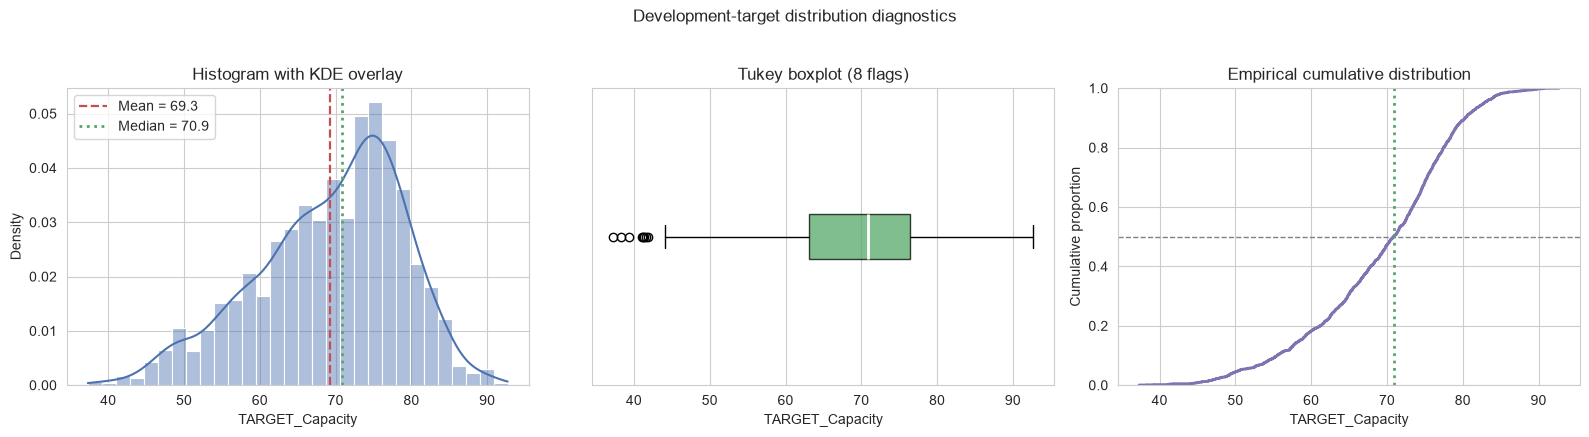

In [325]:
# Histogram + KDE, Tukey boxplot and ECDF provide complementary views.

total_tail_flags = int(
    lower_tail_flags.sum() + upper_tail_flags.sum()
)

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    # Histogram preserves the observed distribution structure.
    # The KDE is a smoothed descriptive overlay, not a replacement.
    sns.histplot(
        x=target_values,
        bins=30,
        stat="density",
        kde=True,
        kde_kws={"cut": 0},
        color="#4C72B0",
        alpha=0.45,
        edgecolor="white",
        ax=axes[0],
    )

    axes[0].axvline(
        target_values.mean(),
        color="#C44E52",
        linestyle="--",
        linewidth=1.6,
        label=f"Mean = {target_values.mean():.1f}",
    )
    axes[0].axvline(
        median,
        color="#55A868",
        linestyle=":",
        linewidth=2.0,
        label=f"Median = {median:.1f}",
    )
    axes[0].set(
        title="Histogram with KDE overlay",
        xlabel=TARGET_COL,
        ylabel="Density",
    )
    axes[0].legend(frameon=True)

    # Boxplot highlights observations beyond the conventional 1.5-IQR whiskers.
    axes[1].boxplot(
        target_values,
        orientation="horizontal",
        patch_artist=True,
        boxprops={"facecolor": "#55A868", "alpha": 0.75},
        medianprops={"color": "white", "linewidth": 2},
    )
    axes[1].set_yticks([])
    axes[1].set(
        title=f"Tukey boxplot ({total_tail_flags} flags)",
        xlabel=TARGET_COL,
        ylabel="",
    )

    # ECDF shows every observation without binning or density smoothing.
    sns.ecdfplot(
        x=target_values,
        color="#8172B2",
        linewidth=2,
        ax=axes[2],
    )
    axes[2].axhline(
        0.50,
        color="grey",
        linestyle="--",
        linewidth=1,
    )
    axes[2].axvline(
        median,
        color="#55A868",
        linestyle=":",
        linewidth=2,
    )
    axes[2].set(
        title="Empirical cumulative distribution",
        xlabel=TARGET_COL,
        ylabel="Cumulative proportion",
        ylim=(0, 1),
    )

    fig.suptitle(
        "Development-target distribution diagnostics",
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

### 3.3.3 Interpretation and modelling implications

The development target contains 1,653 observations and ranges from 37.3 to
92.7. Its mean is 69.3, while its median is slightly higher at 70.9. Together
with a skewness coefficient of approximately -0.54, this indicates moderate
negative skew: most observations are concentrated toward the upper-middle
part of the observed range, with a longer lower tail.

The histogram and KDE suggest a predominantly unimodal distribution rather
than clearly separated target subpopulations. The ECDF confirms that the
central 90% of observations lies approximately between 50.6 and 82.8.

Using the conventional 1.5-IQR rule gives fences of 43.15 and 96.35. Eight
observations, representing approximately 0.48% of the development data, fall
below the lower fence, while no observation exceeds the upper fence. These
values explain the visible lower tail and the difference between the mean and
median.

The flagged observations are not removed at this stage. An IQR flag indicates
an unusual value relative to the marginal distribution, but does not establish
that the record is erroneous. Their validity and modelling influence will be
assessed later through predictor relationships, grouped cross-validation and
model residual diagnostics.

No target transformation is selected solely from this plot. If a target
transformation is considered later, it must be evaluated as part of the
model-development workflow using grouped cross-validation, while the locked
holdout remains untouched.

## 3.4 Complete univariate predictor audit

This section performs a complete univariate audit of every candidate predictor
using the development partition only. `RecordID` and `TARGET_Capacity` are
excluded because they are the identifier and target, respectively.

Each predictor is assigned an explicit analysis route according to its role and
measurement type:

- continuous numeric predictors are examined using descriptive statistics,
  histogram–KDE overlays, skewness and Tukey tail flags;
- `CaseCount` is treated as a count-like variable and displayed without KDE;
- `Year` and `Status` are treated as discrete variables and displayed using
  frequency plots;
- `Country` is retained in the predictor inventory but its 108-group frequency
  structure is examined in Section 3.5.

For strongly right-skewed, non-negative predictors, `log1p` distributions are
shown as diagnostic views. These views do not modify `development_df` and do
not constitute a final preprocessing decision.

Missing values are documented but not imputed in this section. Tukey-flagged
observations are treated as distributional evidence rather than automatic data
errors. Any imputation, transformation or outlier treatment must be implemented
and evaluated later within the leakage-safe modelling workflow.

### 3.4.1 Predictor coverage and analysis routing

In [326]:
predictor_columns = [
    col
    for col in development_df.columns
    if col not in {ID_COL, TARGET_COL}
]

group_eda_features = [GROUP_COL]

discrete_eda_features = [
    col
    for col in ["Year", "Status"]
    if col in predictor_columns
]

count_like_eda_features = [
    col
    for col in [CASE_COUNT_COL]
    if col in predictor_columns
]

numeric_predictor_columns = (
    development_df[predictor_columns]
    .select_dtypes(include=np.number)
    .columns.tolist()
)

special_numeric_features = set(
    group_eda_features
    + discrete_eda_features
    + count_like_eda_features
)

continuous_eda_features = [
    col
    for col in numeric_predictor_columns
    if col not in special_numeric_features
]

categorical_eda_features = [
    col
    for col in predictor_columns
    if col not in numeric_predictor_columns
    and col not in group_eda_features
]

routed_features = (
    group_eda_features
    + discrete_eda_features
    + count_like_eda_features
    + continuous_eda_features
    + categorical_eda_features
)

# These assertions prevent silent predictor omission or duplicate routing.
assert len(routed_features) == len(set(routed_features))
assert set(routed_features) == set(predictor_columns)

analysis_route = {}

for feature in group_eda_features:
    analysis_route[feature] = "Group-frequency analysis in Section 3.5"

for feature in discrete_eda_features:
    analysis_route[feature] = "Discrete count plot"

for feature in count_like_eda_features:
    analysis_route[feature] = "Count-like histogram"

for feature in continuous_eda_features:
    analysis_route[feature] = "Histogram + KDE and tail diagnostics"

for feature in categorical_eda_features:
    analysis_route[feature] = "Categorical frequency plot"

predictor_inventory = pd.DataFrame(
    {
        "dtype": development_df[predictor_columns].dtypes.astype(str),
        "non_missing_n": development_df[predictor_columns].notna().sum(),
        "missing_n": development_df[predictor_columns].isna().sum(),
        "missing_pct": (
            100 * development_df[predictor_columns].isna().mean()
        ),
        "unique_n": development_df[predictor_columns].nunique(
            dropna=True
        ),
        "analysis_route": pd.Series(analysis_route),
    }
).loc[predictor_columns]

print(f"Candidate predictors routed: {len(routed_features)}")
display(predictor_inventory)

Candidate predictors routed: 24


,dtype,non_missing_n,missing_n,missing_pct,unique_n,analysis_route
CaseCount,float64,1651,2,0.1210,54,Count-like histogram
Country,int64,1653,0,0.0000,108,Group-frequency analysis in Section 3.5
Year,float64,1652,1,0.0605,16,Discrete count plot
Status,int64,1653,0,0.0000,3,Discrete count plot
SystemFailureRate,int64,1653,0,0.0000,360,Histogram + KDE and tail diagnostics
ModelFailureRate-T,int64,1653,0,0.0000,247,Histogram + KDE and tail diagnostics
ModelFailureRate-NT,float64,1652,1,0.0605,246,Histogram + KDE and tail diagnostics
InferenceLatency,int64,1653,0,0.0000,176,Histogram + KDE and tail diagnostics
ComputeUtilizationRate,float64,1653,0,0.0000,810,Histogram + KDE and tail diagnostics
AIInfraExpPercent,float64,1653,0,0.0000,1321,Histogram + KDE and tail diagnostics


### 3.4.2 Complete numeric profile, missingness and tail flags

Tukey tail diagnostics are calculated for continuous and count-like predictors.
They are not applied to `Year`, `Status` or `Country`, because IQR-based
outlier rules are not meaningful for temporal labels, binary-coded states or
group identifiers.

In [327]:
numeric_diagnostic_features = (
    count_like_eda_features + continuous_eda_features
)

numeric_values = development_df[numeric_diagnostic_features]

q1 = numeric_values.quantile(0.25)
q3 = numeric_values.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

lower_flags = numeric_values.lt(lower_fence)
upper_flags = numeric_values.gt(upper_fence)
all_tukey_flags = lower_flags | upper_flags

non_missing_n = numeric_values.notna().sum()

numeric_predictor_profile = pd.DataFrame(
    {
        "non_missing_n": non_missing_n,
        "missing_n": numeric_values.isna().sum(),
        "missing_pct": 100 * numeric_values.isna().mean(),
        "unique_n": numeric_values.nunique(dropna=True),
        "min": numeric_values.min(),
        "p01": numeric_values.quantile(0.01),
        "median": numeric_values.median(),
        "p99": numeric_values.quantile(0.99),
        "max": numeric_values.max(),
        "skewness": numeric_values.skew(),
        "zero_pct": (
            100 * numeric_values.eq(0).sum() / non_missing_n
        ),
        "IQR": iqr,
        "Tukey_flags_n": all_tukey_flags.sum(),
        "Tukey_flags_pct": (
            100 * all_tukey_flags.sum() / non_missing_n
        ),
    }
).loc[numeric_diagnostic_features]

display(numeric_predictor_profile)

predictor_missingness = predictor_inventory.loc[
    predictor_inventory["missing_n"].gt(0),
    ["missing_n", "missing_pct"],
]

print(
    "Total missing predictor cells in development:",
    int(predictor_inventory["missing_n"].sum()),
)
display(predictor_missingness)

,non_missing_n,missing_n,missing_pct,unique_n,min,p01,median,p99,max,skewness,zero_pct,IQR,Tukey_flags_n,Tukey_flags_pct
CaseCount,1651,2,0.1210,54,1.0000,10.0000,35.0000,51.5000,57.0000,-0.5406,0.0000,13.0000,8,0.4846
SystemFailureRate,1653,0,0.0000,360,1.0000,3.5200,146.0000,547.0400,699.0000,1.0663,0.0000,155.0000,35,2.1174
ModelFailureRate-T,1653,0,0.0000,247,0.0000,2.0000,144.0000,561.9200,704.0000,1.1054,0.5445,156.0000,33,1.9964
ModelFailureRate-NT,1652,1,0.0605,246,2.0000,4.0000,146.0000,530.9800,722.0000,1.0472,0.0000,156.0000,37,2.2397
InferenceLatency,1653,0,0.0000,176,0.0000,0.0000,3.0000,574.9600,"1,800.0000",7.9863,29.4011,20.0000,205,12.4017
ComputeUtilizationRate,1653,0,0.0000,810,0.0100,0.0100,3.9200,14.2148,17.8700,0.5535,0.0000,7.7500,0,0.0000
AIInfraExpPercent,1653,0,0.0000,1321,0.0000,0.0000,66.7293,"11,628.8035","19,479.9116",4.4633,20.1452,428.5730,263,15.9105
SecurityBreachIncidents,1653,0,0.0000,631,0.0000,0.0000,15.0000,"49,370.8400","212,183.0000",10.8211,34.4828,443.0000,311,18.8143
IntegrationEfficiency,1653,0,0.0000,519,1.4000,2.3000,42.7000,69.6480,87.3000,-0.1866,0.0000,37.1000,0,0.0000
UptimeReliabilityIndex,1653,0,0.0000,210,0.0000,0.0000,4.0000,939.3600,"2,500.0000",7.7072,27.1627,25.0000,233,14.0956


Total missing predictor cells in development: 8


,missing_n,missing_pct
CaseCount,2,0.1210
Year,1,0.0605
ModelFailureRate-NT,1,0.0605
AIDevExpPercent,1,0.0605
ActiveUserBase,1,0.0605
Complexity,2,0.1210


### 3.4.3 Discrete and count-like predictor distributions

KDE is not used for these predictors because it assumes a smooth continuous
distribution. `CaseCount` is an integer count-like feature, while `Year` and
`Status` represent discrete states.

The `Status` chart uses a logarithmic count axis so that the single anomalous
value of 15 remains visible beside the much more frequent values of 0 and 1.

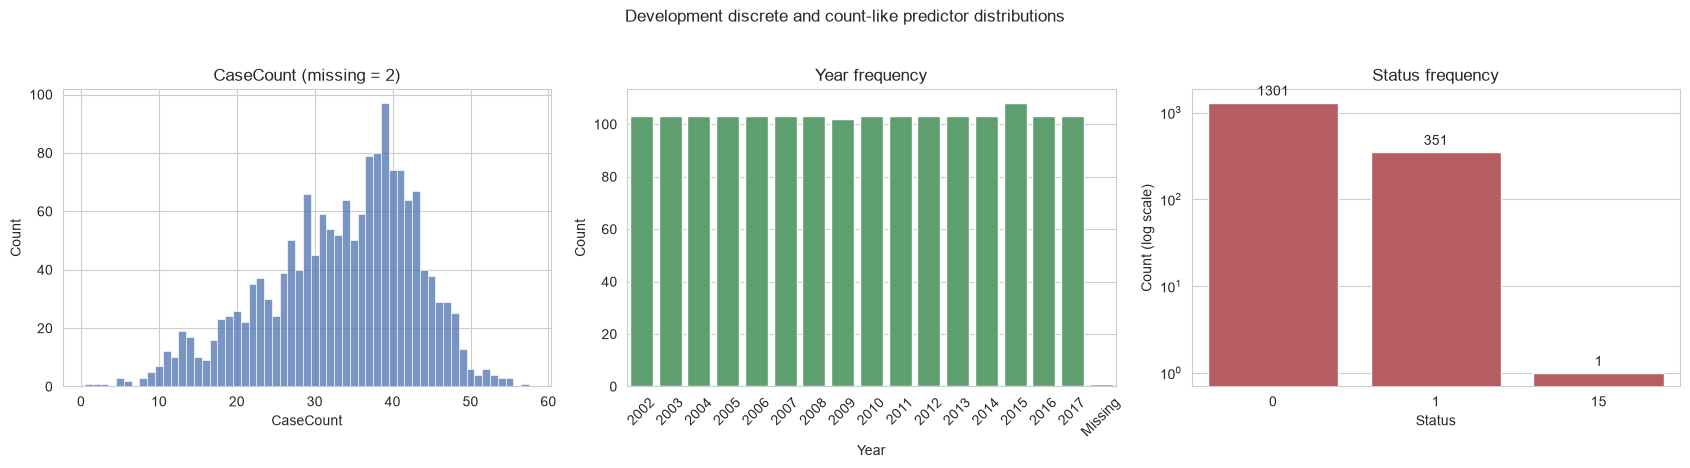

In [328]:
case_values = development_df[CASE_COUNT_COL].dropna()

year_values = development_df["Year"]
year_plot = (
    year_values.astype("Int64")
    .astype("string")
    .fillna("Missing")
)
year_order = [
    str(value)
    for value in sorted(
        year_values.dropna().astype(int).unique()
    )
]
if year_values.isna().any():
    year_order.append("Missing")

status_values = development_df["Status"]
status_plot = (
    status_values.astype("Int64")
    .astype("string")
    .fillna("Missing")
)
status_order = [
    str(value)
    for value in sorted(
        status_values.dropna().astype(int).unique()
    )
]
if status_values.isna().any():
    status_order.append("Missing")

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    sns.histplot(
        x=case_values,
        discrete=True,
        color="#4C72B0",
        edgecolor="white",
        ax=axes[0],
    )
    axes[0].set(
        title=(
            f"{CASE_COUNT_COL} "
            f"(missing = "
            f"{development_df[CASE_COUNT_COL].isna().sum()})"
        ),
        xlabel=CASE_COUNT_COL,
        ylabel="Count",
    )

    sns.countplot(
        x=year_plot,
        order=year_order,
        color="#55A868",
        ax=axes[1],
    )
    axes[1].set(
        title="Year frequency",
        xlabel="Year",
        ylabel="Count",
    )
    axes[1].tick_params(axis="x", rotation=45)

    sns.countplot(
        x=status_plot,
        order=status_order,
        color="#C44E52",
        ax=axes[2],
    )
    axes[2].set_yscale("log")
    axes[2].set(
        title="Status frequency",
        xlabel="Status",
        ylabel="Count (log scale)",
    )

    for container in axes[2].containers:
        axes[2].bar_label(container, padding=3)

    fig.suptitle(
        "Development discrete and count-like predictor distributions",
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

### 3.4.4 Raw continuous predictor distributions

All continuous predictors are plotted. The figures are divided into pages of
six panels for readability; the loop continues until every feature has been
displayed.

Each title reports raw skewness and the percentage of observations flagged by
the 1.5-IQR rule. The histogram remains the primary representation, while KDE
is used only as a smoothed overlay with its support limited to the observed
range.

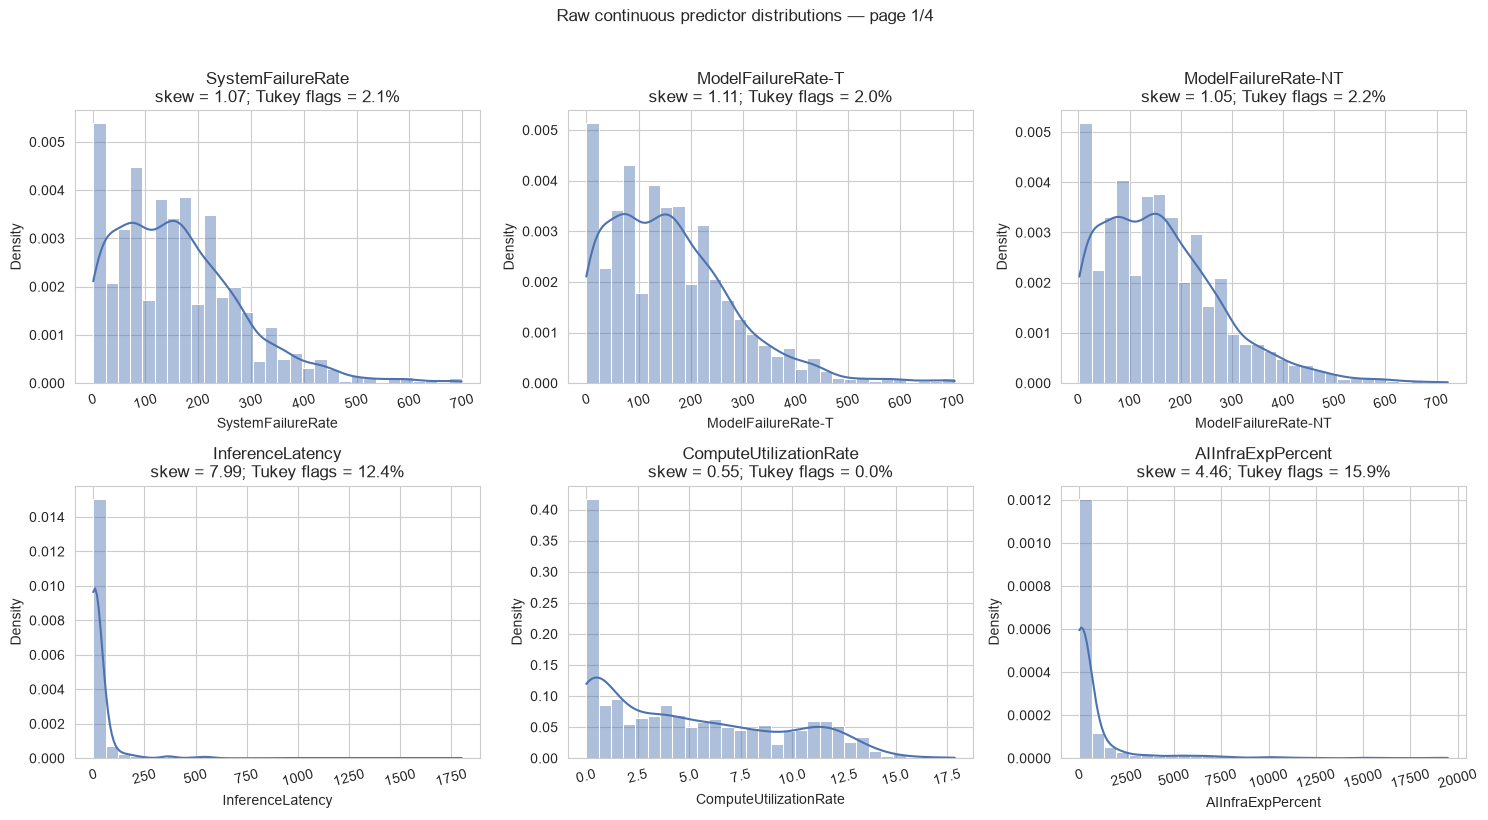

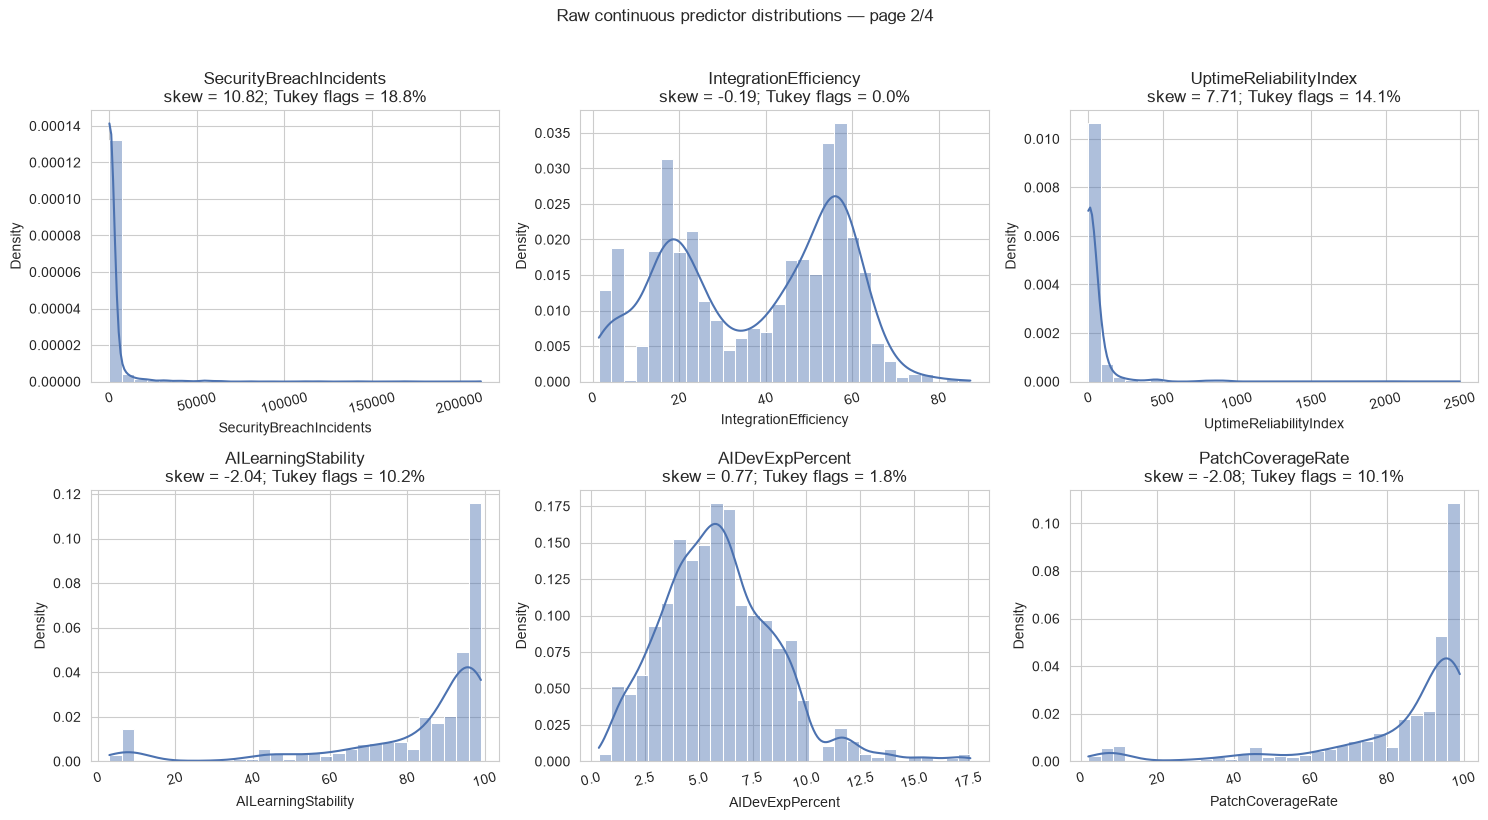

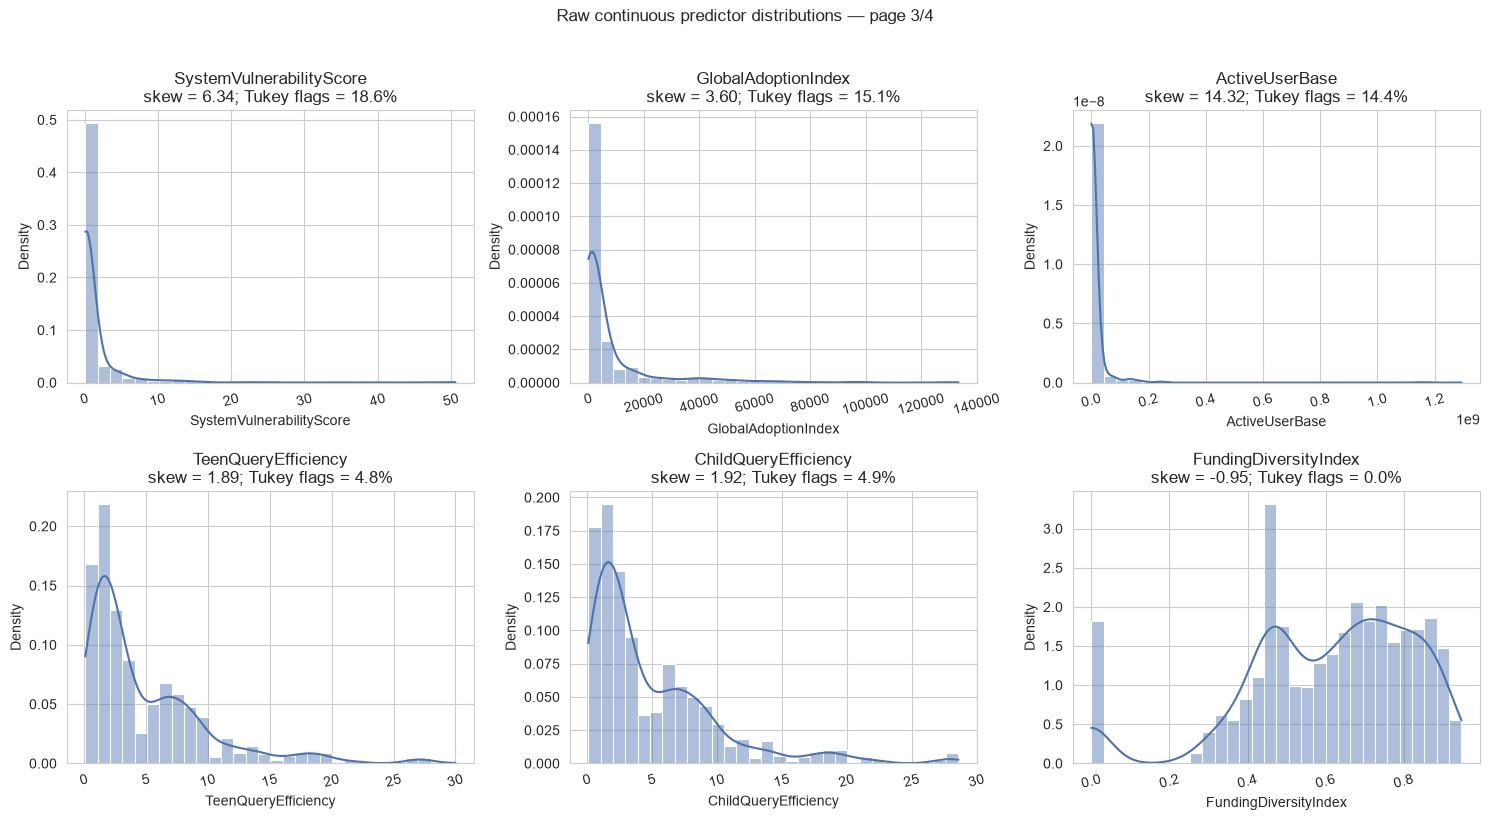

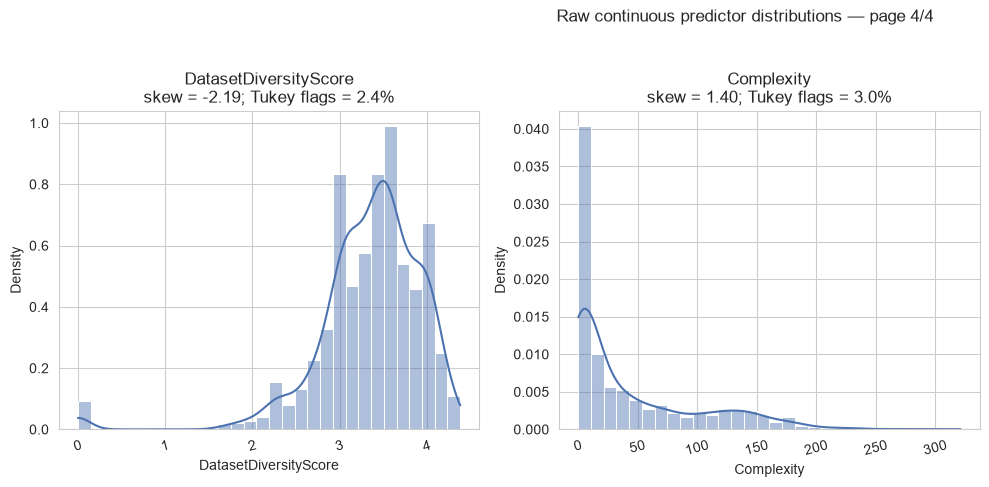

In [329]:
def plot_raw_distribution_pages(
    data,
    features,
    profile,
    page_size=6,
):
    page_total = int(np.ceil(len(features) / page_size))

    for page_number, start in enumerate(
        range(0, len(features), page_size),
        start=1,
    ):
        page_features = features[start : start + page_size]

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = np.asarray(axes).ravel()

        for axis, feature in zip(axes, page_features):
            values = data[feature].dropna()

            sns.histplot(
                x=values,
                bins=30,
                stat="density",
                kde=True,
                kde_kws={"cut": 0},
                color="#4C72B0",
                alpha=0.45,
                edgecolor="white",
                ax=axis,
            )

            row = profile.loc[feature]

            axis.set(
                title=(
                    f"{feature}\n"
                    f"skew = {row['skewness']:.2f}; "
                    f"Tukey flags = "
                    f"{row['Tukey_flags_pct']:.1f}%"
                ),
                xlabel=feature,
                ylabel="Density",
            )
            axis.tick_params(axis="x", rotation=15)

        for axis in axes[len(page_features) :]:
            axis.set_visible(False)

        fig.suptitle(
            "Raw continuous predictor distributions "
            f"— page {page_number}/{page_total}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


with sns.axes_style("whitegrid"):
    plot_raw_distribution_pages(
        development_df,
        continuous_eda_features,
        numeric_predictor_profile,
    )

### 3.4.5 Diagnostic log1p views for right-skewed predictors

A diagnostic `log1p` screen is applied to every continuous predictor satisfying
both of the following predeclared conditions:

1. raw skewness is greater than 1; and
2. all observed values are non-negative.

The comparison records whether `log1p` reduces absolute skewness. Transformed
plots are shown only when the distributional shape improves. This calculation
creates temporary plotting values and does not overwrite any column in
`development_df`.

A visually improved distribution is evidence for a later modelling experiment,
not proof that the transformation must be selected.

In [330]:
raw_continuous_skew = (
    development_df[continuous_eda_features].skew()
)
continuous_minimum = (
    development_df[continuous_eda_features].min()
)

right_skew_candidates = [
    feature
    for feature in continuous_eda_features
    if raw_continuous_skew[feature] > 1
    and continuous_minimum[feature] >= 0
]

log1p_skew = np.log1p(
    development_df[right_skew_candidates]
).skew()

log1p_comparison = pd.DataFrame(
    {
        "raw_skewness": raw_continuous_skew[
            right_skew_candidates
        ],
        "log1p_skewness": log1p_skew,
    }
)

log1p_comparison["absolute_skew_reduction"] = (
    log1p_comparison["raw_skewness"].abs()
    - log1p_comparison["log1p_skewness"].abs()
)

log1p_comparison["shape_improved"] = (
    log1p_comparison["absolute_skew_reduction"].gt(0)
)

display(log1p_comparison)

log1p_visual_features = log1p_comparison.index[
    log1p_comparison["shape_improved"]
].tolist()

print(
    "Right-skew candidates screened:",
    len(right_skew_candidates),
)
print(
    "Predictors with reduced absolute skew after log1p:",
    len(log1p_visual_features),
)

,raw_skewness,log1p_skewness,absolute_skew_reduction,shape_improved
SystemFailureRate,1.0663,-1.1502,-0.0839,False
ModelFailureRate-T,1.1054,-1.2936,-0.1882,False
ModelFailureRate-NT,1.0472,-1.0759,-0.0287,False
InferenceLatency,7.9863,0.7803,7.2060,True
AIInfraExpPercent,4.4633,-0.0435,4.4198,True
SecurityBreachIncidents,10.8211,0.5241,10.2970,True
UptimeReliabilityIndex,7.7072,0.7092,6.9979,True
SystemVulnerabilityScore,6.3366,2.2062,4.1304,True
GlobalAdoptionIndex,3.5989,0.0905,3.5084,True
ActiveUserBase,14.3221,-0.1716,14.1505,True


Right-skew candidates screened: 13
Predictors with reduced absolute skew after log1p: 10


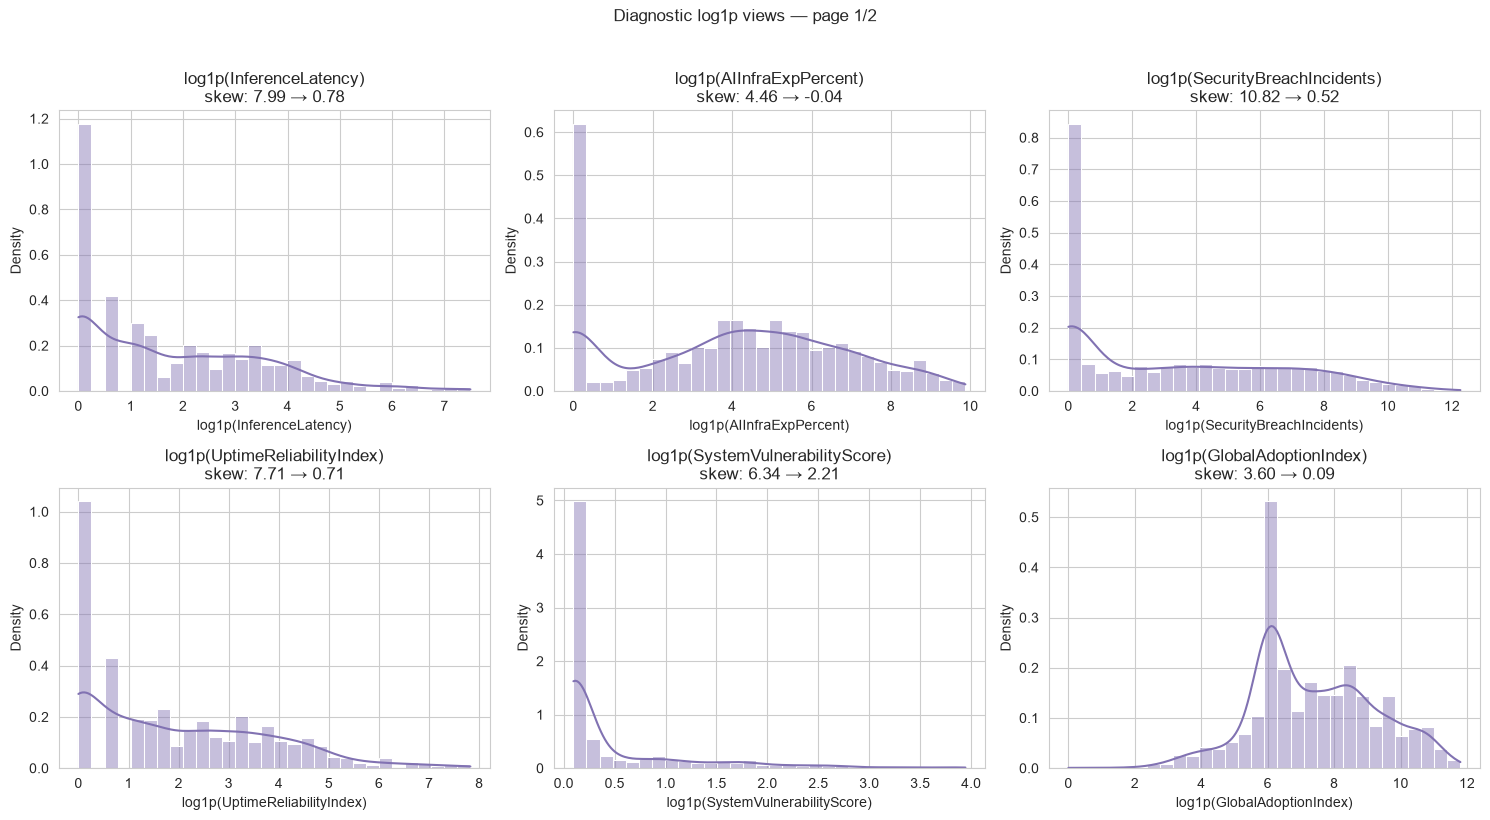

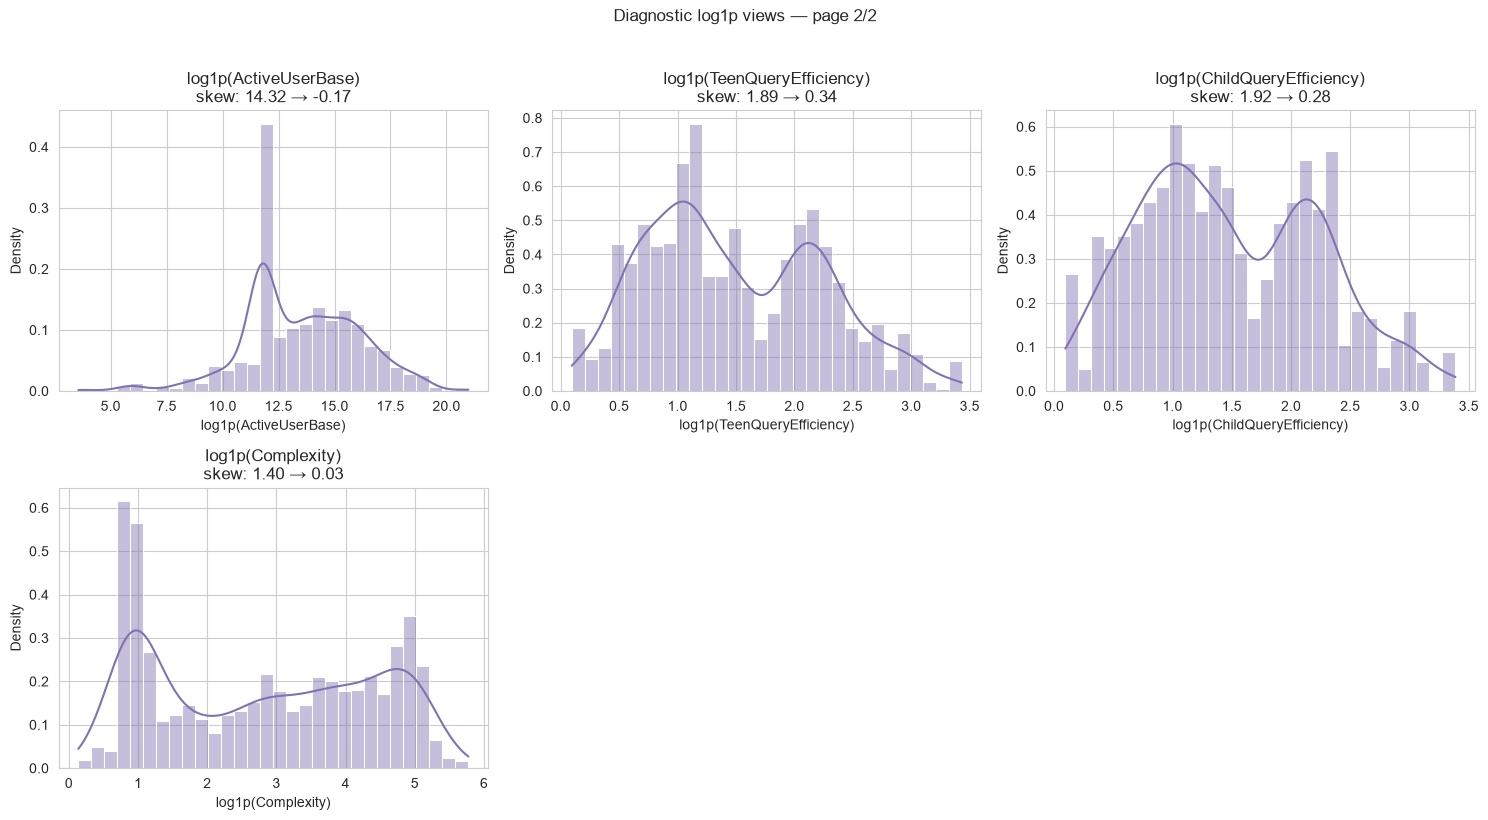

In [331]:
def plot_log1p_distribution_pages(
    data,
    features,
    comparison,
    page_size=6,
):
    page_total = int(np.ceil(len(features) / page_size))

    for page_number, start in enumerate(
        range(0, len(features), page_size),
        start=1,
    ):
        page_features = features[start : start + page_size]

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = np.asarray(axes).ravel()

        for axis, feature in zip(axes, page_features):
            transformed = np.log1p(
                data[feature].dropna()
            )
            row = comparison.loc[feature]

            sns.histplot(
                x=transformed,
                bins=30,
                stat="density",
                kde=True,
                kde_kws={"cut": 0},
                color="#8172B2",
                alpha=0.45,
                edgecolor="white",
                ax=axis,
            )

            axis.set(
                title=(
                    f"log1p({feature})\n"
                    f"skew: {row['raw_skewness']:.2f} "
                    f"→ {row['log1p_skewness']:.2f}"
                ),
                xlabel=f"log1p({feature})",
                ylabel="Density",
            )

        for axis in axes[len(page_features) :]:
            axis.set_visible(False)

        fig.suptitle(
            "Diagnostic log1p views "
            f"— page {page_number}/{page_total}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


with sns.axes_style("whitegrid"):
    plot_log1p_distribution_pages(
        development_df,
        log1p_visual_features,
        log1p_comparison,
    )

### 3.4.6 Interpretation and preprocessing handoff

All 24 candidate predictors are explicitly covered. Twenty continuous
predictors are displayed across four raw-distribution figures, while
`CaseCount`, `Year` and `Status` receive measurement-appropriate frequency
plots. `Country` is retained in the inventory and routed to the group-level
analysis in Section 3.5 rather than being treated as a continuous number.

The development partition contains eight missing predictor cells across six
features: `CaseCount`, `Year`, `ModelFailureRate-NT`, `AIDevExpPercent`,
`ActiveUserBase` and `Complexity`. No value is imputed during EDA. Missing
numeric values will later be handled by a fold-fitted preprocessing pipeline.

Several predictors exhibit substantial positive skew and long upper tails,
particularly `ActiveUserBase`, `SecurityBreachIncidents`,
`InferenceLatency`, `UptimeReliabilityIndex`,
`SystemVulnerabilityScore`, `AIInfraExpPercent` and
`GlobalAdoptionIndex`. In contrast, `AILearningStability`,
`PatchCoverageRate` and `DatasetDiversityScore` exhibit pronounced lower-tail
or ceiling-concentrated distributions.

High Tukey-flag percentages occur for several heavy-tailed predictors. These
rates indicate that the marginal distributions are not well represented by a
symmetric IQR rule; they do not demonstrate that a large fraction of the data
is erroneous. Therefore, no row is deleted and no predictor is capped in this
section.

Diagnostic `log1p` views substantially reduce skewness for ten non-negative
right-skewed predictors. These transformed views provide candidate
preprocessing hypotheses. They do not modify the development data and do not
select a final transformation. Raw and candidate-transformed policies must be
compared later using the same Country-grouped cross-validation protocol.

The `Status=15` observation remains unresolved. It is documented as a
metadata inconsistency rather than silently corrected. The predeclared
`retain_numeric` and `invalid_to_nan` policies will be compared during the
development-policy ablation stage.

## 3.5 Development Country and Year structure

This section examines temporal coverage, Country-group structure and
development-target patterns using `development_df` only.

`Year` is treated as a discrete temporal variable, while `Country` is treated
as a group identifier rather than a continuous numeric quantity. The analysis
therefore focuses on:

- row and Country coverage across Years;
- target location and spread across Years;
- the number of observations and observed Years within each Country;
- Country–Year panel completeness;
- between-Country and within-Country target variation.

Country-level target differences are exploratory evidence. They do not by
themselves justify encoding `Country` as a model feature, because grouped
cross-validation evaluates Countries that are absent from the corresponding
training folds.

### 3.5.1 Year coverage and target pattern

In [332]:
development_year_profile = (
    development_df.groupby("Year", dropna=False)
    .agg(
        rows=(ID_COL, "size"),
        countries=(GROUP_COL, "nunique"),
        target_mean=(TARGET_COL, "mean"),
        target_median=(TARGET_COL, "median"),
        target_q25=(
            TARGET_COL,
            lambda values: values.quantile(0.25),
        ),
        target_q75=(
            TARGET_COL,
            lambda values: values.quantile(0.75),
        ),
    )
    .sort_index()
)

display(development_year_profile)

valid_year_profile = development_year_profile.loc[
    development_year_profile.index.notna()
].copy()

plot_years = (
    valid_year_profile.index.astype(int).to_numpy()
)

,rows,countries,target_mean,target_median,target_q25,target_q75
Year,,,,,,
"2,002.0000",103,103,66.3699,69.0000,59.0500,74.8000
"2,003.0000",103,103,66.8806,69.1000,60.1500,74.8500
"2,004.0000",103,103,67.0602,69.7000,60.6500,74.6000
"2,005.0000",103,103,67.5223,69.4000,61.3000,74.8000
"2,006.0000",103,103,67.8223,69.9000,61.7500,74.5000
"2,007.0000",103,103,68.3505,69.9000,63.0500,75.5000
"2,008.0000",103,103,68.8427,70.7000,62.3500,75.6500
"2,009.0000",102,102,69.1863,70.0500,62.8500,76.1000
"2,010.0000",103,103,69.4000,71.6000,63.3000,75.5000


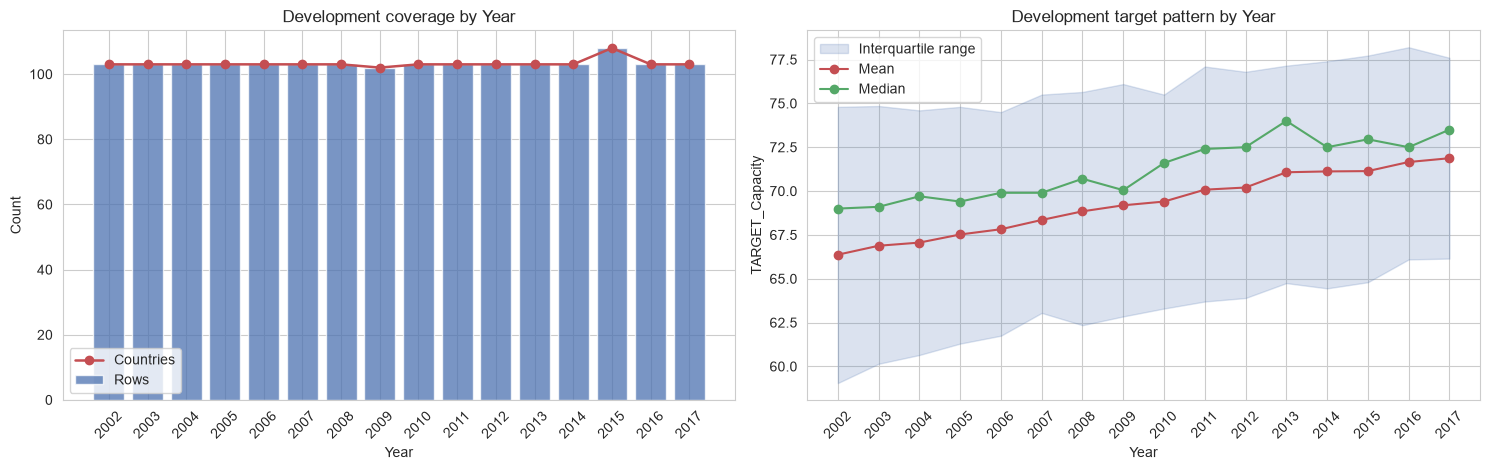

In [333]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    axes[0].bar(
        plot_years,
        valid_year_profile["rows"],
        color="#4C72B0",
        alpha=0.75,
        label="Rows",
    )
    axes[0].plot(
        plot_years,
        valid_year_profile["countries"],
        color="#C44E52",
        marker="o",
        linewidth=1.8,
        label="Countries",
    )
    axes[0].set(
        title="Development coverage by Year",
        xlabel="Year",
        ylabel="Count",
        xticks=plot_years,
    )
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend()

    axes[1].fill_between(
        plot_years,
        valid_year_profile["target_q25"].to_numpy(),
        valid_year_profile["target_q75"].to_numpy(),
        color="#4C72B0",
        alpha=0.20,
        label="Interquartile range",
    )
    axes[1].plot(
        plot_years,
        valid_year_profile["target_mean"],
        color="#C44E52",
        marker="o",
        label="Mean",
    )
    axes[1].plot(
        plot_years,
        valid_year_profile["target_median"],
        color="#55A868",
        marker="o",
        label="Median",
    )
    axes[1].set(
        title="Development target pattern by Year",
        xlabel="Year",
        ylabel=TARGET_COL,
        xticks=plot_years,
    )
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 3.5.2 Country panel coverage

The Country profile quantifies the number of records, observed Years and
within-Country target spread for every development Country. A Country–Year
presence matrix then shows the complete panel structure without treating
Country codes as numeric measurements.

In [334]:
country_target_quantiles = (
    development_df.groupby(GROUP_COL)[TARGET_COL]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(
        columns={
            0.25: "target_q25",
            0.75: "target_q75",
        }
    )
)

development_country_profile = (
    development_df.groupby(GROUP_COL)
    .agg(
        rows=(ID_COL, "size"),
        observed_years=("Year", "nunique"),
        first_year=("Year", "min"),
        last_year=("Year", "max"),
        target_mean=(TARGET_COL, "mean"),
        target_median=(TARGET_COL, "median"),
        target_std=(TARGET_COL, "std"),
        target_min=(TARGET_COL, "min"),
        target_max=(TARGET_COL, "max"),
    )
    .join(country_target_quantiles)
    .sort_index()
)

development_country_profile["year_span"] = (
    development_country_profile["last_year"]
    - development_country_profile["first_year"]
    + 1
)

development_country_profile[
    "missing_years_within_span"
] = (
    development_country_profile["year_span"]
    - development_country_profile["observed_years"]
)

development_country_profile["target_iqr"] = (
    development_country_profile["target_q75"]
    - development_country_profile["target_q25"]
)

full_year_count = len(valid_year_profile)

country_panel_summary = pd.Series(
    {
        "Country groups": len(development_country_profile),
        f"Countries with {full_year_count} rows": int(
            development_country_profile["rows"]
            .eq(full_year_count)
            .sum()
        ),
        (
            f"Countries observed in all "
            f"{full_year_count} Years"
        ): int(
            development_country_profile["observed_years"]
            .eq(full_year_count)
            .sum()
        ),
        "Singleton Countries": int(
            development_country_profile["rows"].eq(1).sum()
        ),
        "Countries with missing Years within span": int(
            development_country_profile[
                "missing_years_within_span"
            ]
            .gt(0)
            .sum()
        ),
        "Rows with missing Year": int(
            development_df["Year"].isna().sum()
        ),
    },
    name="development",
)

display(country_panel_summary.to_frame())

country_profile_columns = {
    "Rows per Country": "rows",
    "Observed Years per Country": "observed_years",
    "Country target median": "target_median",
    "Within-Country target SD": "target_std",
    "Within-Country target IQR": "target_iqr",
}

country_profile_summary = pd.DataFrame(
    {
        "Countries available": {
            label: int(
                development_country_profile[column].count()
            )
            for label, column in country_profile_columns.items()
        },
        "Minimum": {
            label: development_country_profile[column].min()
            for label, column in country_profile_columns.items()
        },
        "Median": {
            label: development_country_profile[column].median()
            for label, column in country_profile_columns.items()
        },
        "Maximum": {
            label: development_country_profile[column].max()
            for label, column in country_profile_columns.items()
        },
    }
)

display(country_profile_summary)

,development
Country groups,108
Countries with 16 rows,103
Countries observed in all 16 Years,102
Singleton Countries,5
Countries with missing Years within span,1
Rows with missing Year,1


,Countries available,Minimum,Median,Maximum
Rows per Country,108,1.0000,16.0000,16.0000
Observed Years per Country,108,1.0000,16.0000,16.0000
Country target median,108,47.1000,70.0250,83.0500
Within-Country target SD,103,1.1051,2.9738,6.7294
Within-Country target IQR,108,0.0000,3.5875,11.6000


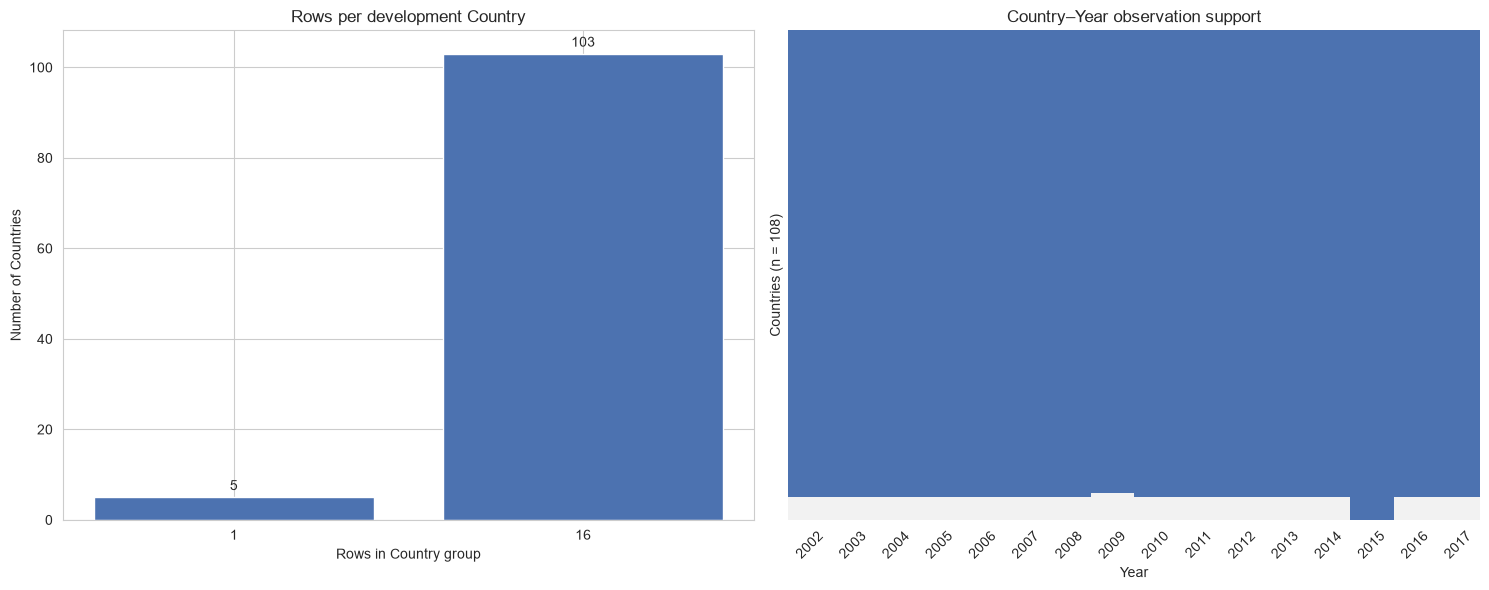

In [335]:
country_row_frequency = (
    development_country_profile["rows"]
    .value_counts()
    .sort_index()
)

valid_year_rows = development_df.dropna(
    subset=["Year"]
).copy()

valid_year_rows["Year"] = (
    valid_year_rows["Year"].astype(int)
)

presence_order = (
    development_country_profile
    .sort_values(
        ["observed_years", "first_year"],
        ascending=[False, True],
    )
    .index
)

country_year_presence = (
    pd.crosstab(
        valid_year_rows[GROUP_COL],
        valid_year_rows["Year"],
    )
    .reindex(
        index=presence_order,
        columns=plot_years,
        fill_value=0,
    )
    .gt(0)
    .astype(int)
)

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    bars = axes[0].bar(
        country_row_frequency.index.astype(str),
        country_row_frequency.values,
        color="#4C72B0",
    )
    axes[0].bar_label(bars, padding=3)
    axes[0].set(
        title="Rows per development Country",
        xlabel="Rows in Country group",
        ylabel="Number of Countries",
    )

    sns.heatmap(
        country_year_presence,
        cmap=sns.color_palette(
            ["#F2F2F2", "#4C72B0"],
            as_cmap=True,
        ),
        cbar=False,
        yticklabels=False,
        linewidths=0,
        ax=axes[1],
    )
    axes[1].set(
        title="Country–Year observation support",
        xlabel="Year",
        ylabel=(
            f"Countries "
            f"(n = {len(country_year_presence)})"
        ),
    )
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### 3.5.3 Between-Country target heterogeneity

Every development Country is ordered by its median target. The line displays
all Country medians, while the shaded region represents each Country's
within-group interquartile range. Singleton Countries are marked separately
because their within-group spread cannot be estimated from one observation.

,value
SD of Country target means,9.1003
Median within-Country target SD,2.9738
Minimum Country target median,47.1000
Maximum Country target median,83.0500


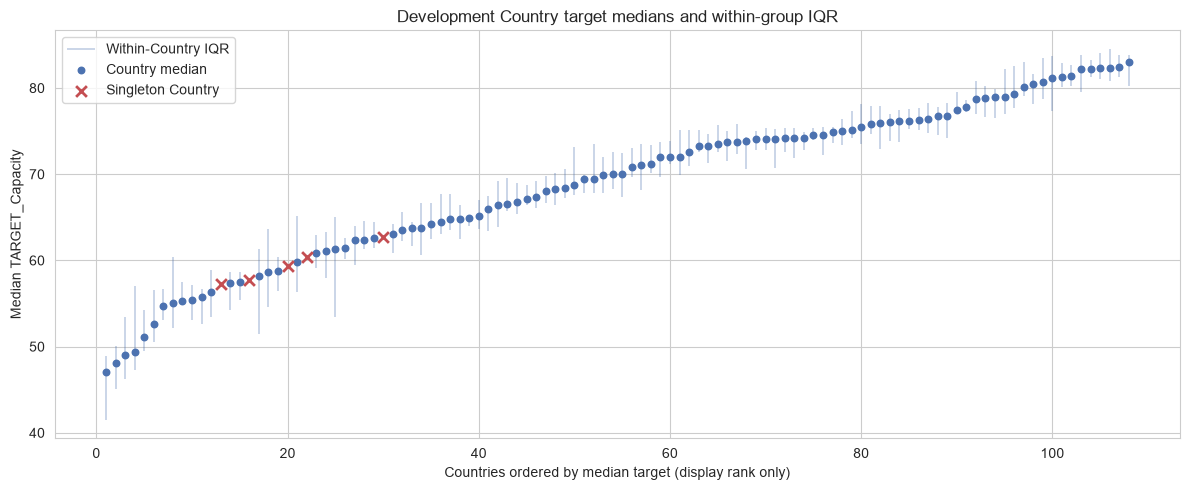

In [336]:
country_variation_summary = pd.Series(
    {
        "SD of Country target means": (
            development_country_profile[
                "target_mean"
            ].std()
        ),
        "Median within-Country target SD": (
            development_country_profile[
                "target_std"
            ].median()
        ),
        "Minimum Country target median": (
            development_country_profile[
                "target_median"
            ].min()
        ),
        "Maximum Country target median": (
            development_country_profile[
                "target_median"
            ].max()
        ),
    },
    name="value",
)

display(country_variation_summary.to_frame())

country_target_rank = (
    development_country_profile
    .sort_values("target_median")
    .reset_index()
)

country_target_rank["rank"] = np.arange(
    1,
    len(country_target_rank) + 1,
)

singleton_mask = country_target_rank["rows"].eq(1)
non_singleton_mask = ~singleton_mask

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.vlines(
        x=country_target_rank.loc[
            non_singleton_mask, "rank"
        ],
        ymin=country_target_rank.loc[
            non_singleton_mask, "target_q25"
        ],
        ymax=country_target_rank.loc[
            non_singleton_mask, "target_q75"
        ],
        color="#4C72B0",
        alpha=0.35,
        linewidth=1.2,
        label="Within-Country IQR",
    )

    ax.scatter(
        country_target_rank.loc[
            non_singleton_mask, "rank"
        ],
        country_target_rank.loc[
            non_singleton_mask, "target_median"
        ],
        color="#4C72B0",
        s=22,
        label="Country median",
    )

    ax.scatter(
        country_target_rank.loc[
            singleton_mask, "rank"
        ],
        country_target_rank.loc[
            singleton_mask, "target_median"
        ],
        color="#C44E52",
        marker="x",
        s=60,
        linewidth=2,
        label="Singleton Country",
    )

    ax.set(
        title="Development Country target medians and within-group IQR",
        xlabel="Countries ordered by median target (display rank only)",
        ylabel=f"Median {TARGET_COL}",
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

### 3.5.4 Interpretation and modelling implications

The development partition contains 108 Country groups. Most of the panel is
highly regular: 103 Countries contain 16 records, while five Countries are
singletons observed only in 2015. One additional record has a missing `Year`,
causing one Country to have 16 rows but only 15 observed Year values.

Annual coverage is therefore broadly stable, with approximately 103 Countries
per Year. The larger 2015 count is explained by the five singleton Countries,
while the lower 2009 count is associated with the missing-Year record.

Development target location generally increases over time. Mean target rises
from approximately 66.4 in 2002 to 71.9 in 2017, while the median rises from
69.0 to 73.5. The movement is not strictly monotonic, and annual aggregate
patterns may partly reflect changes in Country composition. The Year trend is
therefore a predictive hypothesis rather than a causal conclusion.

Country target medians range from approximately 47.1 to 83.1. The standard
deviation of Country target means is approximately 9.1, compared with a median
within-Country target standard deviation of approximately 3.0. This indicates
substantial between-Country heterogeneity and supports the use of
Country-grouped validation rather than row-wise random folds.

The observed heterogeneity does not automatically justify one-hot encoding
`Country`. Under grouped cross-validation, each validation Country is absent
from its corresponding training fold, so direct Country-category effects may
not generalise to unseen groups. `COUNTRY_FEATURE_POLICY` therefore remains
unresolved. The predeclared `group_only` and `one_hot` policies will be compared
later using the same grouped folds.

No Country or Year record is removed, and the missing Year is not imputed
during EDA. Any imputation is deferred to the fold-fitted preprocessing
pipeline.

## 3.6 Complete feature–target relationship screen

This section examines the marginal relationship between every non-group
predictor and `TARGET_Capacity` using the development partition only.

Pearson correlation measures linear association, while Spearman correlation
measures monotonic rank association and is less sensitive to strongly skewed
scales. The difference between the two coefficients is used as evidence of
possible nonlinearity or scale effects.

`Country` is excluded from numeric correlation because its integer values are
group labels rather than quantitative measurements. Its target structure was
examined separately in Section 3.5.

Correlation is exploratory evidence only. It does not establish causality,
feature validity or deployment usefulness, and no feature is automatically
selected or removed from this screen.

### 3.6.1 Pearson and Spearman association table

Pairwise-complete observations are used for each predictor. The number of
available pairs and missing values is recorded so that correlations calculated
from slightly different sample sizes remain transparent.

In [337]:
relationship_features = [
    col
    for col in development_df.columns
    if col not in {
        ID_COL,
        TARGET_COL,
        GROUP_COL,
    }
]

# Confirm that every non-group candidate predictor is included.
assert (
    set(relationship_features)
    == set(predictor_columns) - {GROUP_COL}
)

assert all(
    pd.api.types.is_numeric_dtype(
        development_df[feature]
    )
    for feature in relationship_features
)

association_rows = []

for feature in relationship_features:
    complete_pairs = development_df[
        [feature, TARGET_COL]
    ].dropna()

    pearson = complete_pairs[feature].corr(
        complete_pairs[TARGET_COL],
        method="pearson",
    )
    spearman = complete_pairs[feature].corr(
        complete_pairs[TARGET_COL],
        method="spearman",
    )

    association_rows.append(
        {
            "feature": feature,
            "n_pairs": len(complete_pairs),
            "missing_n": int(
                development_df[feature].isna().sum()
            ),
            "pearson": pearson,
            "spearman": spearman,
            "max_abs_association": max(
                abs(pearson),
                abs(spearman),
            ),
            "absolute_method_gap": abs(
                abs(pearson) - abs(spearman)
            ),
        }
    )

target_association = (
    pd.DataFrame(association_rows)
    .set_index("feature")
    .sort_values(
        "max_abs_association",
        ascending=False,
    )
)

print(
    "Non-group predictors screened:",
    len(target_association),
)
display(target_association)

Non-group predictors screened: 23


,n_pairs,missing_n,pearson,spearman,max_abs_association,absolute_method_gap
feature,,,,,,
CaseCount,1651,2,0.9995,0.9994,0.9995,0.0001
FundingDiversityIndex,1653,0,0.6782,0.7829,0.7829,0.1047
DatasetDiversityScore,1653,0,0.6361,0.7628,0.7628,0.1267
SystemVulnerabilityScore,1653,0,-0.5049,-0.6884,0.6884,0.1835
SystemFailureRate,1653,0,-0.6473,-0.6065,0.6473,0.0409
ModelFailureRate-T,1653,0,-0.6470,-0.6058,0.6470,0.0412
ModelFailureRate-NT,1652,1,-0.6454,-0.6049,0.6454,0.0405
Status,1653,0,0.4253,0.6047,0.6047,0.1794
UptimeReliabilityIndex,1653,0,-0.2083,-0.5887,0.5887,0.3805


### 3.6.2 Complete association comparison

The following chart displays both correlation measures for all 23 non-group
predictors. Predictors are ordered by their strongest absolute coefficient,
rather than by their original column order.

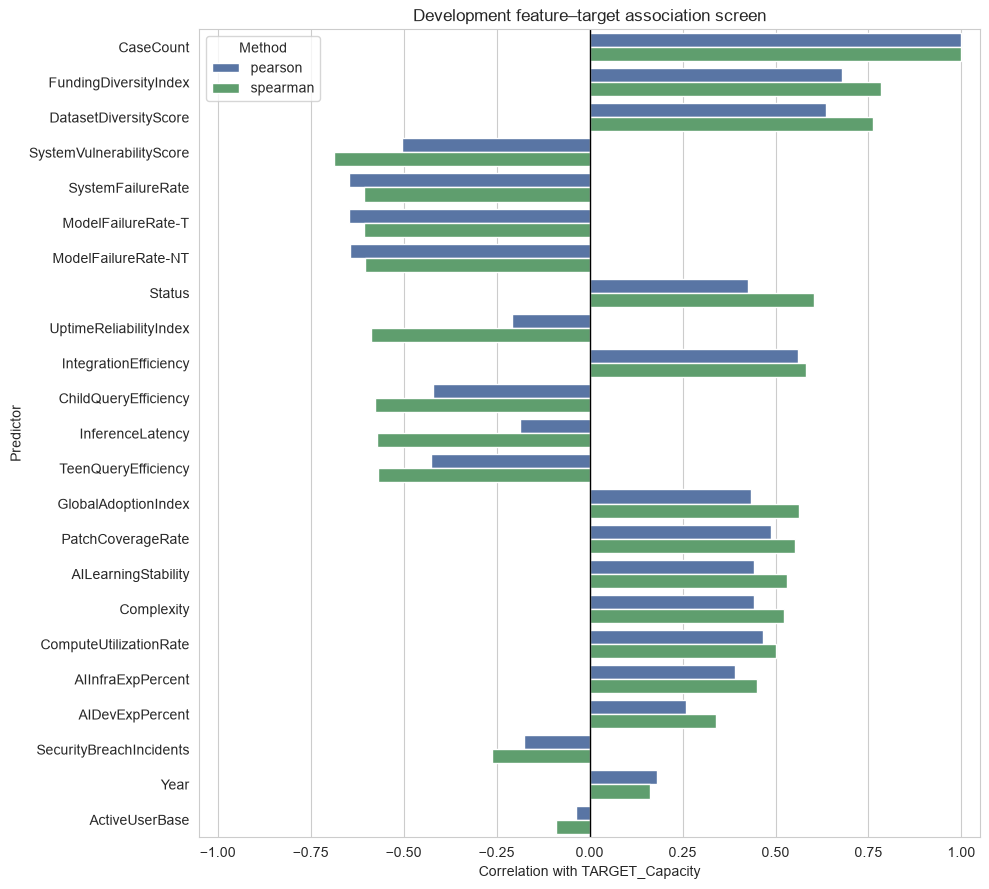

In [338]:
association_long = (
    target_association[
        ["pearson", "spearman"]
    ]
    .reset_index()
    .melt(
        id_vars="feature",
        var_name="method",
        value_name="correlation",
    )
)

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 9))

    sns.barplot(
        data=association_long,
        y="feature",
        x="correlation",
        hue="method",
        order=target_association.index,
        palette={
            "pearson": "#4C72B0",
            "spearman": "#55A868",
        },
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1,
    )
    ax.set(
        title=(
            "Development feature–target "
            "association screen"
        ),
        xlabel=f"Correlation with {TARGET_COL}",
        ylabel="Predictor",
        xlim=(-1.05, 1.05),
    )
    ax.legend(title="Method")

    plt.tight_layout()
    plt.show()

### 3.6.3 Raw numeric feature–target relationships

Every continuous or count-like predictor is plotted against the target. The
figures are divided into pages of six panels for readability; the loop
continues until all 21 applicable predictors have been displayed.

The red line is a descriptive linear trend fitted to the development
observations. It is included to reveal departures from a simple linear pattern
and does not represent a selected model.

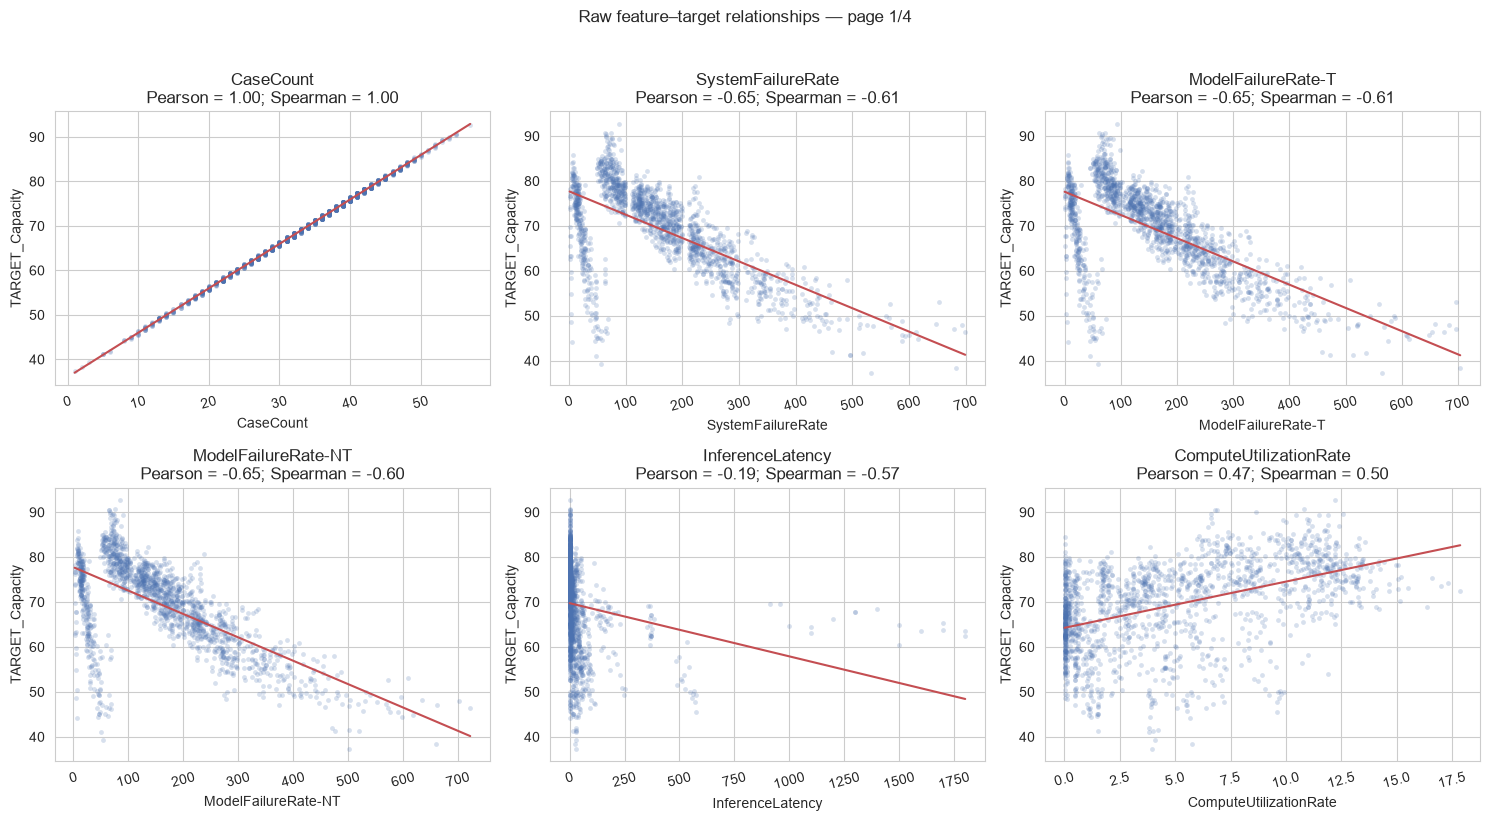

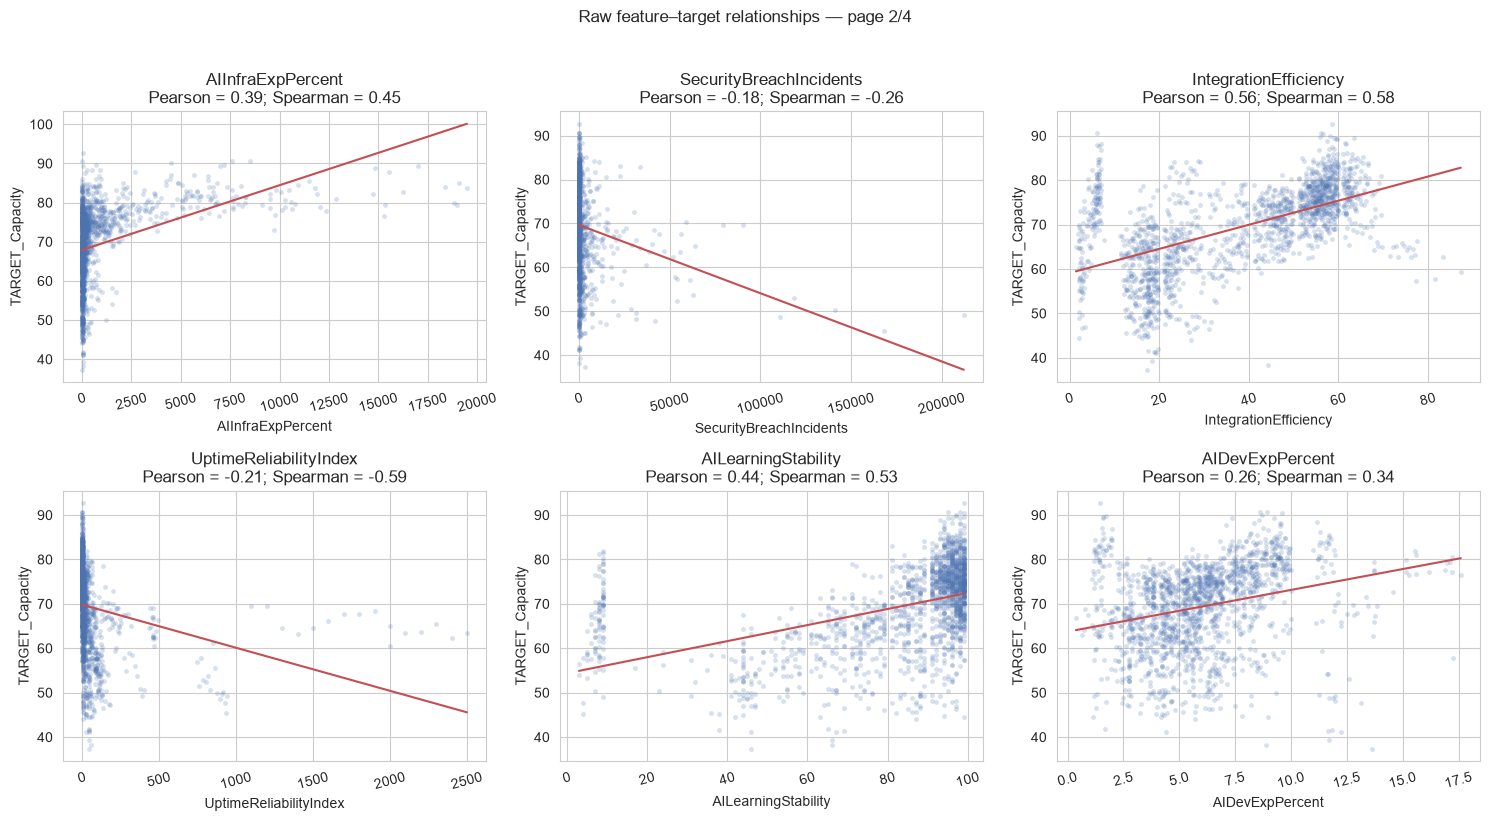

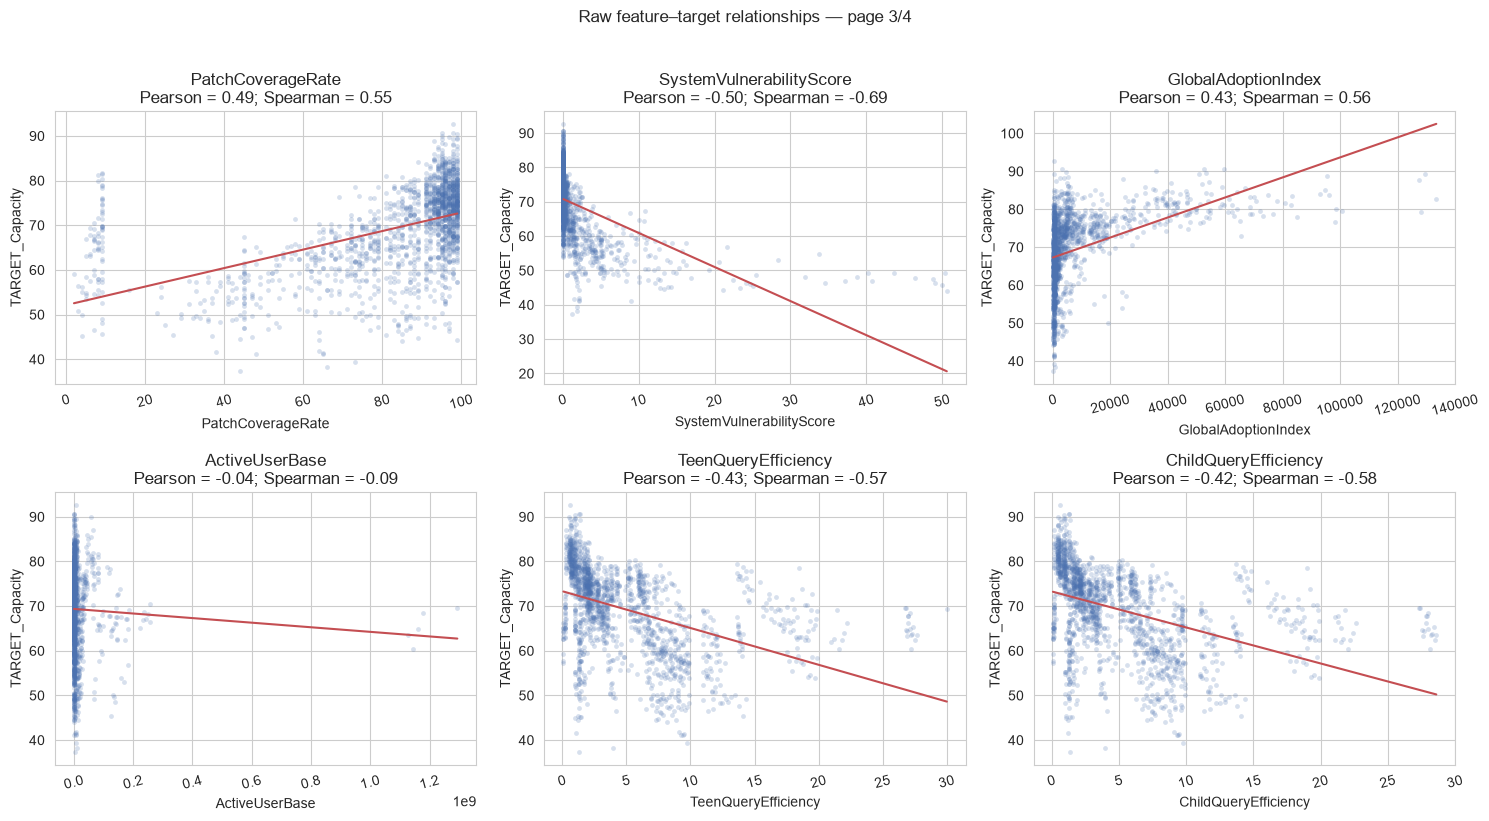

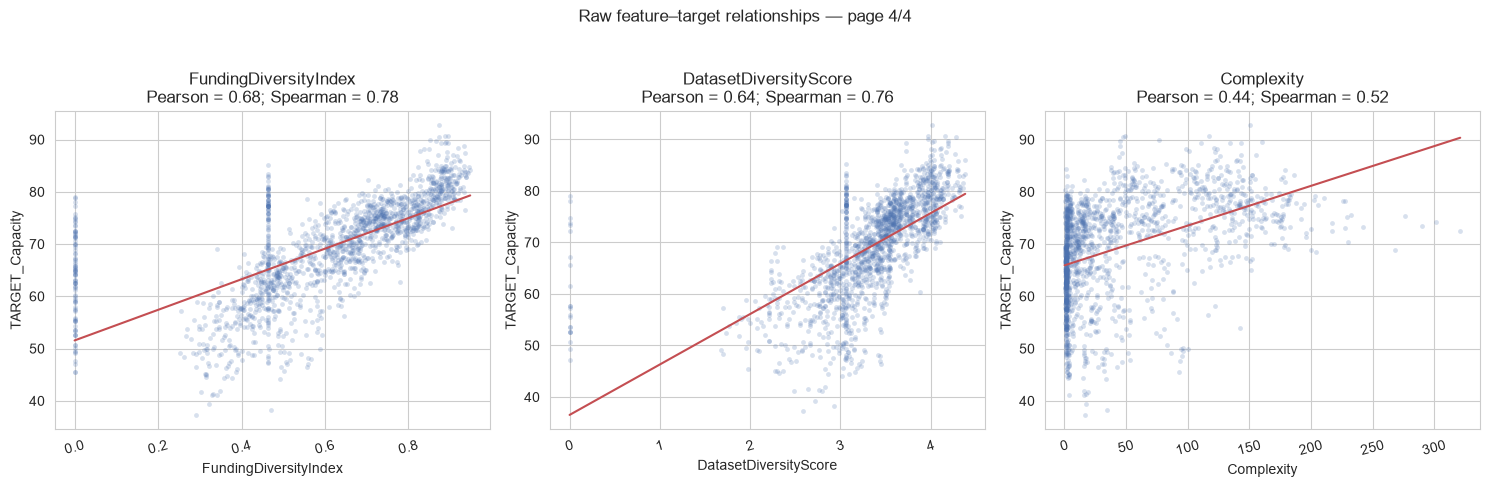

In [339]:
continuous_relationship_features = (
    count_like_eda_features
    + continuous_eda_features
)

assert (
    set(continuous_relationship_features)
    == set(relationship_features) - {"Year", "Status"}
)


def plot_feature_target_pages(
    data,
    features,
    association,
    page_size=6,
):
    page_total = int(np.ceil(len(features) / page_size))

    for page_number, start in enumerate(
        range(0, len(features), page_size),
        start=1,
    ):
        page_features = features[
            start : start + page_size
        ]

        fig, axes = plt.subplots(
            2,
            3,
            figsize=(15, 8),
        )
        axes = np.asarray(axes).ravel()

        for axis, feature in zip(
            axes,
            page_features,
        ):
            complete_pairs = data[
                [feature, TARGET_COL]
            ].dropna()

            axis.scatter(
                complete_pairs[feature],
                complete_pairs[TARGET_COL],
                alpha=0.22,
                s=12,
                color="#4C72B0",
                linewidths=0,
                rasterized=True,
            )

            sns.regplot(
                data=complete_pairs,
                x=feature,
                y=TARGET_COL,
                scatter=False,
                ci=None,
                color="#C44E52",
                line_kws={"linewidth": 1.5},
                ax=axis,
            )

            row = association.loc[feature]

            axis.set(
                title=(
                    f"{feature}\n"
                    f"Pearson = {row['pearson']:.2f}; "
                    f"Spearman = "
                    f"{row['spearman']:.2f}"
                ),
                xlabel=feature,
                ylabel=TARGET_COL,
            )
            axis.tick_params(
                axis="x",
                rotation=15,
            )

        for axis in axes[len(page_features) :]:
            axis.set_visible(False)

        fig.suptitle(
            "Raw feature–target relationships "
            f"— page {page_number}/{page_total}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


with sns.axes_style("whitegrid"):
    plot_feature_target_pages(
        development_df,
        continuous_relationship_features,
        target_association,
    )

### 3.6.4 Discrete predictor–target relationships

`Year` and `Status` are displayed as grouped target distributions rather than
continuous scatterplots. The Year plot complements the aggregate temporal
trend in Section 3.5, while the Status plot shows the target separation between
the recorded Status levels.

The single `Status=15` group remains provisional because it contains only one
observation and conflicts with the metadata-defined 0/1 support.

,rows,target_mean,target_median,target_std,target_min,target_max
Status,,,,,,
0,1301,66.5468,67.6000,8.7615,37.3000,92.7000
1,351,79.4624,79.5000,4.3127,68.9000,90.7000
15,1,77.7000,77.7000,NaN,77.7000,77.7000


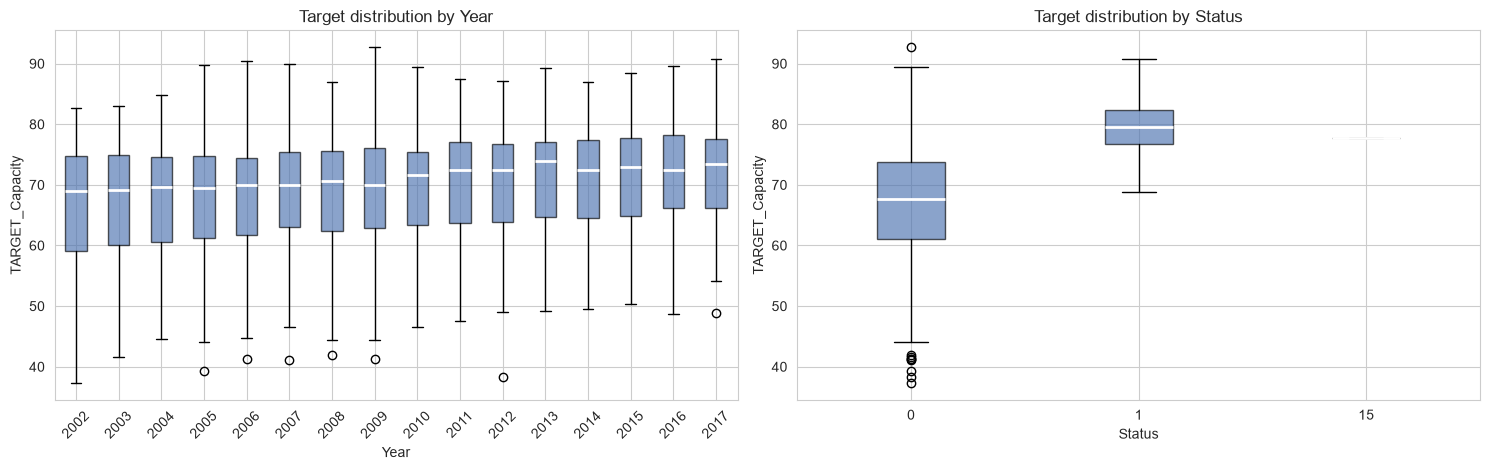

In [340]:
status_target_profile = (
    development_df.groupby(
        "Status",
        dropna=False,
    )[TARGET_COL]
    .agg(
        rows="size",
        target_mean="mean",
        target_median="median",
        target_std="std",
        target_min="min",
        target_max="max",
    )
)

display(status_target_profile)

year_pairs = development_df[
    ["Year", TARGET_COL]
].dropna()

year_levels = sorted(
    year_pairs["Year"].astype(int).unique()
)
year_groups = [
    year_pairs.loc[
        year_pairs["Year"].eq(year),
        TARGET_COL,
    ]
    for year in year_levels
]

status_pairs = development_df[
    ["Status", TARGET_COL]
].dropna()

status_levels = sorted(
    status_pairs["Status"].astype(int).unique()
)
status_groups = [
    status_pairs.loc[
        status_pairs["Status"].eq(status),
        TARGET_COL,
    ]
    for status in status_levels
]

box_style = {
    "facecolor": "#4C72B0",
    "alpha": 0.65,
}
median_style = {
    "color": "white",
    "linewidth": 2,
}

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 4.8),
    )

    axes[0].boxplot(
        year_groups,
        tick_labels=[
            str(year)
            for year in year_levels
        ],
        orientation="vertical",
        patch_artist=True,
        boxprops=box_style,
        medianprops=median_style,
    )
    axes[0].set(
        title="Target distribution by Year",
        xlabel="Year",
        ylabel=TARGET_COL,
    )
    axes[0].tick_params(
        axis="x",
        rotation=45,
    )

    axes[1].boxplot(
        status_groups,
        tick_labels=[
            str(status)
            for status in status_levels
        ],
        orientation="vertical",
        patch_artist=True,
        boxprops=box_style,
        medianprops=median_style,
    )
    axes[1].set(
        title="Target distribution by Status",
        xlabel="Status",
        ylabel=TARGET_COL,
    )

    plt.tight_layout()
    plt.show()

### 3.6.5 Diagnostic transformation–relationship comparison

Section 3.4 identified ten predictors whose distributional skewness decreased
after a diagnostic `log1p` transformation. The following screen compares raw
and `log1p` Pearson correlations for all ten predictors.

Only Pearson correlation is compared because `log1p` is monotonic and therefore
does not materially change the Spearman rank ordering. An increase in absolute
Pearson correlation suggests that the transformed scale may express a more
linear relationship, but the transformation must still be evaluated through
grouped cross-validation.

In [341]:
log1p_relationship_rows = []

for feature in log1p_visual_features:
    complete_pairs = development_df[
        [feature, TARGET_COL]
    ].dropna()

    raw_pearson = complete_pairs[feature].corr(
        complete_pairs[TARGET_COL]
    )
    log1p_pearson = np.log1p(
        complete_pairs[feature]
    ).corr(
        complete_pairs[TARGET_COL]
    )

    log1p_relationship_rows.append(
        {
            "feature": feature,
            "raw_pearson": raw_pearson,
            "log1p_pearson": log1p_pearson,
            "absolute_pearson_gain": (
                abs(log1p_pearson)
                - abs(raw_pearson)
            ),
        }
    )

log1p_target_association = (
    pd.DataFrame(log1p_relationship_rows)
    .set_index("feature")
    .sort_values(
        "absolute_pearson_gain",
        ascending=False,
    )
)

display(log1p_target_association)

,raw_pearson,log1p_pearson,absolute_pearson_gain
feature,,,
UptimeReliabilityIndex,-0.2083,-0.5705,0.3622
InferenceLatency,-0.1867,-0.5426,0.3559
SystemVulnerabilityScore,-0.5049,-0.7098,0.2049
GlobalAdoptionIndex,0.4347,0.5461,0.1114
SecurityBreachIncidents,-0.1760,-0.2854,0.1093
ChildQueryEfficiency,-0.4218,-0.5152,0.0934
TeenQueryEfficiency,-0.4265,-0.5116,0.0852
ActiveUserBase,-0.0375,-0.1022,0.0647
Complexity,0.4428,0.4694,0.0266


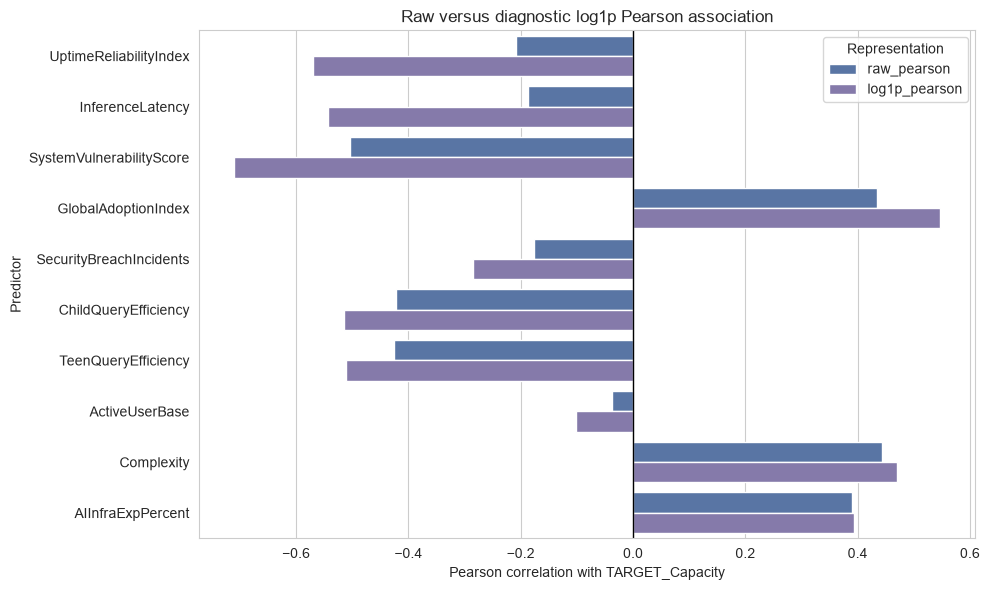

In [342]:
log1p_association_long = (
    log1p_target_association[
        ["raw_pearson", "log1p_pearson"]
    ]
    .reset_index()
    .melt(
        id_vars="feature",
        var_name="representation",
        value_name="pearson",
    )
)

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=log1p_association_long,
        y="feature",
        x="pearson",
        hue="representation",
        order=log1p_target_association.index,
        palette={
            "raw_pearson": "#4C72B0",
            "log1p_pearson": "#8172B2",
        },
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1,
    )
    ax.set(
        title=(
            "Raw versus diagnostic log1p "
            "Pearson association"
        ),
        xlabel=(
            f"Pearson correlation with "
            f"{TARGET_COL}"
        ),
        ylabel="Predictor",
    )
    ax.legend(title="Representation")

    plt.tight_layout()
    plt.show()

### 3.6.6 Interpretation and modelling handoff

All 23 non-group predictors are included in the association screen.
`CaseCount` has an exceptionally strong relationship with the target, with
Pearson and Spearman correlations both approximately 0.999. This is
substantially stronger than every other predictor and requires the dedicated
legitimacy and proxy-risk investigation in Section 3.7. It is not accepted as
deployment-safe from correlation alone.

Several predictors show moderately strong monotonic associations.
`FundingDiversityIndex` and `DatasetDiversityScore` have Spearman correlations
of approximately 0.78 and 0.76, respectively. The three failure-rate
predictors have similar negative correlations of approximately -0.65, which
also suggests that their possible redundancy should be examined in the later
predictor–predictor correlation screen.

Large Pearson–Spearman differences occur for `InferenceLatency`,
`UptimeReliabilityIndex` and `SystemVulnerabilityScore`. Their diagnostic
`log1p` representations substantially strengthen the linear Pearson
relationship, supporting transformed-scale candidates for later pipeline
experiments. This does not yet select a transformation.

`Status` separates the target distribution strongly between values 0 and 1,
but its evidence remains provisional because the value 15 conflicts with the
metadata and is represented by only one development observation. The Status
policy therefore remains unresolved until the predeclared ablation.

`Year` has a weak positive marginal correlation, consistent with the gradual
but non-monotonic aggregate trend observed in Section 3.5. `ActiveUserBase`
has little marginal association on either raw or `log1p` scale. Neither result
justifies automatic feature inclusion or exclusion because interactions,
nonlinear effects and group structure have not yet been evaluated.

No feature is removed, no transformed column is written to `development_df`,
and no modelling policy is frozen in this section. Raw and transformed
representations must be compared later using the same Country-grouped
cross-validation folds.

## 3.7 CaseCount legitimacy and proxy-risk audit

The metadata defines `TARGET_Capacity` as the chatbot's capacity for meaningful
conversation length, whereas `CaseCount` represents the number of AI tasks that
can be run in parallel. They are therefore conceptually related capacity
measures but are not documented as the same quantity.

However, Section 3.6 found an almost perfect association between them. This
section examines whether the relationship resembles a general predictive
signal or a near-deterministic shortcut.

A highly predictive variable is not automatically target leakage. Leakage
would require evidence that the feature was derived from the target or would
not be available at prediction time. Nevertheless, the unusually stable
relationship makes `CaseCount` a high-risk proxy that requires explicit
with-versus-without ablation and robustness analysis.

### 3.7.1 Near-deterministic relationship and offset structure

The analysis uses complete development pairs only. Rows with missing
`CaseCount` are counted but are not imputed during EDA.

The fitted slope, intercept and coefficient of determination are descriptive
in-sample diagnostics, not validation metrics. The later `CaseCountOffset`
baseline must learn its offset separately within each grouped training fold.

In [343]:
case_complete = (
    development_df[
        [
            ID_COL,
            GROUP_COL,
            "Year",
            CASE_COUNT_COL,
            TARGET_COL,
        ]
    ]
    .dropna(subset=[CASE_COUNT_COL])
    .copy()
)

case_complete["offset"] = (
    case_complete[TARGET_COL]
    - case_complete[CASE_COUNT_COL]
)

# Rounding avoids floating-point representation differences
# for values recorded to one decimal place.
case_complete["offset_rounded"] = (
    case_complete["offset"].round(1)
)

case_x = case_complete[CASE_COUNT_COL]
case_y = case_complete[TARGET_COL]

case_slope, case_intercept = np.polyfit(
    case_x,
    case_y,
    deg=1,
)

case_fitted = (
    case_intercept
    + case_slope * case_x
)

case_descriptive_r2 = 1 - (
    np.square(case_y - case_fitted).sum()
    / np.square(case_y - case_y.mean()).sum()
)

case_mean_offset = case_complete["offset"].mean()

case_audit_summary = pd.Series(
    {
        "complete CaseCount-target pairs": (
            len(case_complete)
        ),
        "missing CaseCount rows": int(
            development_df[
                CASE_COUNT_COL
            ].isna().sum()
        ),
        "Pearson correlation": (
            case_x.corr(
                case_y,
                method="pearson",
            )
        ),
        "Spearman correlation": (
            case_x.corr(
                case_y,
                method="spearman",
            )
        ),
        "descriptive OLS slope": case_slope,
        "descriptive OLS intercept": case_intercept,
        "descriptive R2 (not validation)": (
            case_descriptive_r2
        ),
        "mean target-minus-CaseCount offset": (
            case_mean_offset
        ),
        "offset standard deviation": (
            case_complete["offset"].std()
        ),
        "minimum offset": (
            case_complete["offset"].min()
        ),
        "maximum offset": (
            case_complete["offset"].max()
        ),
        "rounded offset values": (
            case_complete[
                "offset_rounded"
            ].nunique()
        ),
        "share within 0.5 of mean offset (%)": (
            100
            * case_complete["offset"]
            .sub(case_mean_offset)
            .abs()
            .le(0.5)
            .mean()
        ),
    },
    name="development evidence",
)

display(case_audit_summary.to_frame())

display(
    case_complete["offset"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .to_frame("target_minus_CaseCount")
)

,development evidence
complete CaseCount-target pairs,"1,651.0000"
missing CaseCount rows,2.0000
Pearson correlation,0.9995
Spearman correlation,0.9994
descriptive OLS slope,0.9990
descriptive OLS intercept,35.9828
descriptive R2 (not validation),0.9991
mean target-minus-CaseCount offset,35.9502
offset standard deviation,0.2940
minimum offset,35.5000


,target_minus_CaseCount
count,"1,651.0000"
mean,35.9502
std,0.2940
min,35.5000
1%,35.5000
5%,35.5000
25%,35.7000
50%,35.9000
75%,36.2000
95%,36.4000


### 3.7.2 Relationship and offset visualisation

The first panel compares the observed target with a transparent unit-slope
offset rule. The second panel shows the discrete offset values, while the third
checks whether the remaining offset changes systematically with `CaseCount`.

The unit-slope line is descriptive only. It is not fitted or evaluated as a
validation model in this section.

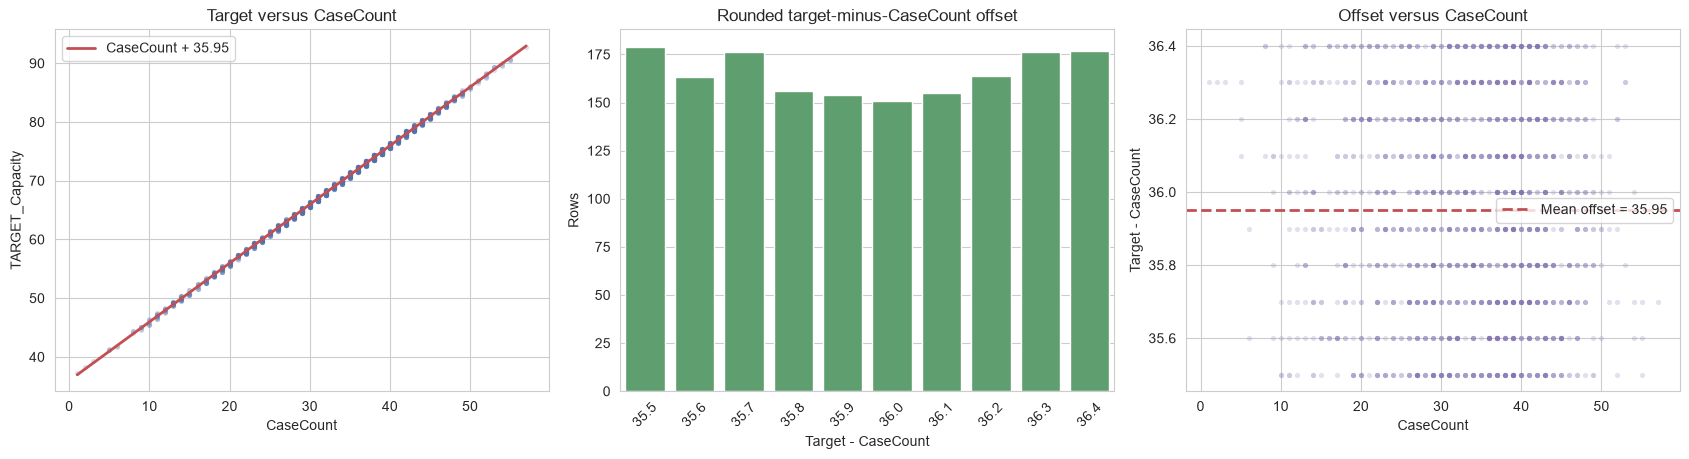

In [344]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.7),
    )

    axes[0].scatter(
        case_x,
        case_y,
        alpha=0.22,
        s=14,
        color="#4C72B0",
        linewidths=0,
        rasterized=True,
    )

    case_grid = np.linspace(
        case_x.min(),
        case_x.max(),
        100,
    )

    axes[0].plot(
        case_grid,
        case_grid + case_mean_offset,
        color="#C44E52",
        linewidth=2,
        label=(
            f"CaseCount + "
            f"{case_mean_offset:.2f}"
        ),
    )
    axes[0].set(
        title="Target versus CaseCount",
        xlabel=CASE_COUNT_COL,
        ylabel=TARGET_COL,
    )
    axes[0].legend()

    sns.countplot(
        data=case_complete,
        x="offset_rounded",
        order=sorted(
            case_complete[
                "offset_rounded"
            ].unique()
        ),
        color="#55A868",
        ax=axes[1],
    )
    axes[1].set(
        title=(
            "Rounded target-minus-CaseCount "
            "offset"
        ),
        xlabel="Target - CaseCount",
        ylabel="Rows",
    )
    axes[1].tick_params(
        axis="x",
        rotation=45,
    )

    axes[2].scatter(
        case_x,
        case_complete["offset"],
        alpha=0.22,
        s=14,
        color="#8172B2",
        linewidths=0,
        rasterized=True,
    )
    axes[2].axhline(
        case_mean_offset,
        color="#C44E52",
        linestyle="--",
        linewidth=2,
        label=(
            f"Mean offset = "
            f"{case_mean_offset:.2f}"
        ),
    )
    axes[2].set(
        title="Offset versus CaseCount",
        xlabel=CASE_COUNT_COL,
        ylabel="Target - CaseCount",
    )
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### 3.7.3 Offset stability across Year and Country

A useful predictor may remain strongly associated with the target while its
relationship changes across time or groups. The following profiles therefore
test whether the `CaseCount` offset is stable across development Years and
Countries.

The row with missing `Year` is retained in the displayed table but excluded
from the temporal stability summary and plot.

In [345]:
case_offset_by_year = (
    case_complete.groupby(
        "Year",
        dropna=False,
    )["offset"]
    .agg(
        rows="size",
        mean_offset="mean",
        std_offset="std",
        min_offset="min",
        max_offset="max",
    )
    .sort_index()
)

case_offset_by_country = (
    case_complete.groupby(
        GROUP_COL
    )["offset"]
    .agg(
        rows="size",
        mean_offset="mean",
        std_offset="std",
        min_offset="min",
        max_offset="max",
    )
    .sort_index()
)

valid_year_offset = case_offset_by_year.loc[
    case_offset_by_year.index.notna()
].copy()

offset_stability_summary = pd.Series(
    {
        "SD of valid-Year mean offsets": (
            valid_year_offset[
                "mean_offset"
            ].std()
        ),
        "range of valid-Year mean offsets": (
            valid_year_offset[
                "mean_offset"
            ].max()
            - valid_year_offset[
                "mean_offset"
            ].min()
        ),
        "SD of Country mean offsets": (
            case_offset_by_country[
                "mean_offset"
            ].std()
        ),
        "minimum Country mean offset": (
            case_offset_by_country[
                "mean_offset"
            ].min()
        ),
        "maximum Country mean offset": (
            case_offset_by_country[
                "mean_offset"
            ].max()
        ),
    },
    name="development evidence",
)

display(case_offset_by_year)
display(offset_stability_summary.to_frame())

,rows,mean_offset,std_offset,min_offset,max_offset
Year,,,,,
"2,002.0000",103,35.9816,0.3045,35.5000,36.4000
"2,003.0000",102,35.9422,0.3046,35.5000,36.4000
"2,004.0000",102,36.0118,0.2885,35.5000,36.4000
"2,005.0000",103,35.9301,0.3016,35.5000,36.4000
"2,006.0000",103,35.9485,0.2996,35.5000,36.4000
"2,007.0000",103,35.9330,0.2908,35.5000,36.4000
"2,008.0000",103,35.9883,0.2888,35.5000,36.4000
"2,009.0000",102,35.9314,0.2807,35.5000,36.4000
"2,010.0000",103,35.9340,0.2878,35.5000,36.4000


,development evidence
SD of valid-Year mean offsets,0.0279
range of valid-Year mean offsets,0.1108
SD of Country mean offsets,0.1043
minimum Country mean offset,35.7000
maximum Country mean offset,36.4000


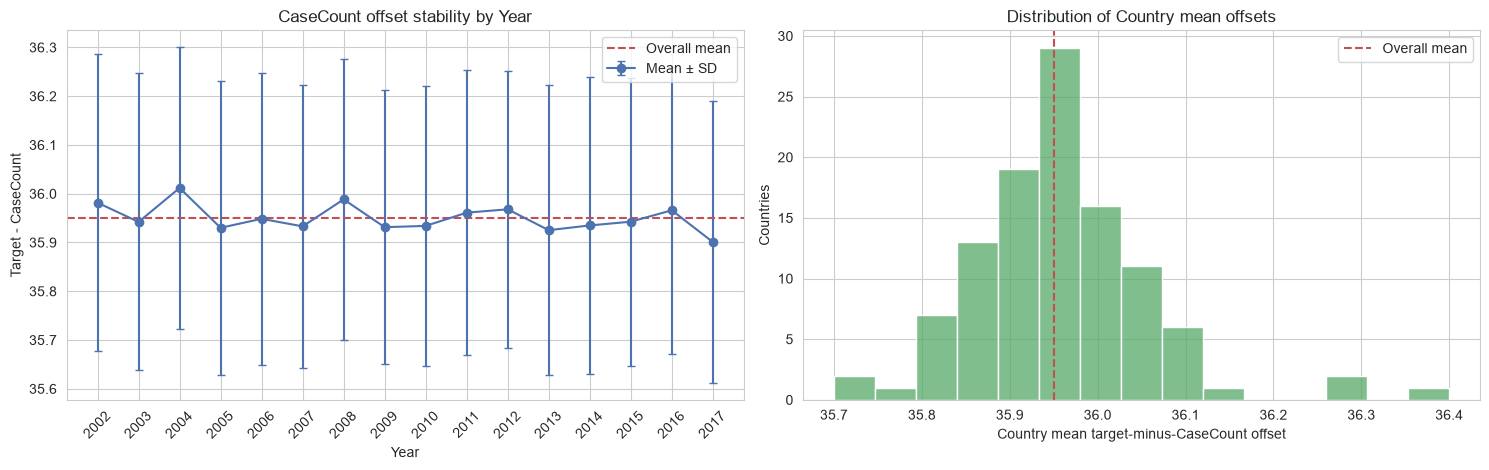

In [346]:
plot_offset_years = (
    valid_year_offset.index
    .astype(int)
    .to_numpy()
)

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 4.8),
    )

    axes[0].errorbar(
        plot_offset_years,
        valid_year_offset["mean_offset"],
        yerr=valid_year_offset["std_offset"],
        color="#4C72B0",
        marker="o",
        capsize=3,
        label="Mean ± SD",
    )
    axes[0].axhline(
        case_mean_offset,
        color="#C44E52",
        linestyle="--",
        label="Overall mean",
    )
    axes[0].set(
        title="CaseCount offset stability by Year",
        xlabel="Year",
        ylabel="Target - CaseCount",
        xticks=plot_offset_years,
    )
    axes[0].tick_params(
        axis="x",
        rotation=45,
    )
    axes[0].legend()

    sns.histplot(
        x=case_offset_by_country["mean_offset"],
        bins=15,
        color="#55A868",
        edgecolor="white",
        ax=axes[1],
    )
    axes[1].axvline(
        case_mean_offset,
        color="#C44E52",
        linestyle="--",
        label="Overall mean",
    )
    axes[1].set(
        title=(
            "Distribution of Country "
            "mean offsets"
        ),
        xlabel=(
            "Country mean "
            "target-minus-CaseCount offset"
        ),
        ylabel="Countries",
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 3.7.4 Interpretation and decision boundary

The metadata describes `CaseCount` and `TARGET_Capacity` as different but
conceptually related capacity measures. Structurally, `CaseCount` is supplied
as a candidate predictor. The observed development relationship is therefore
not sufficient to prove target leakage.

Nevertheless, the empirical relationship is unusually deterministic.
Pearson correlation is approximately 0.9995, the fitted slope is approximately
1, and every complete observation satisfies an offset between 35.5 and 36.4.
The mean offset is also highly stable across both Year and Country groups.
This is much stronger and more regular than would normally be expected from
two distinct operational measurements.

`CaseCount` is therefore classified as a high-risk target proxy rather than
being accepted uncritically. It is not removed in Phase 3 because feature
removal requires comparative evidence, but models using it must not be judged
only by their low error.

The following modelling safeguards are retained:

1. `CaseCountOffset` remains a transparent problem-specific baseline with a
   fixed coefficient of one and an offset learned inside each grouped training
   fold.
2. Models with and without `CaseCount` must be compared using identical
   Country-grouped folds.
3. Missing `CaseCount` values must be imputed inside each training fold.
4. Any finalist using `CaseCount` requires a later prediction-sensitivity and
   with-versus-without ablation.
5. Final judgment must discuss shortcut dependence, interpretability and
   robustness rather than selecting the lowest-error model automatically.

`CaseCount` therefore remains in the candidate feature set, while its
deployment legitimacy remains conditional on the later ablation and robustness
evidence. No development-policy state is finalised in this section, and the
locked holdout remains untouched.

## 3.8 Predictor redundancy and multicollinearity screen

This section examines pairwise relationships among all 23 non-group predictors
using the development partition only. `RecordID`, `TARGET_Capacity` and
`Country` are excluded because they are the identifier, target and group label,
respectively.

Pearson correlation is used to identify approximately linear redundancy, while
Spearman correlation identifies monotonic redundancy that may be obscured by
skewed or nonlinear measurement scales.

Pairwise correlations use the available complete observations for each pair.
The analysis is exploratory: a strong correlation flags potential redundancy
but is not an automatic feature-removal rule.

### 3.8.1 Complete Pearson and Spearman matrices

Both heatmaps contain every eligible predictor in the original dataset order.
They use the same colour scale so that differences between linear and monotonic
association can be compared directly.

In [347]:
collinearity_features = relationship_features.copy()

assert (
    set(collinearity_features)
    == set(predictor_columns) - {GROUP_COL}
)

assert all(
    pd.api.types.is_numeric_dtype(
        development_df[feature]
    )
    for feature in collinearity_features
)

pearson_predictor_correlation = (
    development_df[collinearity_features]
    .corr(method="pearson")
)

spearman_predictor_correlation = (
    development_df[collinearity_features]
    .corr(method="spearman")
)

print(
    "Predictors in each correlation matrix:",
    len(collinearity_features),
)

Predictors in each correlation matrix: 23


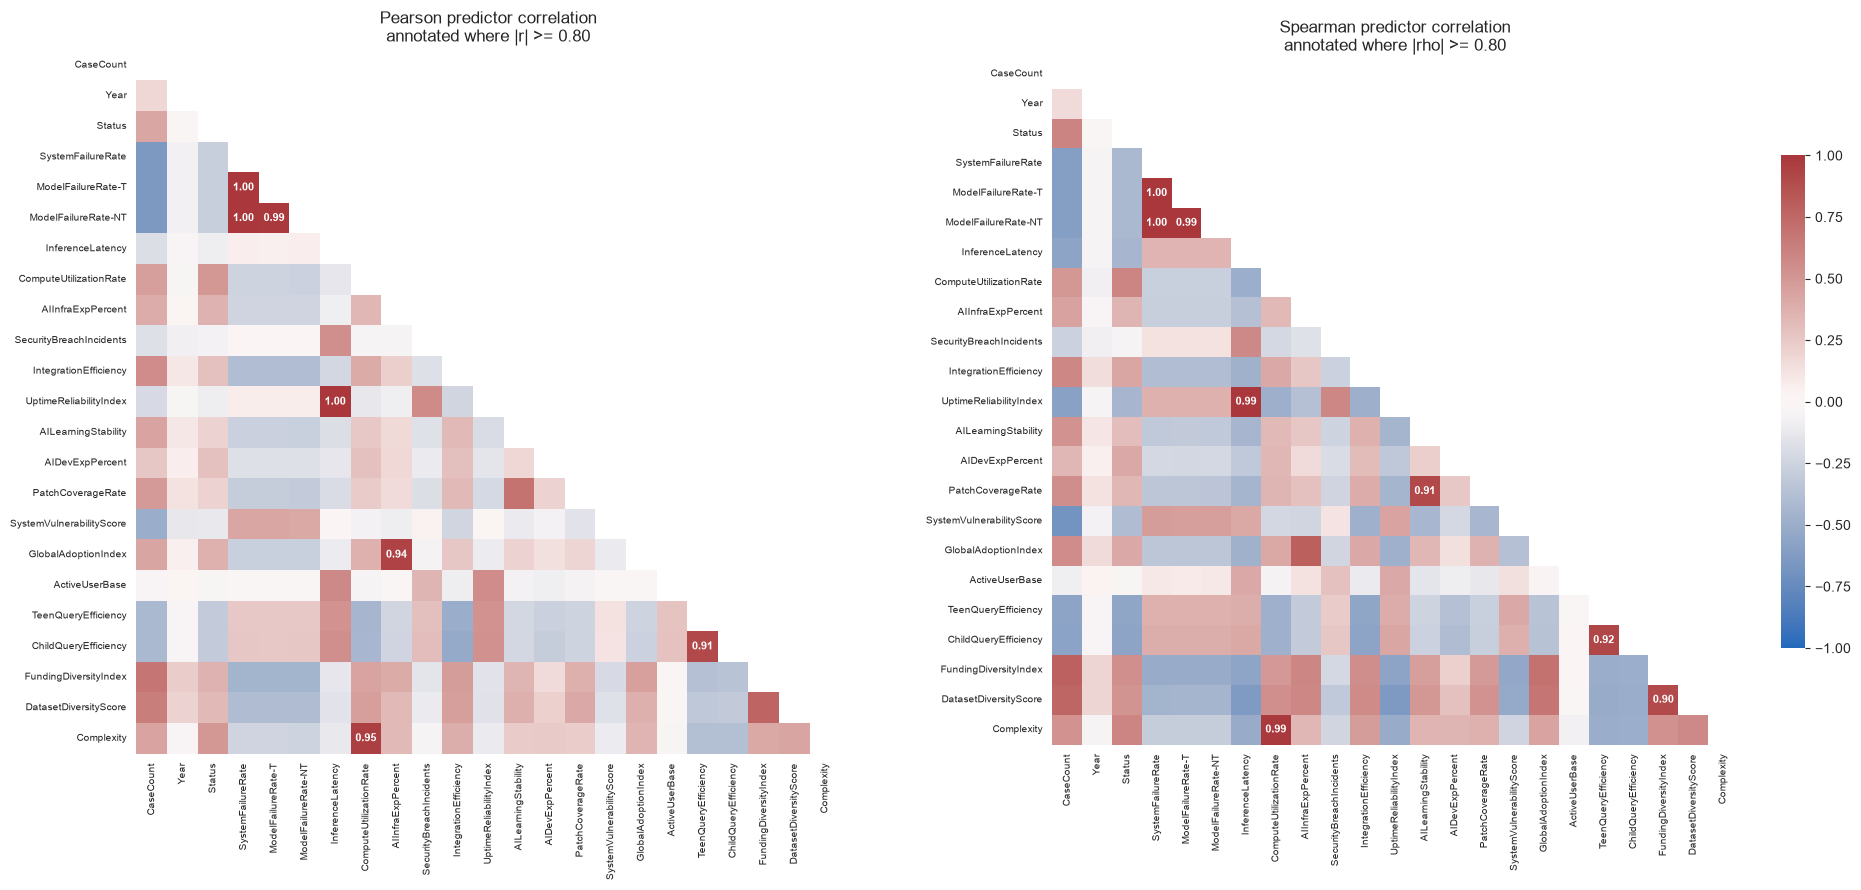

In [348]:
annotation_threshold = 0.80

# Hide the diagonal and duplicated upper triangle.
correlation_mask = np.triu(
    np.ones_like(
        pearson_predictor_correlation,
        dtype=bool,
    ),
    k=0,
)

# Display values only for strong relationships.
pearson_annotations = (
    pearson_predictor_correlation.map(
        lambda value: (
            f"{value:.2f}"
            if abs(value) >= annotation_threshold
            else ""
        )
    )
)

spearman_annotations = (
    spearman_predictor_correlation.map(
        lambda value: (
            f"{value:.2f}"
            if abs(value) >= annotation_threshold
            else ""
        )
    )
)

with warnings.catch_warnings(), sns.axes_style("white"):
    warnings.filterwarnings(
        "ignore",
        message=r"The set_bad function will be deprecated.*",
        category=PendingDeprecationWarning,
        module=r"seaborn\.matrix",
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(20, 9),
    )

    sns.heatmap(
        pearson_predictor_correlation,
        mask=correlation_mask,
        vmin=-1,
        vmax=1,
        center=0,
        cmap="vlag",
        square=True,
        annot=pearson_annotations,
        fmt="",
        annot_kws={
            "size": 8,
            "weight": "bold",
        },
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_title(
        "Pearson predictor correlation\n"
        f"annotated where |r| >= "
        f"{annotation_threshold:.2f}"
    )

    sns.heatmap(
        spearman_predictor_correlation,
        mask=correlation_mask,
        vmin=-1,
        vmax=1,
        center=0,
        cmap="vlag",
        square=True,
        annot=spearman_annotations,
        fmt="",
        annot_kws={
            "size": 8,
            "weight": "bold",
        },
        cbar_kws={"shrink": 0.7},
        ax=axes[1],
    )
    axes[1].set_title(
        "Spearman predictor correlation\n"
        f"annotated where |rho| >= "
        f"{annotation_threshold:.2f}"
    )

    for axis in axes:
        axis.tick_params(
            axis="x",
            rotation=90,
            labelsize=7,
        )
        axis.tick_params(
            axis="y",
            rotation=0,
            labelsize=7,
        )

    plt.tight_layout()
    plt.show()

### 3.8.2 Pairwise redundancy register

The complete upper triangle contains 253 unique predictor pairs. A screening
threshold of 0.80 on the larger absolute Pearson or Spearman coefficient is
used to produce a readable strong-pair register.

The threshold is a descriptive flag only. It does not delete either member of
a pair and is not a model-selection criterion.

In [349]:
upper_mask = np.triu(
    np.ones(
        pearson_predictor_correlation.shape,
        dtype=bool,
    ),
    k=1,
)

pair_rows = []

for row_index, column_index in zip(
    *np.where(upper_mask)
):
    feature_1 = collinearity_features[
        row_index
    ]
    feature_2 = collinearity_features[
        column_index
    ]

    pearson = (
        pearson_predictor_correlation.iloc[
            row_index,
            column_index,
        ]
    )
    spearman = (
        spearman_predictor_correlation.iloc[
            row_index,
            column_index,
        ]
    )

    pair_rows.append(
        {
            "feature_1": feature_1,
            "feature_2": feature_2,
            "pearson": pearson,
            "spearman": spearman,
            "max_abs_correlation": max(
                abs(pearson),
                abs(spearman),
            ),
            "absolute_method_gap": abs(
                abs(pearson)
                - abs(spearman)
            ),
        }
    )

predictor_pair_correlations = (
    pd.DataFrame(pair_rows)
    .sort_values(
        "max_abs_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

strong_pair_threshold = 0.80

strong_predictor_pairs = (
    predictor_pair_correlations.loc[
        predictor_pair_correlations[
            "max_abs_correlation"
        ].ge(strong_pair_threshold)
    ]
    .copy()
)

largest_method_gaps = (
    predictor_pair_correlations
    .sort_values(
        "absolute_method_gap",
        ascending=False,
    )
    .head(10)
)

print(
    "Unique predictor pairs:",
    len(predictor_pair_correlations),
)
print(
    "Pairs with maximum absolute "
    f"correlation >= {strong_pair_threshold:.2f}:",
    len(strong_predictor_pairs),
)

display(strong_predictor_pairs)

Unique predictor pairs: 253
Pairs with maximum absolute correlation >= 0.80: 9


,feature_1,feature_2,pearson,spearman,max_abs_correlation,absolute_method_gap
0,SystemFailureRate,ModelFailureRate-T,0.9980,0.9984,0.9984,0.0004
1,SystemFailureRate,ModelFailureRate-NT,0.9980,0.9984,0.9984,0.0004
2,InferenceLatency,UptimeReliabilityIndex,0.9969,0.9932,0.9969,0.0037
3,ModelFailureRate-T,ModelFailureRate-NT,0.9920,0.9940,0.9940,0.0019
4,ComputeUtilizationRate,Complexity,0.9545,0.9884,0.9884,0.0339
5,AIInfraExpPercent,GlobalAdoptionIndex,0.9423,0.7899,0.9423,0.1524
6,TeenQueryEfficiency,ChildQueryEfficiency,0.9109,0.9227,0.9227,0.0118
7,AILearningStability,PatchCoverageRate,0.6917,0.9119,0.9119,0.2202
8,FundingDiversityIndex,DatasetDiversityScore,0.7677,0.9017,0.9017,0.1340


#### Pearson–Spearman scale differences

Large differences between Pearson and Spearman coefficients indicate
relationships that are monotonic but not well represented as linear on the raw
scale. These pairs are relevant to the transformation hypotheses identified in
Sections 3.4 and 3.6.display(largest_method_gaps)

### 3.8.3 Strong predictor-pair visualisations

Every pair flagged by the 0.80 screening threshold is plotted. The figures are
divided into pages of six panels for readability; the loop continues until all
flagged pairs have been displayed.

The red line represents a descriptive linear trend. Differences between the
point pattern, linear trend and Spearman coefficient help distinguish linear
duplication from nonlinear monotonic redundancy.

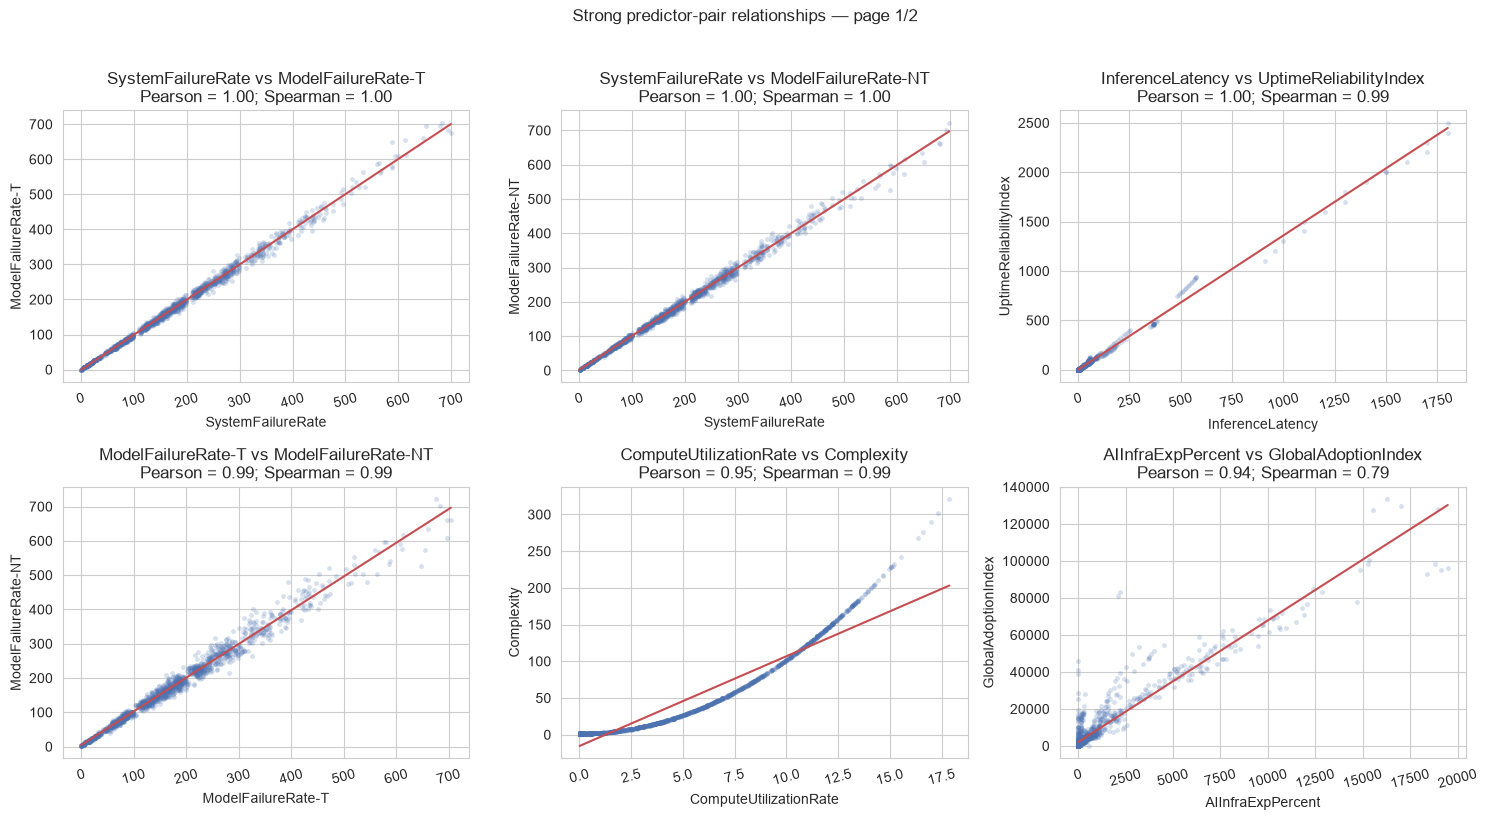

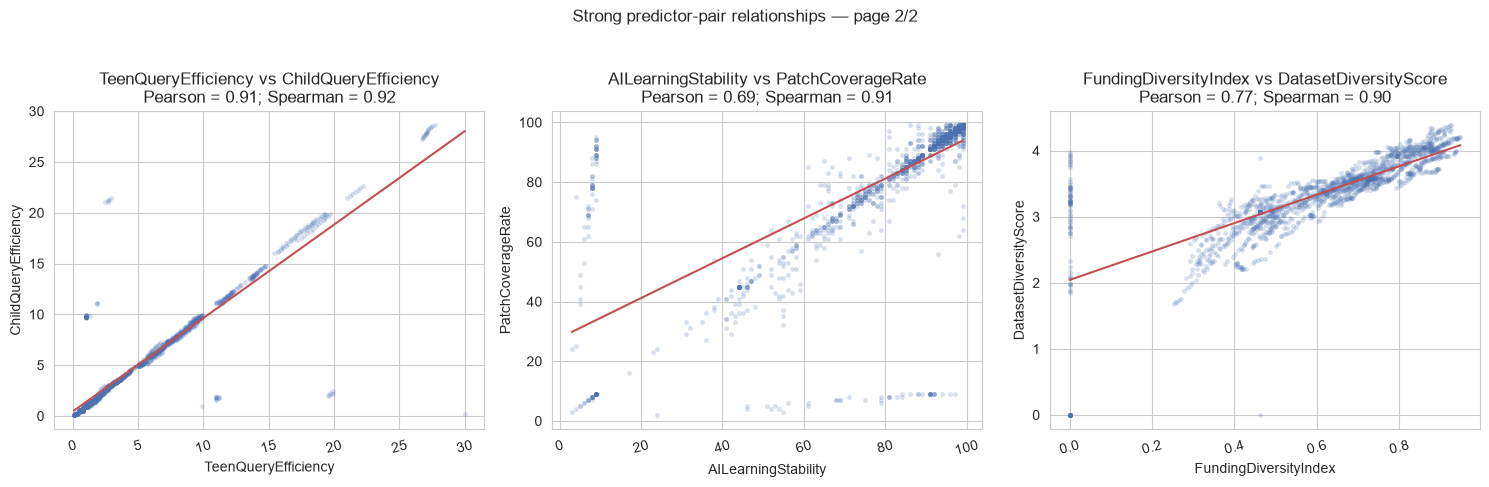

In [350]:
def plot_strong_pair_pages(
    data,
    pairs,
    page_size=6,
):
    page_total = int(
        np.ceil(len(pairs) / page_size)
    )

    for page_number, start in enumerate(
        range(0, len(pairs), page_size),
        start=1,
    ):
        page_pairs = pairs.iloc[
            start : start + page_size
        ]

        fig, axes = plt.subplots(
            2,
            3,
            figsize=(15, 8),
        )
        axes = np.asarray(axes).ravel()

        for axis, (_, row) in zip(
            axes,
            page_pairs.iterrows(),
        ):
            feature_1 = row["feature_1"]
            feature_2 = row["feature_2"]

            complete_pairs = data[
                [feature_1, feature_2]
            ].dropna()

            axis.scatter(
                complete_pairs[feature_1],
                complete_pairs[feature_2],
                alpha=0.22,
                s=12,
                color="#4C72B0",
                linewidths=0,
                rasterized=True,
            )

            sns.regplot(
                data=complete_pairs,
                x=feature_1,
                y=feature_2,
                scatter=False,
                ci=None,
                color="#C44E52",
                line_kws={"linewidth": 1.5},
                ax=axis,
            )

            axis.set(
                title=(
                    f"{feature_1} vs "
                    f"{feature_2}\n"
                    f"Pearson = "
                    f"{row['pearson']:.2f}; "
                    f"Spearman = "
                    f"{row['spearman']:.2f}"
                ),
                xlabel=feature_1,
                ylabel=feature_2,
            )
            axis.tick_params(
                axis="x",
                rotation=15,
            )

        for axis in axes[len(page_pairs) :]:
            axis.set_visible(False)

        fig.suptitle(
            "Strong predictor-pair relationships "
            f"— page {page_number}/{page_total}",
            y=1.02,
        )

        plt.tight_layout()
        plt.show()


with sns.axes_style("whitegrid"):
    plot_strong_pair_pages(
        development_df,
        strong_predictor_pairs,
    )

### 3.8.4 Interpretation and modelling implications

The complete screen identifies several clear redundancy families.

The three failure-rate predictors are almost perfectly correlated. This is
consistent with the metadata: `SystemFailureRate` is a system-wide measure,
while `ModelFailureRate-T` and `ModelFailureRate-NT` are technical and
non-technical sub-metrics. Their conceptual overlap explains the observed
redundancy, but does not establish that any one feature should be removed.

`InferenceLatency` and `UptimeReliabilityIndex` are also almost perfectly
associated despite representing different metadata concepts. Their
relationship should therefore be treated as possible constructed or proxy
redundancy. `ComputeUtilizationRate` and `Complexity` show a similarly strong
monotonic relationship.

Additional redundancy appears between AI infrastructure expenditure and global
adoption, teen and child query efficiency, learning stability and patch
coverage, and the two diversity measures. For the latter pairs, Spearman
correlation is notably stronger than Pearson correlation, indicating nonlinear
or scale-dependent monotonic relationships.

These findings have different implications across model families:

- unregularised linear coefficients may become unstable or difficult to
  interpret when several predictors carry almost the same signal;
- Ridge regression is retained as a candidate because L2 regularisation can
  stabilise correlated coefficients;
- Lasso may select one member of a correlated family somewhat arbitrarily, so
  coefficient and fold-selection stability must be examined;
- polynomial expansion can amplify collinearity and therefore requires
  regularisation;
- tree-based importance may be divided across correlated predictors, so low
  importance for one member does not necessarily imply irrelevance.

No feature is removed in this section. Predictive performance, grouped-fold
stability, interpretability and robustness must be considered together before
any optional exclusion is justified. `ADDITIONAL_FEATURE_EXCLUSIONS` therefore
remains empty, and all eligible raw predictors continue into the model-policy
experiments.

## 3.9 Development support and extrapolation-risk register

This section freezes the predictor support observed in `development_df` before
the locked holdout or external feature values are examined.

All 24 candidate predictors are covered:

- the 23 non-group numeric predictors are described using missingness,
  cardinality and development-only quantiles;
- `Country` is described through its group-size structure because arithmetic
  ranges of Country identifiers have no meaningful quantitative interpretation.

For numeric predictor $x$, the central support span is defined as:

$$
S_x = p_{99}(x) - p_{01}(x)
$$

The lower- and upper-tail extension ratios are defined as:

$$
\begin{aligned}
L_x &= \frac{p_{01}(x) - \min(x)}{S_x}, \\
U_x &= \frac{\max(x) - p_{99}(x)}{S_x}.
\end{aligned}
$$

These scale-free ratios show how far the observed extremes extend beyond the
central 98% of the development distribution. A large ratio is an
extrapolation-risk flag, not evidence that the observation should be removed,
capped or treated as an error.

No imputation, transformation, outlier removal or external-data comparison is
performed in this section.

In [351]:
# Scope: development_df only.

support_features = [
    feature
    for feature in predictor_columns
    if feature != GROUP_COL
    and pd.api.types.is_numeric_dtype(
        development_df[feature]
    )
]

# Country receives a separate structural profile below.
covered_predictors = set(support_features) | {GROUP_COL}

assert covered_predictors == set(predictor_columns)
assert len(support_features) == len(predictor_columns) - 1

support_values = development_df[support_features]

support_quantiles = support_values.quantile(
    [0.00, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]
).T

support_quantiles.columns = [
    "min",
    "p01",
    "p05",
    "median",
    "p95",
    "p99",
    "max",
]

development_support = pd.DataFrame(
    {
        "non_missing_n": support_values.notna().sum(),
        "missing_n": support_values.isna().sum(),
        "missing_pct": (
            100 * support_values.isna().mean()
        ),
        "unique_n": support_values.nunique(
            dropna=True
        ),
    }
).join(support_quantiles)

development_support["central_98_span"] = (
    development_support["p99"]
    - development_support["p01"]
)

# A zero span cannot be used as a ratio denominator.
nonzero_span = development_support[
    "central_98_span"
].replace(0, np.nan)

development_support["lower_tail_extension"] = (
    development_support["p01"]
    - development_support["min"]
) / nonzero_span

development_support["upper_tail_extension"] = (
    development_support["max"]
    - development_support["p99"]
) / nonzero_span

development_support["largest_tail_extension"] = (
    development_support[
        [
            "lower_tail_extension",
            "upper_tail_extension",
        ]
    ].max(axis=1)
)

# Country is a grouping identifier, so group sizes are more meaningful
# than numeric quantiles of its encoded values.
country_group_sizes = (
    development_df.groupby(GROUP_COL).size()
)

country_support = pd.Series(
    {
        "non_missing_rows": int(
            development_df[GROUP_COL].notna().sum()
        ),
        "missing_rows": int(
            development_df[GROUP_COL].isna().sum()
        ),
        "observed_groups": int(
            country_group_sizes.size
        ),
        "singleton_groups": int(
            country_group_sizes.eq(1).sum()
        ),
        "minimum_rows_per_group": int(
            country_group_sizes.min()
        ),
        "median_rows_per_group": float(
            country_group_sizes.median()
        ),
        "maximum_rows_per_group": int(
            country_group_sizes.max()
        ),
    },
    name="Country structural support",
).to_frame()

support_coverage = pd.Series(
    {
        "candidate_predictors": len(
            predictor_columns
        ),
        "numeric_support_profiles": len(
            support_features
        ),
        "group_structural_profiles": 1,
        "uncovered_predictors": len(
            set(predictor_columns)
            - covered_predictors
        ),
    },
    name="count",
).to_frame()

display(support_coverage)

with pd.option_context("display.max_rows", None):
    display(development_support.round(3))

display(country_support)

,count
candidate_predictors,24
numeric_support_profiles,23
group_structural_profiles,1
uncovered_predictors,0


,non_missing_n,missing_n,missing_pct,unique_n,min,p01,p05,median,p95,p99,max,central_98_span,lower_tail_extension,upper_tail_extension,largest_tail_extension
CaseCount,1651,2,0.1210,54,1.0000,10.0000,15.0000,35.0000,47.0000,51.5000,57.0000,41.5000,0.2170,0.1330,0.2170
Year,1652,1,0.0600,16,"2,002.0000","2,002.0000","2,002.0000","2,010.0000","2,017.0000","2,017.0000","2,017.0000",15.0000,0.0000,0.0000,0.0000
Status,1653,0,0.0000,3,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,15.0000,1.0000,0.0000,14.0000,14.0000
SystemFailureRate,1653,0,0.0000,360,1.0000,3.5200,12.0000,146.0000,383.0000,547.0400,699.0000,543.5200,0.0050,0.2800,0.2800
ModelFailureRate-T,1653,0,0.0000,247,0.0000,2.0000,12.0000,144.0000,385.6000,561.9200,704.0000,559.9200,0.0040,0.2540,0.2540
ModelFailureRate-NT,1652,1,0.0600,246,2.0000,4.0000,14.0000,146.0000,388.0000,530.9800,722.0000,526.9800,0.0040,0.3620,0.3620
InferenceLatency,1653,0,0.0000,176,0.0000,0.0000,0.0000,3.0000,136.8000,574.9600,"1,800.0000",574.9600,0.0000,2.1310,2.1310
ComputeUtilizationRate,1653,0,0.0000,810,0.0100,0.0100,0.0100,3.9200,12.5500,14.2150,17.8700,14.2050,0.0000,0.2570,0.2570
AIInfraExpPercent,1653,0,0.0000,1321,0.0000,0.0000,0.0000,66.7290,"5,350.6180","11,628.8040","19,479.9120","11,628.8040",0.0000,0.6750,0.6750
SecurityBreachIncidents,1653,0,0.0000,631,0.0000,0.0000,0.0000,15.0000,"8,889.6000","49,370.8400","212,183.0000","49,370.8400",0.0000,3.2980,3.2980


,Country structural support
non_missing_rows,"1,653.0000"
missing_rows,0.0000
observed_groups,108.0000
singleton_groups,5.0000
minimum_rows_per_group,1.0000
median_rows_per_group,16.0000
maximum_rows_per_group,16.0000


### 3.9.1 Scale-free tail-extension comparison

The following plot compares both tail-extension ratios for every non-group
numeric predictor. Predictors are ordered by their largest observed extension.

A symmetric-logarithmic horizontal scale is used because the ratios range from
zero to values substantially greater than one. The dashed reference line at
one indicates that the distance between an extreme and the corresponding
percentile boundary is as large as the entire central 98% support span.

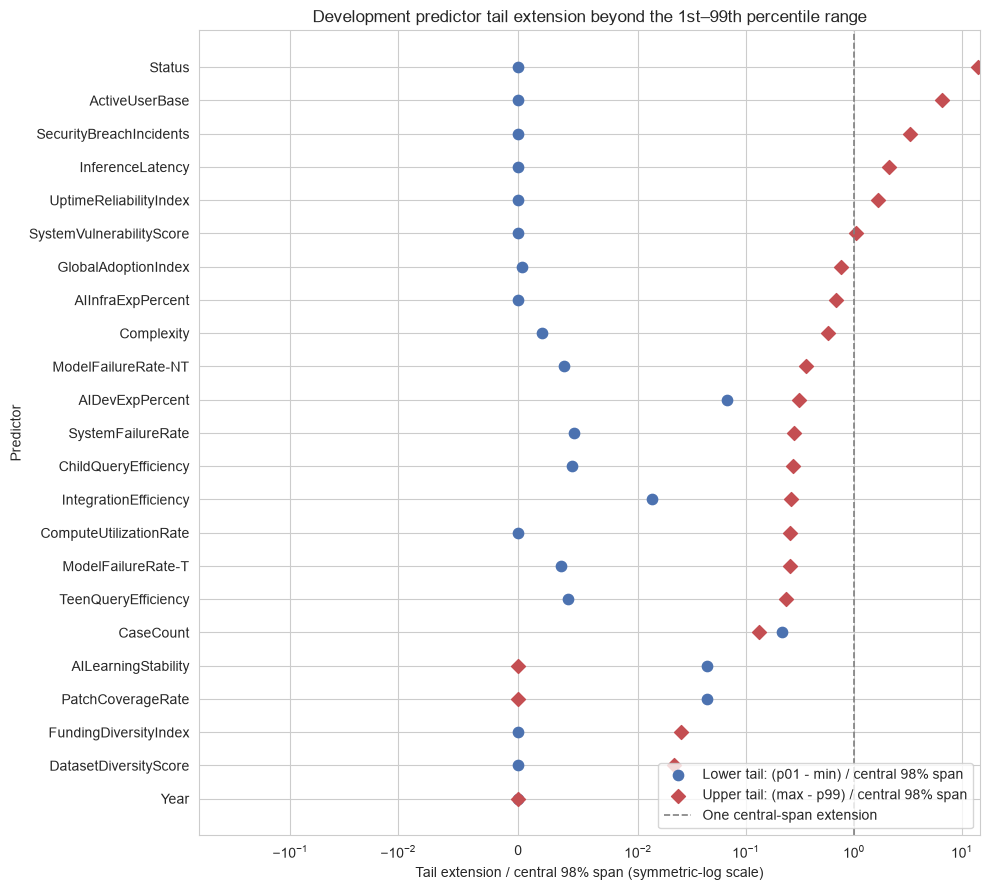

In [352]:
plot_order = (
    development_support
    .sort_values(
        "largest_tail_extension",
        ascending=False,
    )
    .index
    .tolist()
)

plot_positions = np.arange(len(plot_order))

lower_plot_values = development_support.loc[
    plot_order,
    "lower_tail_extension",
]

upper_plot_values = development_support.loc[
    plot_order,
    "upper_tail_extension",
]

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 9))

    ax.scatter(
        lower_plot_values,
        plot_positions,
        color="#4C72B0",
        marker="o",
        s=55,
        label=(
            "Lower tail: "
            "(p01 - min) / central 98% span"
        ),
    )

    ax.scatter(
        upper_plot_values,
        plot_positions,
        color="#C44E52",
        marker="D",
        s=50,
        label=(
            "Upper tail: "
            "(max - p99) / central 98% span"
        ),
    )

    ax.axvline(
        1.0,
        color="grey",
        linestyle="--",
        linewidth=1.2,
        label="One central-span extension",
    )

    ax.set_xscale(
        "symlog",
        linthresh=0.01,
    )

    ax.set_yticks(
        plot_positions,
        labels=plot_order,
    )
    ax.invert_yaxis()

    ax.set(
        title=(
            "Development predictor tail extension beyond "
            "the 1st–99th percentile range"
        ),
        xlabel=(
            "Tail extension / central 98% span "
            "(symmetric-log scale)"
        ),
        ylabel="Predictor",
    )

    ax.legend(
        loc="lower right",
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

### 3.9.2 Predeclared robustness scenarios

The support register is used to define robustness checks before model
selection and before external feature values are opened. These checks will be
implemented later against the selected fold-safe pipeline.

Each predictor perturbation must be applied separately so that its effect can
be distinguished from the effects of other simultaneous changes.

In [353]:
high_tail_continuous_features = [
    feature
    for feature in continuous_eda_features
    if development_support.loc[
        feature,
        "largest_tail_extension",
    ] >= 1.0
]

predeclared_stress_plan = pd.DataFrame(
    [
        {
            "scenario": "missing_each_numeric",
            "applies_to": (
                f"all {len(support_features)} "
                "non-group numeric predictors"
            ),
            "construction": (
                "set one predictor at a time to NaN"
            ),
            "later_check": (
                "finite predictions and prediction change "
                "versus the unchanged row"
            ),
        },
        {
            "scenario": "upper_support_extrapolation",
            "applies_to": ", ".join(
                high_tail_continuous_features
            ),
            "construction": (
                "set one predictor at a time to "
                "max + central_98_span"
            ),
            "later_check": (
                "finite predictions; quantify "
                "extrapolation sensitivity"
            ),
        },
        {
            "scenario": "future_year",
            "applies_to": "Year",
            "construction": (
                "set Year to the development "
                "maximum plus one"
            ),
            "later_check": (
                "finite predictions; quantify temporal "
                "extrapolation sensitivity"
            ),
        },
        {
            "scenario": "unseen_country",
            "applies_to": (
                "Country if one-hot policy is selected"
            ),
            "construction": (
                "replace Country with a category "
                "absent from model fitting"
            ),
            "later_check": (
                "finite predictions under "
                "handle_unknown='ignore'"
            ),
        },
        {
            "scenario": "status_policy_stress",
            "applies_to": "Status",
            "construction": (
                "compare the observed anomalous value 15 "
                "with NaN under the frozen policy"
            ),
            "later_check": (
                "finite predictions; report "
                "policy sensitivity"
            ),
        },
        {
            "scenario": "CaseCount_shift",
            "applies_to": (
                "CaseCount if retained"
            ),
            "construction": (
                "add one development standard deviation"
            ),
            "later_check": (
                "quantify shortcut/proxy sensitivity"
            ),
        },
    ]
)

print(
    "Continuous predictors predeclared "
    "for upper-support stress:",
    high_tail_continuous_features,
)

# Display complete text and wrap long cells for readability.
# Display every column without truncating long text.
with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(predeclared_stress_plan)

print(
    "Support register frozen from development_df only; "
    "locked-holdout and external feature values "
    "remain unopened."
)

Continuous predictors predeclared for upper-support stress: ['InferenceLatency', 'SecurityBreachIncidents', 'UptimeReliabilityIndex', 'SystemVulnerabilityScore', 'ActiveUserBase']


,scenario,applies_to,construction,later_check
0,missing_each_numeric,all 23 non-group numeric predictors,set one predictor at a time to NaN,finite predictions and prediction change versus the unchanged row
1,upper_support_extrapolation,"InferenceLatency, SecurityBreachIncidents, UptimeReliabilityIndex, SystemVulnerabilityScore, ActiveUserBase",set one predictor at a time to max + central_98_span,finite predictions; quantify extrapolation sensitivity
2,future_year,Year,set Year to the development maximum plus one,finite predictions; quantify temporal extrapolation sensitivity
3,unseen_country,Country if one-hot policy is selected,replace Country with a category absent from model fitting,finite predictions under handle_unknown='ignore'
4,status_policy_stress,Status,compare the observed anomalous value 15 with NaN under the frozen policy,finite predictions; report policy sensitivity
5,CaseCount_shift,CaseCount if retained,add one development standard deviation,quantify shortcut/proxy sensitivity


Support register frozen from development_df only; locked-holdout and external feature values remain unopened.


### 3.9.3 Interpretation and modelling handoff

The support audit covers all 24 candidate predictors: 23 non-group numeric
support profiles and one structural `Country` profile, with no predictors left
uncovered.

The largest extension is observed for `Status`, primarily because the
metadata-invalid value 15 lies far beyond the dominant values 0 and 1. This
supports resolving `STATUS_INVALID_POLICY` explicitly rather than treating 15
as an ordinary continuous extreme.

Several continuous predictors, including `ActiveUserBase`,
`SecurityBreachIncidents`, `InferenceLatency`, `UptimeReliabilityIndex` and
`SystemVulnerabilityScore`, have upper-tail extensions at least as large as
their central 98% spans. These variables therefore require later
transformation and robustness experiments inside fold-safe pipelines.

The observed extremes are retained at this stage. Large extension ratios do
not independently justify deletion, winsorisation or clipping because they may
represent valid development observations. The locked holdout and external
feature values remain uninspected.

## 3.10 EDA-to-model decisions

| Key development evidence | Modelling decision | Later check |
|---|---|---|
| The target is moderately negatively skewed, with only eight lower-tail Tukey flags. | Retain the raw target and all valid labelled rows; report MAE with RMSE and residual diagnostics. | Grouped CV and Phase 6 error analysis |
| Countries repeat across Years and show substantial between-Country variation. | Keep Country-grouped validation; compare `group_only` and one-hot Country policies. | Step 4.6 policy ablation |
| Eight predictor values are missing and `Status=15` conflicts with the documented values 0 and 1. | Perform median imputation inside each training fold and compare the two predeclared Status policies. | Steps 4.5–4.6 |
| `CaseCount` has an almost deterministic relationship with the target. | Treat it as a high-risk proxy; compare models with and without it and retain the transparent offset baseline. | Steps 4.6, 4.7 and 6.7 |
| Several predictors are strongly skewed, nonlinear or highly correlated. | Compare raw and `log1p` representations, regularised linear models and tree-based models; do not remove features from EDA alone. | Phases 4–6 |

### Phase 3 decision gate

- [x] All target-informed EDA used `development_df` only.
- [x] All 24 candidate predictors were examined.
- [x] No rows were removed, capped or imputed during EDA.
- [x] The split, CaseCount safeguards and robustness scenarios were recorded.

**Decision:** Phase 3 is complete. Proceed to Phase 4 for leakage-safe
preprocessing and development-only policy ablations. The locked holdout and
external feature values remain unopened, and
`DEVELOPMENT_POLICY_CONFIRMED` remains `False`.

# PHASE 4 - Preprocessing, Policy Ablations & Baselines

**Objective.** Define leakage-safe preprocessing candidates, compare unresolved
data and feature policies using development-only evidence, and establish
transparent regression baselines.

Deterministic metadata rules are separated from learned preprocessing.
Deterministic rules may be applied to a copy of each feature frame, while
imputation, transformation, encoding and scaling must be fitted inside each
Country-grouped training fold.

| Step | Purpose |
|---|---|
| 4.1 | Define feature roles and candidate policy states without freezing unresolved decisions. |
| 4.2 | Define deterministic Status handling and aligned feature, target and group contracts. |
| 4.3 | Define raw and evidence-supported `log1p` numeric preprocessing variants. |
| 4.4 | Define optional Country one-hot encoding with safe unseen-category handling. |
| 4.5 | Smoke-test candidate preprocessors for shape, feature names, finite output and memory. |
| 4.6 | Compare one-factor policy variants using identical Country-grouped folds, then freeze the global development policies. |
| 4.7 | Evaluate `DummyMean`, `CaseCountOffset` and `LinearRegression_W2` using the frozen protocol. |
| 4.8 | Record baseline evidence and the Phase 4 decision gate. |

Only `development_df` may inform Phase 4 decisions. The locked holdout and
external feature values remain unopened. No final tuning or model selection is
performed in this phase.

## 4.1 Feature roles and candidate policy states

`RecordID` and `TARGET_Capacity` are mandatory non-predictors. `Country`
remains the grouping variable in every experiment; its optional use as a
one-hot feature is a separate candidate policy. All 23 non-group predictors
are retained initially because Phase 3 did not justify an additional
exclusion.

The Status anomaly, Country encoding, CaseCount proxy risk and candidate
numeric representations remain unresolved. This section records their
candidate states only; it does not create a final feature matrix.

In [354]:
# NOTEBOOK STEP 4.1 — Feature roles and candidate policy states

MANDATORY_NON_PREDICTORS = (ID_COL, TARGET_COL)
ALL_CANDIDATE_FEATURES = [
    column
    for column in development_df.columns
    if column not in MANDATORY_NON_PREDICTORS
]
NON_GROUP_CANDIDATE_FEATURES = [
    column
    for column in ALL_CANDIDATE_FEATURES
    if column != GROUP_COL
]

STATUS_POLICY_CANDIDATES = ("retain_numeric", "invalid_to_nan")
COUNTRY_POLICY_CANDIDATES = ("group_only", "one_hot")
CASE_COUNT_ABLATION_CANDIDATES = (
    "with_CaseCount",
    "without_CaseCount",
)
REPRESENTATION_CANDIDATES = ("raw", "evidence_log1p")

LOG1P_CANDIDATE_FEATURES = [
    "InferenceLatency",
    "AIInfraExpPercent",
    "SecurityBreachIncidents",
    "UptimeReliabilityIndex",
    "SystemVulnerabilityScore",
    "GlobalAdoptionIndex",
    "ActiveUserBase",
    "TeenQueryEfficiency",
    "ChildQueryEfficiency",
    "Complexity",
]

required_columns = {
    ID_COL,
    TARGET_COL,
    GROUP_COL,
    CASE_COUNT_COL,
    "Status",
}
assert required_columns.issubset(development_df.columns)
assert GROUP_COL in ALL_CANDIDATE_FEATURES
assert GROUP_COL not in NON_GROUP_CANDIDATE_FEATURES
assert CASE_COUNT_COL in NON_GROUP_CANDIDATE_FEATURES
assert set(LOG1P_CANDIDATE_FEATURES).issubset(
    NON_GROUP_CANDIDATE_FEATURES
)
assert set(ADDITIONAL_FEATURE_EXCLUSIONS).issubset(
    NON_GROUP_CANDIDATE_FEATURES
)

phase4_role = pd.Series(
    "retained numeric candidate",
    index=development_df.columns,
    name="Phase 4 role",
)
phase4_role.loc[list(MANDATORY_NON_PREDICTORS)] = "never a predictor"
phase4_role.loc[GROUP_COL] = (
    "grouping variable; optional one-hot feature"
)
phase4_role.loc[CASE_COUNT_COL] = (
    "high-risk proxy; with/without ablation"
)
phase4_role.loc["Status"] = (
    "numeric after candidate invalid-value rule"
)
phase4_role.loc[LOG1P_CANDIDATE_FEATURES] = (
    "raw or fold-safe log1p by model family"
)

phase4_feature_inventory = pd.DataFrame(
    {
        "dtype": development_df.dtypes.astype(str),
        "Phase 4 role": phase4_role,
    }
).rename_axis("column")

phase4_policy_state = pd.DataFrame(
    [
        {
            "decision": "Invalid Status handling",
            "candidates": "retain_numeric | invalid_to_nan",
            "saved state": STATUS_INVALID_POLICY or "unresolved",
            "decision point": "after Step 4.6",
        },
        {
            "decision": "Country as a predictor",
            "candidates": "group_only | one_hot",
            "saved state": COUNTRY_FEATURE_POLICY or "unresolved",
            "decision point": "after Step 4.6",
        },
        {
            "decision": "CaseCount use",
            "candidates": "with_CaseCount | without_CaseCount",
            "saved state": "candidate; proxy-risk safeguards apply",
            "decision point": "Step 4.6 and later finalist ablation",
        },
        {
            "decision": "Numeric representation",
            "candidates": "raw | evidence-supported log1p",
            "saved state": "model-family-specific candidate",
            "decision point": "not one global data policy",
        },
        {
            "decision": "Additional feature exclusions",
            "candidates": "retain unless evidence supports removal",
            "saved state": (
                ", ".join(ADDITIONAL_FEATURE_EXCLUSIONS)
                or "none"
            ),
            "decision point": "after development evidence",
        },
    ]
)

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(phase4_feature_inventory)
    display(phase4_policy_state)

print(
    "Candidate inventory:",
    f"{len(ALL_CANDIDATE_FEATURES)} predictors",
    f"({len(NON_GROUP_CANDIDATE_FEATURES)} non-group + Country).",
)
print("Development policy confirmed:", DEVELOPMENT_POLICY_CONFIRMED)

,dtype,Phase 4 role
column,,
RecordID,int64,never a predictor
TARGET_Capacity,float64,never a predictor
CaseCount,float64,high-risk proxy; with/without ablation
Country,int64,grouping variable; optional one-hot feature
Year,float64,retained numeric candidate
Status,int64,numeric after candidate invalid-value rule
SystemFailureRate,int64,retained numeric candidate
ModelFailureRate-T,int64,retained numeric candidate
ModelFailureRate-NT,float64,retained numeric candidate


,decision,candidates,saved state,decision point
0,Invalid Status handling,retain_numeric | invalid_to_nan,unresolved,after Step 4.6
1,Country as a predictor,group_only | one_hot,unresolved,after Step 4.6
2,CaseCount use,with_CaseCount | without_CaseCount,candidate; proxy-risk safeguards apply,Step 4.6 and later finalist ablation
3,Numeric representation,raw | evidence-supported log1p,model-family-specific candidate,not one global data policy
4,Additional feature exclusions,retain unless evidence supports removal,none,after development evidence


Candidate inventory: 24 predictors (23 non-group + Country).
Development policy confirmed: False


## 4.2 Deterministic rules and aligned candidate contracts

The metadata-invalid `Status` value is handled through one of two explicit
candidate rules. `retain_numeric` preserves the recorded value, whereas
`invalid_to_nan` replaces non-missing values outside `{0, 1}` with `NaN`.
The latter value is not imputed here; any imputation remains a learned,
fold-local preprocessing step.

Candidate feature frames are constructed without modifying `development_df`.
`Country` remains available independently as the grouping vector, whether or
not it is also included as a candidate one-hot feature. Final feature objects
are not created until the policy evidence has been interpreted.

### 4.2.1 Deterministic rules and candidate frame contracts

The following utilities require explicit Status and Country policy values.
An unresolved policy is rejected rather than silently mapped to a default.

The Status rule operates on a copy of the supplied frame. Candidate feature
columns preserve the original schema order, exclude the identifier and target,
and include `Country` only under the `one_hot` candidate policy.
`y_development` and `groups_development` are defined independently because
their values and alignment do not depend on any feature policy.

In [355]:

def apply_status_policy(
    frame: pd.DataFrame,
    status_policy: str,
) -> pd.DataFrame:
    if status_policy not in STATUS_POLICY_CANDIDATES:
        raise ValueError(
            "status_policy must be one of "
            f"{STATUS_POLICY_CANDIDATES}; got {status_policy!r}."
        )

    result = frame.copy()
    if "Status" not in result.columns:
        raise KeyError("Status is required by the Phase 4 schema.")

    if status_policy == "invalid_to_nan":
        invalid_status = (
            result["Status"].notna()
            & ~result["Status"].isin([0, 1])
        )
        result["Status"] = result["Status"].astype("float64")
        result.loc[invalid_status, "Status"] = np.nan

    return result


def build_candidate_feature_columns(
    country_policy: str,
    additional_exclusions=(),
) -> list[str]:
    if country_policy not in COUNTRY_POLICY_CANDIDATES:
        raise ValueError(
            "country_policy must be one of "
            f"{COUNTRY_POLICY_CANDIDATES}; got {country_policy!r}."
        )

    exclusions = list(additional_exclusions)
    if len(exclusions) != len(set(exclusions)):
        raise ValueError("Additional feature exclusions must be unique.")

    invalid_exclusions = (
        set(exclusions) - set(NON_GROUP_CANDIDATE_FEATURES)
    )
    if invalid_exclusions:
        raise ValueError(
            "Invalid additional feature exclusion(s): "
            f"{sorted(invalid_exclusions)}."
        )

    return [
        column
        for column in ALL_CANDIDATE_FEATURES
        if column not in exclusions
        and (
            column != GROUP_COL
            or country_policy == "one_hot"
        )
    ]


def prepare_feature_frame(
    frame: pd.DataFrame,
    feature_columns: list[str],
    status_policy: str,
) -> pd.DataFrame:
    selected_features = list(feature_columns)
    if len(selected_features) != len(set(selected_features)):
        raise ValueError("Feature columns must be unique.")

    invalid_features = (
        set(selected_features) - set(ALL_CANDIDATE_FEATURES)
    )
    if invalid_features:
        raise ValueError(
            "Invalid model feature(s): "
            f"{sorted(invalid_features)}."
        )

    missing_features = set(selected_features) - set(frame.columns)
    if missing_features:
        raise KeyError(
            "Missing required feature(s): "
            f"{sorted(missing_features)}."
        )

    ruled_frame = apply_status_policy(frame, status_policy)
    return ruled_frame.loc[:, selected_features].copy()


y_development = development_df[TARGET_COL].copy()
groups_development = development_df[GROUP_COL].copy()

assert y_development.notna().all()
assert groups_development.notna().all()
assert y_development.index.equals(groups_development.index)


def prepare_development_inputs(
    country_policy: str,
    status_policy: str,
    additional_exclusions=(),
):
    feature_columns = build_candidate_feature_columns(
        country_policy,
        additional_exclusions,
    )
    X = prepare_feature_frame(
        development_df,
        feature_columns,
        status_policy,
    )

    assert X.index.equals(y_development.index)
    assert X.index.equals(groups_development.index)
    assert ID_COL not in X.columns
    assert TARGET_COL not in X.columns
    assert (GROUP_COL in X.columns) == (
        country_policy == "one_hot"
    )

    return X, feature_columns

### 4.2.2 Candidate contract checks

All four Country–Status policy combinations are checked structurally before
preprocessing is defined. The checks verify row retention, feature count,
Country inclusion, Status missingness after the deterministic rule, index
alignment and non-mutation of `development_df`.

These checks do not fit an imputer, transformer, encoder or estimator and are
not performance estimates.

In [356]:
status_snapshot = development_df["Status"].copy(deep=True)
candidate_contract_rows = []

for country_policy in COUNTRY_POLICY_CANDIDATES:
    for status_policy in STATUS_POLICY_CANDIDATES:
        candidate_X, candidate_features = prepare_development_inputs(
            country_policy=country_policy,
            status_policy=status_policy,
            additional_exclusions=ADDITIONAL_FEATURE_EXCLUSIONS,
        )

        candidate_contract_rows.append(
            {
                "country_policy": country_policy,
                "status_policy": status_policy,
                "rows": len(candidate_X),
                "feature_count": len(candidate_features),
                "country_in_X": GROUP_COL in candidate_X.columns,
                "status_missing_after_rule": int(
                    candidate_X["Status"].isna().sum()
                ),
                "index_aligned": (
                    candidate_X.index.equals(y_development.index)
                    and candidate_X.index.equals(
                        groups_development.index
                    )
                ),
            }
        )

pd.testing.assert_series_equal(
    development_df["Status"],
    status_snapshot,
)

candidate_contract_check = pd.DataFrame(candidate_contract_rows)
display(candidate_contract_check)

assert candidate_contract_check["rows"].eq(
    len(development_df)
).all()
assert candidate_contract_check["index_aligned"].all()

print(
    "Candidate contracts validated; development_df remains unchanged."
)
print("No final feature matrix has been created.")

,country_policy,status_policy,rows,feature_count,country_in_X,status_missing_after_rule,index_aligned
0,group_only,retain_numeric,1653,23,False,0,True
1,group_only,invalid_to_nan,1653,23,False,1,True
2,one_hot,retain_numeric,1653,24,True,0,True
3,one_hot,invalid_to_nan,1653,24,True,1,True


Candidate contracts validated; development_df remains unchanged.
No final feature matrix has been created.


### 4.2.3 Interpretation

All four candidate contracts retain the same 1,653 development observations
and remain aligned with the unchanged target and Country-group vectors.
`group_only` produces 23 model-input columns, while `one_hot` retains Country
as the twenty-fourth input for later categorical encoding.

`retain_numeric` preserves the recorded Status values. `invalid_to_nan`
converts the single metadata-invalid observation to missing without modifying
`development_df`; its replacement value must later be learned by the numeric
imputer inside each training fold.

This evidence confirms structural correctness only. It does not select either
Status or Country policy, and no final feature matrix is created.

## 4.3 Numeric preprocessing candidates

Phase 3 identified ten non-negative predictors for which `log1p` reduced
absolute skewness. This evidence supports a candidate representation rather
than a mandatory transformation.

Two numeric representations are therefore retained. The `raw` representation
preserves every numeric predictor after fold-local median imputation. The
`evidence_log1p` representation applies `log1p` only to the ten predeclared
features, while all remaining numeric predictors stay on their raw scale.
Scaling remains a model-family-specific option.

### 4.3.1 Numeric feature routing

Numeric features are routed before pipeline construction so that the raw and
transformed branches remain explicit and auditable. `Country` is excluded from
numeric routing because its optional encoding is handled separately in
Section 4.4.

The routing preserves the selected feature order and adapts automatically if a
later evidence-based exclusion removes one of the candidate predictors.

In [357]:
def route_numeric_features(
    feature_columns: list[str],
    representation: str,
) -> tuple[list[str], list[str]]:
    if representation not in REPRESENTATION_CANDIDATES:
        raise ValueError(
            "representation must be one of "
            f"{REPRESENTATION_CANDIDATES}; got {representation!r}."
        )

    numeric_features = [
        column
        for column in feature_columns
        if column != GROUP_COL
    ]

    invalid_numeric_features = (
        set(numeric_features) - set(NON_GROUP_CANDIDATE_FEATURES)
    )
    if invalid_numeric_features:
        raise ValueError(
            "Invalid numeric feature(s): "
            f"{sorted(invalid_numeric_features)}."
        )

    log1p_features = (
        []
        if representation == "raw"
        else [
            column
            for column in numeric_features
            if column in LOG1P_CANDIDATE_FEATURES
        ]
    )

    raw_features = [
        column
        for column in numeric_features
        if column not in log1p_features
    ]

    assert set(raw_features).isdisjoint(log1p_features)
    assert (
        len(raw_features) + len(log1p_features)
        == len(numeric_features)
    )
    assert set(raw_features) | set(log1p_features) == set(
        numeric_features
    )

    return raw_features, log1p_features


raw_only_features, raw_only_log1p = route_numeric_features(
    NON_GROUP_CANDIDATE_FEATURES,
    "raw",
)

raw_branch_features, log1p_branch_features = (
    route_numeric_features(
        NON_GROUP_CANDIDATE_FEATURES,
        "evidence_log1p",
    )
)

numeric_feature_routing = pd.DataFrame(
    {
        "raw": "raw_numeric",
        "evidence_log1p": [
            (
                "log1p_numeric"
                if feature in log1p_branch_features
                else "raw_numeric"
            )
            for feature in NON_GROUP_CANDIDATE_FEATURES
        ],
    },
    index=NON_GROUP_CANDIDATE_FEATURES,
).rename_axis("feature")

assert not raw_only_log1p
assert len(raw_only_features) == len(
    NON_GROUP_CANDIDATE_FEATURES
)
assert log1p_branch_features == LOG1P_CANDIDATE_FEATURES

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(numeric_feature_routing)

print(
    "Raw representation:",
    f"{len(raw_only_features)} raw,",
    f"{len(raw_only_log1p)} log1p.",
)
print(
    "Evidence-log1p representation:",
    f"{len(raw_branch_features)} raw,",
    f"{len(log1p_branch_features)} log1p.",
)

,raw,evidence_log1p
feature,,
CaseCount,raw_numeric,raw_numeric
Year,raw_numeric,raw_numeric
Status,raw_numeric,raw_numeric
SystemFailureRate,raw_numeric,raw_numeric
ModelFailureRate-T,raw_numeric,raw_numeric
ModelFailureRate-NT,raw_numeric,raw_numeric
InferenceLatency,raw_numeric,log1p_numeric
ComputeUtilizationRate,raw_numeric,raw_numeric
AIInfraExpPercent,raw_numeric,log1p_numeric


Raw representation: 23 raw, 0 log1p.
Evidence-log1p representation: 13 raw, 10 log1p.


### 4.3.2 Reusable raw and log1p numeric pipelines

Both numeric branches begin with median imputation so that the learned median
is estimated from each training fold only. The transformed branch then applies
the deterministic `log1p` operation and rejects negative or non-finite values
instead of silently producing invalid output.

`StandardScaler` is appended only when required by the estimator. Consequently,
linear and regularised models can use scaled inputs, while tree-based models
can use the same representation without unnecessary scaling.

In [358]:
def checked_log1p(values):
    numeric_values = np.asarray(values, dtype=float)

    if not np.isfinite(numeric_values).all():
        raise ValueError(
            "log1p input must be finite after numeric imputation."
        )

    if (numeric_values < 0).any():
        raise ValueError(
            "Evidence-supported log1p features must be non-negative."
        )

    return np.log1p(numeric_values)


def make_numeric_pipeline(
    *,
    apply_log1p: bool,
    scale_numeric: bool,
) -> Pipeline:
    steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=False,
            ),
        )
    ]

    if apply_log1p:
        steps.append(
            (
                "log1p",
                FunctionTransformer(
                    checked_log1p,
                    feature_names_out="one-to-one",
                ),
            )
        )

    if scale_numeric:
        steps.append(
            ("scaler", StandardScaler())
        )

    return Pipeline(steps)


print(
    "Numeric pipeline factories defined; "
    "no transformer has been fitted."
)

Numeric pipeline factories defined; no transformer has been fitted.


### 4.3.3 Interpretation

The raw representation routes all 23 non-group predictors through the
untransformed numeric branch. The evidence-supported representation routes
ten predictors through `log1p` and retains the other thirteen on their raw
scale.

The transformed set matches the Phase 3 evidence exactly. `Year`, `Status`,
`CaseCount` and the three failure-rate predictors are not log-transformed.
Median imputation remains inside each branch, and scaling can be enabled or
disabled without changing the feature policy.

This section defines candidate representations only. Their predictive value
must be compared later using identical Country-grouped folds; no global
representation is selected here.

## 4.4 Country categorical handling

`Country` always remains the independent grouping variable used to construct
development folds. Its optional use as a model feature is controlled separately
by the `group_only` and `one_hot` candidate policies.

Under `one_hot`, the encoder is learned inside each training fold and uses
`handle_unknown="ignore"`. Because Country-grouped validation assigns unseen
Countries to each validation fold, their encoded Country block is expected to
contain all zeros. The same limitation is relevant when predictions are made
for previously unseen Countries.

### 4.4.1 Reusable Country encoder and combined preprocessor

The combined factory validates that the supplied feature columns agree with the
explicit Country policy. Numeric predictors are routed through the raw and
evidence-supported `log1p` branches defined in Section 4.3, while `Country` is
sent only to its categorical branch.

Dense output provides one consistent interface for the planned regression
families. The resulting shape and memory cost will be measured before any
candidate experiment is enabled.

In [359]:
def make_country_encoder() -> OneHotEncoder:
    return OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float64,
    )


def make_preprocessor(
    feature_columns: list[str],
    *,
    country_policy: str,
    representation: str,
    scale_numeric: bool,
) -> ColumnTransformer:
    selected_features = list(feature_columns)

    if len(selected_features) != len(set(selected_features)):
        raise ValueError("Feature columns must be unique.")

    if country_policy not in COUNTRY_POLICY_CANDIDATES:
        raise ValueError(
            "country_policy must be one of "
            f"{COUNTRY_POLICY_CANDIDATES}; got {country_policy!r}."
        )

    country_in_features = GROUP_COL in selected_features
    country_expected = country_policy == "one_hot"
    if country_in_features != country_expected:
        raise ValueError(
            "Country inclusion does not match country_policy."
        )

    raw_features, log1p_features = route_numeric_features(
        selected_features,
        representation,
    )

    transformers = []

    if raw_features:
        transformers.append(
            (
                "raw_numeric",
                make_numeric_pipeline(
                    apply_log1p=False,
                    scale_numeric=scale_numeric,
                ),
                raw_features,
            )
        )

    if log1p_features:
        transformers.append(
            (
                "log1p_numeric",
                make_numeric_pipeline(
                    apply_log1p=True,
                    scale_numeric=scale_numeric,
                ),
                log1p_features,
            )
        )

    if country_expected:
        transformers.append(
            (
                "country",
                make_country_encoder(),
                [GROUP_COL],
            )
        )

    if not transformers:
        raise ValueError("At least one model feature is required.")

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

### 4.4.2 Candidate preprocessor contracts

The four Country–representation combinations are instantiated without fitting.
The audit checks the number of numeric inputs, branch routing, optional Country
encoding and transformer composition.

Scaling is disabled only for this definition-level audit. It remains an
explicit model-family option in the same factory and does not constitute a
global preprocessing policy.

In [360]:
preprocessor_contract_rows = []

for country_policy in COUNTRY_POLICY_CANDIDATES:
    candidate_features = build_candidate_feature_columns(
        country_policy,
        ADDITIONAL_FEATURE_EXCLUSIONS,
    )

    for representation in REPRESENTATION_CANDIDATES:
        raw_features, log1p_features = route_numeric_features(
            candidate_features,
            representation,
        )
        candidate_preprocessor = make_preprocessor(
            candidate_features,
            country_policy=country_policy,
            representation=representation,
            scale_numeric=False,
        )

        transformer_names = [
            name
            for name, _, _ in candidate_preprocessor.transformers
        ]
        numeric_feature_count = (
            len(candidate_features)
            - int(GROUP_COL in candidate_features)
        )

        preprocessor_contract_rows.append(
            {
                "country_policy": country_policy,
                "representation": representation,
                "input_features": len(candidate_features),
                "numeric_features": numeric_feature_count,
                "raw_numeric": len(raw_features),
                "log1p_numeric": len(log1p_features),
                "country_encoded": (
                    "country" in transformer_names
                ),
                "transformer_branches": ", ".join(
                    transformer_names
                ),
            }
        )

preprocessor_contract_check = pd.DataFrame(
    preprocessor_contract_rows
)

display(preprocessor_contract_check)

assert preprocessor_contract_check["raw_numeric"].add(
    preprocessor_contract_check["log1p_numeric"]
).eq(
    preprocessor_contract_check["numeric_features"]
).all()

assert preprocessor_contract_check["country_encoded"].eq(
    preprocessor_contract_check["country_policy"].eq("one_hot")
).all()

assert make_country_encoder().handle_unknown == "ignore"

print(
    "Four preprocessor contracts defined; "
    "no transformer or estimator has been fitted."
)
print(
    "groups_development remains the independent CV grouping vector."
)

,country_policy,representation,input_features,numeric_features,raw_numeric,log1p_numeric,country_encoded,transformer_branches
0,group_only,raw,23,23,23,0,False,raw_numeric
1,group_only,evidence_log1p,23,23,13,10,False,"raw_numeric, log1p_numeric"
2,one_hot,raw,24,23,23,0,True,"raw_numeric, country"
3,one_hot,evidence_log1p,24,23,13,10,True,"raw_numeric, log1p_numeric, country"


Four preprocessor contracts defined; no transformer or estimator has been fitted.
groups_development remains the independent CV grouping vector.


### 4.4.3 Interpretation

All candidate preprocessors retain the same numeric feature coverage. The raw
variant uses one numeric branch, whereas the evidence-supported variant
separates thirteen raw predictors from ten `log1p` predictors.

`group_only` excludes Country from model inputs without removing
`groups_development`. `one_hot` adds a separate categorical branch with safe
unseen-category handling. The number of encoded Country columns is deliberately
not fixed here because it must be learned from the Countries present in each
training fold.

These checks establish preprocessing contracts only. They do not select a
Country policy or numeric representation, and no transformer or estimator has
been fitted.

## 4.5 Structural preprocessing smoke tests

Candidate preprocessors are checked on the first deterministic
Country-grouped development fold before any performance experiment is enabled.
Each preprocessor is fitted on the fold's training Countries and applied
without refitting to its validation Countries.

These checks cover output shape, complete feature-name manifests, finite
values, approximate dense-memory use, runtime and unseen-Country behaviour.
They are structural diagnostics only: no regression estimator is fitted and
no performance metric is calculated.

### 4.5.1 Polynomial numeric preprocessor

The Week 3 polynomial candidate expands only the numeric branch. Median
imputation and the selected raw or evidence-supported representation occur
before degree-two expansion, after which the expanded numeric features are
standardised for Ridge regression.

Optional Country indicators are appended after polynomial expansion and
therefore do not create Country-by-numeric interactions. Both with- and
without-`CaseCount` structures will be measured before this higher-dimensional
candidate is used.

In [361]:
def make_polynomial_preprocessor(
    feature_columns: list[str],
    *,
    country_policy: str,
    representation: str,
    degree: int = 2,
) -> ColumnTransformer:
    selected_features = list(feature_columns)

    if len(selected_features) != len(set(selected_features)):
        raise ValueError("Feature columns must be unique.")

    if country_policy not in COUNTRY_POLICY_CANDIDATES:
        raise ValueError(
            "country_policy must be one of "
            f"{COUNTRY_POLICY_CANDIDATES}; got {country_policy!r}."
        )

    country_in_features = GROUP_COL in selected_features
    country_expected = country_policy == "one_hot"
    if country_in_features != country_expected:
        raise ValueError(
            "Country inclusion does not match country_policy."
        )

    numeric_features = [
        column
        for column in selected_features
        if column != GROUP_COL
    ]
    if not numeric_features:
        raise ValueError(
            "Polynomial preprocessing requires a numeric feature."
        )

    raw_features, log1p_features = route_numeric_features(
        selected_features,
        representation,
    )

    numeric_transformers = []

    if raw_features:
        numeric_transformers.append(
            (
                "raw_numeric",
                make_numeric_pipeline(
                    apply_log1p=False,
                    scale_numeric=False,
                ),
                raw_features,
            )
        )

    if log1p_features:
        numeric_transformers.append(
            (
                "log1p_numeric",
                make_numeric_pipeline(
                    apply_log1p=True,
                    scale_numeric=False,
                ),
                log1p_features,
            )
        )

    numeric_representation = ColumnTransformer(
        transformers=numeric_transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

    numeric_polynomial = Pipeline(
        [
            ("representation", numeric_representation),
            (
                "poly",
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False,
                ),
            ),
            ("scaler", StandardScaler()),
        ]
    )

    transformers = [
        (
            "numeric_poly",
            numeric_polynomial,
            numeric_features,
        )
    ]

    if country_expected:
        transformers.append(
            (
                "country",
                make_country_encoder(),
                [GROUP_COL],
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

### 4.5.2 Fold-level shape, name, memory and unseen-Country checks

The structural test uses the first fold from the predeclared five-fold
Country-grouped protocol. The metadata-consistent `invalid_to_nan` Status
candidate is used because it exercises the numeric imputation path; this does
not select that Status policy.

Standard preprocessors cover both numeric representations, both Country
policies and scaled versus unscaled output. Degree-two polynomial
preprocessors additionally cover explicit with- and without-`CaseCount`
structures. Complete transformed feature-name lists are retained in a
dictionary rather than printing hundreds of names into the notebook.

In [362]:
def smoke_test_preprocessor(
    label: str,
    preprocessor: ColumnTransformer,
    X: pd.DataFrame,
    fit_idx: np.ndarray,
    valid_idx: np.ndarray,
    country_policy: str,
) -> tuple[dict, list[str]]:
    started = time.perf_counter()
    fit_matrix = preprocessor.fit_transform(X.iloc[fit_idx])
    fit_seconds = time.perf_counter() - started

    started = time.perf_counter()
    valid_matrix = preprocessor.transform(X.iloc[valid_idx])
    transform_seconds = time.perf_counter() - started

    feature_names = np.asarray(
        preprocessor.get_feature_names_out(),
        dtype=str,
    )
    country_positions = np.flatnonzero(
        np.char.startswith(feature_names, f"{GROUP_COL}_")
    )

    if country_policy == "one_hot":
        if not len(country_positions):
            raise AssertionError(
                "The fitted one-hot Country block is missing."
            )

        validation_country_all_zero = bool(
            np.allclose(
                valid_matrix[:, country_positions],
                0.0,
            )
        )
    else:
        if len(country_positions):
            raise AssertionError(
                "Country appeared under the group_only policy."
            )

        validation_country_all_zero = pd.NA

    result = {
        "label": label,
        "fit_rows": fit_matrix.shape[0],
        "validation_rows": valid_matrix.shape[0],
        "output_features": fit_matrix.shape[1],
        "feature_names_match": (
            len(feature_names) == fit_matrix.shape[1]
        ),
        "feature_names_unique": (
            len(set(feature_names)) == len(feature_names)
        ),
        "finite_output": bool(
            np.isfinite(fit_matrix).all()
            and np.isfinite(valid_matrix).all()
        ),
        "fit_output_mib": fit_matrix.nbytes / (1024 ** 2),
        "validation_output_mib": (
            valid_matrix.nbytes / (1024 ** 2)
        ),
        "fit_transform_seconds": fit_seconds,
        "transform_seconds": transform_seconds,
        "validation_country_all_zero": (
            validation_country_all_zero
        ),
    }

    return result, feature_names.tolist()


preprocessing_smoke_test = None
preprocessing_feature_names = {}

if RUN_PREPROCESSING_SMOKE_TEST:
    development_snapshot = development_df.copy(deep=True)

    smoke_splitter = GroupKFold(
        n_splits=N_GROUP_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    smoke_fit_idx, smoke_valid_idx = next(
        smoke_splitter.split(
            development_df,
            y_development,
            groups_development,
        )
    )

    smoke_fit_groups = set(
        groups_development.iloc[smoke_fit_idx]
    )
    smoke_valid_groups = set(
        groups_development.iloc[smoke_valid_idx]
    )

    assert smoke_fit_groups.isdisjoint(smoke_valid_groups)

    smoke_rows = []
    smoke_status_policy = "invalid_to_nan"

    for country_policy in COUNTRY_POLICY_CANDIDATES:
        feature_columns = build_candidate_feature_columns(
            country_policy,
            ADDITIONAL_FEATURE_EXCLUSIONS,
        )
        X_candidate = prepare_feature_frame(
            development_df,
            feature_columns,
            smoke_status_policy,
        )

        assert X_candidate.index.equals(development_df.index)

        numeric_feature_count = (
            len(feature_columns)
            - int(GROUP_COL in feature_columns)
        )
        country_output_count = (
            len(smoke_fit_groups)
            if country_policy == "one_hot"
            else 0
        )
        expected_output_features = (
            numeric_feature_count + country_output_count
        )
        case_count_policy = (
            "with_CaseCount"
            if CASE_COUNT_COL in feature_columns
            else "without_CaseCount"
        )

        for representation in REPRESENTATION_CANDIDATES:
            for scale_numeric in (False, True):
                scaling_label = (
                    "scaled"
                    if scale_numeric
                    else "unscaled"
                )
                label = (
                    f"standard|{country_policy}|"
                    f"{representation}|{scaling_label}"
                )

                preprocessor = make_preprocessor(
                    feature_columns,
                    country_policy=country_policy,
                    representation=representation,
                    scale_numeric=scale_numeric,
                )

                result, feature_names = smoke_test_preprocessor(
                    label,
                    preprocessor,
                    X_candidate,
                    smoke_fit_idx,
                    smoke_valid_idx,
                    country_policy,
                )

                result.update(
                    {
                        "family": "standard",
                        "country_policy": country_policy,
                        "status_policy": smoke_status_policy,
                        "representation": representation,
                        "scale_numeric": scale_numeric,
                        "case_count_policy": case_count_policy,
                        "input_features": len(feature_columns),
                        "expected_output_features": (
                            expected_output_features
                        ),
                    }
                )

                smoke_rows.append(result)
                preprocessing_feature_names[label] = feature_names

    for country_policy in COUNTRY_POLICY_CANDIDATES:
        for case_count_policy in CASE_COUNT_ABLATION_CANDIDATES:
            exclusions = [
                column
                for column in ADDITIONAL_FEATURE_EXCLUSIONS
                if column != CASE_COUNT_COL
            ]

            if case_count_policy == "without_CaseCount":
                exclusions.append(CASE_COUNT_COL)

            feature_columns = build_candidate_feature_columns(
                country_policy,
                exclusions,
            )
            X_candidate = prepare_feature_frame(
                development_df,
                feature_columns,
                smoke_status_policy,
            )

            assert X_candidate.index.equals(development_df.index)

            numeric_feature_count = (
                len(feature_columns)
                - int(GROUP_COL in feature_columns)
            )
            polynomial_feature_count = (
                numeric_feature_count
                + numeric_feature_count
                * (numeric_feature_count + 1)
                // 2
            )
            country_output_count = (
                len(smoke_fit_groups)
                if country_policy == "one_hot"
                else 0
            )
            expected_output_features = (
                polynomial_feature_count
                + country_output_count
            )

            for representation in REPRESENTATION_CANDIDATES:
                label = (
                    f"polynomial|{country_policy}|"
                    f"{representation}|{case_count_policy}"
                )

                preprocessor = make_polynomial_preprocessor(
                    feature_columns,
                    country_policy=country_policy,
                    representation=representation,
                    degree=2,
                )

                result, feature_names = smoke_test_preprocessor(
                    label,
                    preprocessor,
                    X_candidate,
                    smoke_fit_idx,
                    smoke_valid_idx,
                    country_policy,
                )

                result.update(
                    {
                        "family": "polynomial_degree_2",
                        "country_policy": country_policy,
                        "status_policy": smoke_status_policy,
                        "representation": representation,
                        "scale_numeric": True,
                        "case_count_policy": case_count_policy,
                        "input_features": len(feature_columns),
                        "expected_output_features": (
                            expected_output_features
                        ),
                    }
                )

                smoke_rows.append(result)
                preprocessing_feature_names[label] = feature_names

    preprocessing_smoke_test = pd.DataFrame(smoke_rows)

    display_columns = [
        "family",
        "country_policy",
        "status_policy",
        "representation",
        "scale_numeric",
        "case_count_policy",
        "input_features",
        "expected_output_features",
        "output_features",
        "fit_rows",
        "validation_rows",
        "feature_names_match",
        "feature_names_unique",
        "finite_output",
        "fit_output_mib",
        "validation_output_mib",
        "fit_transform_seconds",
        "transform_seconds",
        "validation_country_all_zero",
    ]

    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.width",
        None,
    ):
        display(preprocessing_smoke_test[display_columns])

    assert preprocessing_smoke_test["output_features"].eq(
        preprocessing_smoke_test["expected_output_features"]
    ).all()
    assert preprocessing_smoke_test[
        "feature_names_match"
    ].all()
    assert preprocessing_smoke_test[
        "feature_names_unique"
    ].all()
    assert preprocessing_smoke_test["finite_output"].all()
    assert preprocessing_smoke_test["fit_rows"].eq(
        len(smoke_fit_idx)
    ).all()
    assert preprocessing_smoke_test["validation_rows"].eq(
        len(smoke_valid_idx)
    ).all()

    one_hot_smoke = preprocessing_smoke_test.loc[
        preprocessing_smoke_test[
            "country_policy"
        ].eq("one_hot")
    ]
    assert one_hot_smoke[
        "validation_country_all_zero"
    ].eq(True).all()

    pd.testing.assert_frame_equal(
        development_df,
        development_snapshot,
    )

    print(
        "Preprocessing smoke test: PASS. "
        f"{len(preprocessing_smoke_test)} "
        "candidate structures checked."
    )
    print(
        "Complete transformed feature-name lists are stored in "
        "preprocessing_feature_names."
    )
    print(
        "No estimator was fitted and no performance metric was computed."
    )
else:
    print("Preprocessing smoke test skipped (safe default).")

,family,country_policy,status_policy,representation,scale_numeric,case_count_policy,input_features,expected_output_features,output_features,fit_rows,validation_rows,feature_names_match,feature_names_unique,finite_output,fit_output_mib,validation_output_mib,fit_transform_seconds,transform_seconds,validation_country_all_zero
0,standard,group_only,invalid_to_nan,raw,False,with_CaseCount,23,23,23,1316,337,True,True,True,0.2309,0.0591,0.0038,0.0014,<NA>
1,standard,group_only,invalid_to_nan,raw,True,with_CaseCount,23,23,23,1316,337,True,True,True,0.2309,0.0591,0.0035,0.0013,<NA>
2,standard,group_only,invalid_to_nan,evidence_log1p,False,with_CaseCount,23,23,23,1316,337,True,True,True,0.2309,0.0591,0.0050,0.0023,<NA>
3,standard,group_only,invalid_to_nan,evidence_log1p,True,with_CaseCount,23,23,23,1316,337,True,True,True,0.2309,0.0591,0.0062,0.0031,<NA>
4,standard,one_hot,invalid_to_nan,raw,False,with_CaseCount,24,109,109,1316,337,True,True,True,1.0944,0.2803,0.0063,0.0025,True
5,standard,one_hot,invalid_to_nan,raw,True,with_CaseCount,24,109,109,1316,337,True,True,True,1.0944,0.2803,0.0051,0.0022,True
6,standard,one_hot,invalid_to_nan,evidence_log1p,False,with_CaseCount,24,109,109,1316,337,True,True,True,1.0944,0.2803,0.0062,0.0029,True
7,standard,one_hot,invalid_to_nan,evidence_log1p,True,with_CaseCount,24,109,109,1316,337,True,True,True,1.0944,0.2803,0.0066,0.0028,True
8,polynomial_degree_2,group_only,invalid_to_nan,raw,True,with_CaseCount,23,299,299,1316,337,True,True,True,3.0020,0.7688,0.0091,0.0028,<NA>
9,polynomial_degree_2,group_only,invalid_to_nan,evidence_log1p,True,with_CaseCount,23,299,299,1316,337,True,True,True,3.0020,0.7688,0.0126,0.0038,<NA>


Preprocessing smoke test: PASS. 16 candidate structures checked.
Complete transformed feature-name lists are stored in preprocessing_feature_names.
No estimator was fitted and no performance metric was computed.


### 4.5.3 Interpretation

All sixteen candidate structures preserve row alignment, produce the expected
number of uniquely named features and return finite dense outputs. The largest
tested matrix contains 385 features and requires approximately 3.87 MiB for
the training portion of the structural fold, so degree-two expansion is
computationally manageable at the current development scale.

Removing `CaseCount` reduces the numeric polynomial output from 299 to 275
features. Country one-hot encoding adds 86 fold-local indicators but does not
create polynomial interactions. Every validation Country is unseen during
fitting and therefore receives an all-zero Country block, confirming the
intended unknown-category behaviour.

These results establish structural feasibility only. They do not show that
polynomial expansion, Country encoding, `CaseCount`, Status handling, scaling
or `log1p` improves predictive performance; those comparisons require the
shared grouped-CV ablations in Section 4.6.

## 4.6 Development-only policy ablations

Unresolved Country, Status, `CaseCount` and numeric-representation policies
are compared using one shared five-fold Country-grouped protocol. Each
experiment must change one factor relative to an explicit reference
configuration while retaining the same estimator, folds and metrics.

The fold assignments and evaluation helper are defined before any experiment
is enabled. Results will be interpreted before global development policies are
frozen; model-family-specific choices such as scaling and `log1p` need not
become one universal data policy.

### 4.6.1 Fixed Country-grouped fold protocol

The grouped splitter is materialised once as five reusable pairs of positional
training and validation indices. Fold construction uses only development row
identity and Country membership; target values and candidate feature policies
do not influence assignment.

The audit verifies zero row and Country overlap within every fold, assigns
every development row and Country to validation exactly once, and records a
SHA-256 fingerprint of the complete RecordID-to-fold assignment.

In [363]:
GROUP_CV = GroupKFold(
    n_splits=N_GROUP_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

assert development_df.index.equals(y_development.index)
assert development_df.index.equals(groups_development.index)
assert groups_development.notna().all()

GROUP_FOLDS = tuple(
    (fit_idx.copy(), valid_idx.copy())
    for fit_idx, valid_idx in GROUP_CV.split(
        development_df[[ID_COL]],
        groups=groups_development,
    )
)

validation_counts = np.zeros(
    len(development_df),
    dtype=int,
)
fold_labels = np.full(
    len(development_df),
    -1,
    dtype=int,
)
grouped_fold_rows = []

for fold_number, (fit_idx, valid_idx) in enumerate(
    GROUP_FOLDS,
    start=1,
):
    fit_positions = set(fit_idx)
    valid_positions = set(valid_idx)
    fit_groups = set(
        groups_development.iloc[fit_idx]
    )
    valid_groups = set(
        groups_development.iloc[valid_idx]
    )

    assert fit_positions.isdisjoint(valid_positions)
    assert fit_groups.isdisjoint(valid_groups)
    assert (
        len(fit_idx) + len(valid_idx)
        == len(development_df)
    )

    validation_counts[valid_idx] += 1
    fold_labels[valid_idx] = fold_number

    grouped_fold_rows.append(
        {
            "fold": fold_number,
            "fit_rows": len(fit_idx),
            "validation_rows": len(valid_idx),
            "fit_countries": len(fit_groups),
            "validation_countries": len(valid_groups),
            "row_overlap": len(
                fit_positions.intersection(
                    valid_positions
                )
            ),
            "country_overlap": len(
                fit_groups.intersection(
                    valid_groups
                )
            ),
        }
    )

assert len(GROUP_FOLDS) == N_GROUP_FOLDS
assert np.all(validation_counts == 1)
assert np.all(fold_labels > 0)

group_fold_assignments = development_df[
    [ID_COL, GROUP_COL]
].copy()
group_fold_assignments["fold"] = fold_labels

assert group_fold_assignments.groupby(
    GROUP_COL
)["fold"].nunique().eq(1).all()
assert group_fold_assignments[ID_COL].is_unique

grouped_fold_manifest = pd.DataFrame(
    grouped_fold_rows
)

assert grouped_fold_manifest[
    "validation_rows"
].sum() == len(development_df)

assert grouped_fold_manifest[
    "validation_countries"
].sum() == groups_development.nunique()

assert grouped_fold_manifest[
    "row_overlap"
].eq(0).all()

assert grouped_fold_manifest[
    "country_overlap"
].eq(0).all()

fold_fingerprint_payload = (
    group_fold_assignments[
        [ID_COL, "fold"]
    ]
    .sort_values(ID_COL)
    .to_csv(
        index=False,
        lineterminator="\n",
    )
)

GROUP_FOLD_FINGERPRINT = hashlib.sha256(
    fold_fingerprint_payload.encode("utf-8")
).hexdigest()

display(grouped_fold_manifest)

print(
    "Grouped-fold protocol: PASS. "
    f"{len(development_df):,} rows and "
    f"{groups_development.nunique()} Countries "
    "are assigned to validation exactly once."
)
print(
    "Grouped-fold SHA-256:",
    GROUP_FOLD_FINGERPRINT,
)
print(
    "No feature policy, transformer or estimator was fitted."
)

,fold,fit_rows,validation_rows,fit_countries,validation_countries,row_overlap,country_overlap
0,1,1316,337,86,22,0,0
1,2,1301,352,86,22,0,0
2,3,1316,337,86,22,0,0
3,4,1347,306,87,21,0,0
4,5,1332,321,87,21,0,0


Grouped-fold protocol: PASS. 1,653 rows and 108 Countries are assigned to validation exactly once.
Grouped-fold SHA-256: d365ccdb117da6d3e5c0b64d6894fddd0b335db3dc56cc0008cf08513357e546
No feature policy, transformer or estimator was fitted.


#### 4.6.1.1 Protocol interpretation

The five validation folds collectively contain all 1,653 development rows and
all 108 Countries exactly once. Each fold has zero training–validation Country
overlap, with 21–22 validation Countries and 306–352 validation observations.

`GROUP_FOLDS` now stores the exact positional assignments represented by the
recorded fingerprint. All subsequent policy ablations, baselines, candidate
comparisons and tuning stages must reuse this object so that performance
differences cannot be attributed to different resampling assignments.

This section defines the evaluation partition only. No feature policy,
preprocessor or estimator has been fitted or selected.

### 4.6.2 Shared grouped-CV evaluation helper

One evaluation helper is used for policy ablations, baselines and later
candidate comparisons. It always consumes the materialised `GROUP_FOLDS`
object and rejects inputs that are not aligned with the complete development
partition and its fixed Country-group vector.

The helper retains validation and training MAE, RMSE and R² for every fold,
together with fit time, score time and fold sizes. It also produces a compact
mean-and-sample-SD summary. Generalisation gaps are defined so that a larger
positive value consistently indicates worse validation performance relative
to training performance.

In [364]:
grouped_cv_output_contract = pd.DataFrame(
    [
        {
            "metric": "mae",
            "direction": "minimise",
            "fold_outputs": "validation, training, gap",
        },
        {
            "metric": "rmse",
            "direction": "minimise",
            "fold_outputs": "validation, training, gap",
        },
        {
            "metric": "r2",
            "direction": "maximise",
            "fold_outputs": "validation, training, gap",
        },
        {
            "metric": "runtime",
            "direction": "lower is operationally preferable",
            "fold_outputs": "fit time and score time",
        },
    ]
)


def compare_models_grouped_cv(
    models: dict,
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not models:
        raise ValueError("At least one estimator is required.")

    invalid_model_names = [
        name
        for name in models
        if not isinstance(name, str) or not name.strip()
    ]
    if invalid_model_names:
        raise ValueError(
            "Every estimator must have a non-empty string name."
        )

    if not X.index.equals(y.index):
        raise ValueError("X and y indices must be aligned.")

    if not X.index.equals(groups.index):
        raise ValueError("X and groups indices must be aligned.")

    if not X.index.equals(development_df.index):
        raise ValueError(
            "Grouped-CV evaluation is restricted to development rows."
        )

    if not np.array_equal(
        groups.to_numpy(),
        groups_development.to_numpy(),
    ):
        raise ValueError(
            "The fixed development Country grouping vector is required."
        )

    primary_key = validate_primary_metric()
    fold_rows = []
    model_runtimes = {}

    for model_name, estimator in models.items():
        started = time.perf_counter()

        scores = cross_validate(
            estimator,
            X,
            y,
            groups=groups,
            cv=GROUP_FOLDS,
            scoring=SCORING,
            return_train_score=True,
            n_jobs=N_JOBS,
            error_score="raise",
        )

        model_runtimes[model_name] = (
            time.perf_counter() - started
        )

        required_score_keys = {
            "fit_time",
            "score_time",
            *{
                f"{partition}_{metric}"
                for partition in ("test", "train")
                for metric in SCORING
            },
        }

        missing_score_keys = required_score_keys.difference(
            scores
        )
        if missing_score_keys:
            raise KeyError(
                "Missing cross-validation score arrays: "
                f"{sorted(missing_score_keys)}."
            )

        if any(
            len(np.asarray(scores[key]))
            != len(GROUP_FOLDS)
            for key in required_score_keys
        ):
            raise ValueError(
                "Every score array must match the fixed fold count."
            )

        if any(
            not np.isfinite(
                np.asarray(scores[key])
            ).all()
            for key in required_score_keys
        ):
            raise ValueError(
                "Grouped-CV returned a non-finite "
                "score or timing value."
            )

        for fold_number in range(
            1,
            len(GROUP_FOLDS) + 1,
        ):
            position = fold_number - 1
            manifest_row = grouped_fold_manifest.iloc[
                position
            ]

            row = {
                "model": model_name,
                "fold": fold_number,
                "fit_rows": int(
                    manifest_row["fit_rows"]
                ),
                "validation_rows": int(
                    manifest_row["validation_rows"]
                ),
                "fit_countries": int(
                    manifest_row["fit_countries"]
                ),
                "validation_countries": int(
                    manifest_row[
                        "validation_countries"
                    ]
                ),
                "fit_time_seconds": float(
                    scores["fit_time"][position]
                ),
                "score_time_seconds": float(
                    scores["score_time"][position]
                ),
            }

            for metric_key in SCORING:
                validation_value = (
                    scorer_value_for_display(
                        scores[
                            f"test_{metric_key}"
                        ][position],
                        metric_key,
                    )
                )
                train_value = scorer_value_for_display(
                    scores[
                        f"train_{metric_key}"
                    ][position],
                    metric_key,
                )

                gap = (
                    validation_value - train_value
                    if metric_key in LOSS_METRICS
                    else train_value - validation_value
                )

                row[
                    f"validation_{metric_key}"
                ] = float(validation_value)

                row[
                    f"train_{metric_key}"
                ] = float(train_value)

                row[
                    f"{metric_key}_gap"
                ] = float(gap)

            fold_rows.append(row)

    fold_results = pd.DataFrame(fold_rows)
    summary_rows = []

    for model_name in models:
        model_folds = fold_results.loc[
            fold_results["model"].eq(model_name)
        ]

        summary_row = {
            "model": model_name,
            "primary_metric": primary_key,
            "n_folds": len(model_folds),
            "fold_fingerprint": GROUP_FOLD_FINGERPRINT,
            "fit_time_mean": model_folds[
                "fit_time_seconds"
            ].mean(),
            "score_time_mean": model_folds[
                "score_time_seconds"
            ].mean(),
            "runtime_seconds": model_runtimes[
                model_name
            ],
        }

        for metric_key in SCORING:
            summary_row[
                f"cv_{metric_key}_mean"
            ] = model_folds[
                f"validation_{metric_key}"
            ].mean()

            summary_row[
                f"cv_{metric_key}_std"
            ] = model_folds[
                f"validation_{metric_key}"
            ].std(ddof=1)

            summary_row[
                f"train_{metric_key}_mean"
            ] = model_folds[
                f"train_{metric_key}"
            ].mean()

            summary_row[
                f"train_valid_{metric_key}_gap"
            ] = model_folds[
                f"{metric_key}_gap"
            ].mean()

        summary_rows.append(summary_row)

    summary = pd.DataFrame(summary_rows)

    summary["primary_cv_mean"] = summary[
        f"cv_{primary_key}_mean"
    ]
    summary["primary_cv_std"] = summary[
        f"cv_{primary_key}_std"
    ]
    summary["primary_train_mean"] = summary[
        f"train_{primary_key}_mean"
    ]
    summary["primary_gap"] = summary[
        f"train_valid_{primary_key}_gap"
    ]

    summary = summary.sort_values(
        "primary_cv_mean",
        ascending=primary_key in LOSS_METRICS,
    ).reset_index(drop=True)

    return fold_results, summary


display(grouped_cv_output_contract)

print(
    "Shared grouped-CV evaluation helper defined with "
    f"{len(GROUP_FOLDS)} fixed folds."
)
print(
    "No estimator was fitted in this definition cell."
)

,metric,direction,fold_outputs
0,mae,minimise,"validation, training, gap"
1,rmse,minimise,"validation, training, gap"
2,r2,maximise,"validation, training, gap"
3,runtime,lower is operationally preferable,fit time and score time


Shared grouped-CV evaluation helper defined with 5 fixed folds.
No estimator was fitted in this definition cell.


#### 4.6.2.1 Output and comparison contract

The helper returns two aligned evidence tables. The first contains one row per
model and fold, allowing fold instability and generalisation gaps to be
inspected directly. The second contains five-fold validation mean ± sample SD,
mean training performance, mean gap, timing and the exact grouped-fold
fingerprint.

MAE remains the primary ranking metric and is reported in the original target
units. RMSE and R² remain secondary evidence. Runtime and positive
train–validation gaps are retained because a candidate is not selected from
mean validation error alone.

No evaluation has been performed in this section. The helper will first be
used by the controlled one-factor policy ablations.

### 4.6.3 One-factor policy-ablation design

A proxy-controlled linear reference is used so that the near-deterministic
`CaseCount` relationship does not mask the effects of Country, Status or the
numeric representation. The reference uses `group_only`, retains the recorded
Status values, excludes `CaseCount`, keeps raw numeric features and applies
numeric scaling for the common linear estimator.

Four variants change exactly one factor: Country one-hot encoding, conversion
of metadata-invalid Status values to missing, inclusion of `CaseCount`, or the
evidence-supported `log1p` representation. This reference is an experimental
control and does not represent a frozen development policy.

In [365]:
REFERENCE_ABLATION_POLICY = {
    "country_policy": "group_only",
    "status_policy": "retain_numeric",
    "case_count_policy": "without_CaseCount",
    "representation": "raw",
    "scale_numeric": True,
    "additional_exclusions": tuple(
        ADDITIONAL_FEATURE_EXCLUSIONS
    ),
}

POLICY_ABLATION_SPECS = {
    "reference_proxy_controlled": {
        **REFERENCE_ABLATION_POLICY,
        "changed_factor": "none",
    },
    "country_one_hot": {
        **REFERENCE_ABLATION_POLICY,
        "country_policy": "one_hot",
        "changed_factor": "country_policy",
    },
    "status_invalid_to_nan": {
        **REFERENCE_ABLATION_POLICY,
        "status_policy": "invalid_to_nan",
        "changed_factor": "status_policy",
    },
    "with_CaseCount": {
        **REFERENCE_ABLATION_POLICY,
        "case_count_policy": "with_CaseCount",
        "changed_factor": "case_count_policy",
    },
    "evidence_log1p": {
        **REFERENCE_ABLATION_POLICY,
        "representation": "evidence_log1p",
        "changed_factor": "representation",
    },
}

ablation_factor_keys = (
    "country_policy",
    "status_policy",
    "case_count_policy",
    "representation",
)

if CASE_COUNT_COL in ADDITIONAL_FEATURE_EXCLUSIONS:
    raise ValueError(
        "CaseCount must be controlled by its explicit "
        "ablation policy, not ADDITIONAL_FEATURE_EXCLUSIONS."
    )

policy_ablation_inputs = {}
policy_ablation_models = {}
policy_ablation_design_rows = []

for label, spec in POLICY_ABLATION_SPECS.items():
    if (
        spec["case_count_policy"]
        not in CASE_COUNT_ABLATION_CANDIDATES
    ):
        raise ValueError(
            "Invalid CaseCount ablation policy: "
            f"{spec['case_count_policy']!r}."
        )

    changed_fields = [
        key
        for key in ablation_factor_keys
        if (
            spec[key]
            != REFERENCE_ABLATION_POLICY[key]
        )
    ]

    if label == "reference_proxy_controlled":
        assert not changed_fields
        comparison_role = "reference"
    else:
        assert changed_fields == [
            spec["changed_factor"]
        ]
        comparison_role = "one-factor variant"

    exclusions = list(
        spec["additional_exclusions"]
    )

    if (
        spec["case_count_policy"]
        == "without_CaseCount"
    ):
        exclusions.append(CASE_COUNT_COL)

    feature_columns = build_candidate_feature_columns(
        spec["country_policy"],
        exclusions,
    )

    X_candidate = prepare_feature_frame(
        development_df,
        feature_columns,
        spec["status_policy"],
    )

    preprocessor = make_preprocessor(
        feature_columns,
        country_policy=spec["country_policy"],
        representation=spec["representation"],
        scale_numeric=spec["scale_numeric"],
    )

    estimator = Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", LinearRegression()),
        ]
    )

    assert X_candidate.index.equals(
        y_development.index
    )
    assert X_candidate.index.equals(
        groups_development.index
    )
    assert (
        GROUP_COL in X_candidate.columns
    ) == (
        spec["country_policy"] == "one_hot"
    )
    assert (
        CASE_COUNT_COL in X_candidate.columns
    ) == (
        spec["case_count_policy"]
        == "with_CaseCount"
    )

    assert not hasattr(
        estimator.named_steps["preprocess"],
        "transformers_",
    )
    assert not hasattr(
        estimator.named_steps["model"],
        "coef_",
    )

    clone(estimator)

    policy_ablation_inputs[label] = X_candidate
    policy_ablation_models[label] = estimator

    transformer_branches = [
        name
        for name, _, _ in preprocessor.transformers
    ]

    policy_ablation_design_rows.append(
        {
            "experiment": label,
            "comparison_role": comparison_role,
            "changed_factor": spec[
                "changed_factor"
            ],
            "country_policy": spec[
                "country_policy"
            ],
            "status_policy": spec[
                "status_policy"
            ],
            "case_count_policy": spec[
                "case_count_policy"
            ],
            "representation": spec[
                "representation"
            ],
            "scale_numeric": spec[
                "scale_numeric"
            ],
            "input_features": len(
                feature_columns
            ),
            "status_missing_after_rule": int(
                X_candidate[
                    "Status"
                ].isna().sum()
            ),
            "transformer_branches": ", ".join(
                transformer_branches
            ),
            "estimator": "LinearRegression",
        }
    )

policy_ablation_design = pd.DataFrame(
    policy_ablation_design_rows
)

display(policy_ablation_design)

assert len(policy_ablation_design) == 5
assert len(policy_ablation_inputs) == 5
assert len(policy_ablation_models) == 5

assert policy_ablation_design[
    "estimator"
].eq("LinearRegression").all()

assert policy_ablation_design[
    "scale_numeric"
].eq(True).all()

print(
    "One reference and four one-factor "
    "policy variants defined."
)
print(
    "All candidate pipelines are unfitted and use "
    "the same development target, Country groups "
    "and fixed-fold protocol."
)

,experiment,comparison_role,changed_factor,country_policy,status_policy,case_count_policy,representation,scale_numeric,input_features,status_missing_after_rule,transformer_branches,estimator
0,reference_proxy_controlled,reference,none,group_only,retain_numeric,without_CaseCount,raw,True,22,0,raw_numeric,LinearRegression
1,country_one_hot,one-factor variant,country_policy,one_hot,retain_numeric,without_CaseCount,raw,True,23,0,"raw_numeric, country",LinearRegression
2,status_invalid_to_nan,one-factor variant,status_policy,group_only,invalid_to_nan,without_CaseCount,raw,True,22,1,raw_numeric,LinearRegression
3,with_CaseCount,one-factor variant,case_count_policy,group_only,retain_numeric,with_CaseCount,raw,True,23,0,raw_numeric,LinearRegression
4,evidence_log1p,one-factor variant,representation,group_only,retain_numeric,without_CaseCount,evidence_log1p,True,22,0,"raw_numeric, log1p_numeric",LinearRegression


One reference and four one-factor policy variants defined.
All candidate pipelines are unfitted and use the same development target, Country groups and fixed-fold protocol.


#### 4.6.3.1 Design interpretation

The reference and four variants share the same `LinearRegression` estimator,
numeric scaling, development target, Country grouping vector and materialised
fold assignments. The reference has 22 numeric inputs because `CaseCount` is
withheld as an explicit proxy-risk control.

Country encoding adds one raw input column before fold-local expansion.
`invalid_to_nan` introduces one missing Status value for fold-local median
imputation. Adding `CaseCount` restores the twenty-third numeric predictor,
while `evidence_log1p` changes the representation of ten predictors without
changing feature coverage.

These definitions verify one-factor comparability only. All pipelines remain
unfitted, and no feature or data policy has been selected.

### 4.6.4 Execute fixed-fold policy ablations

The five predeclared linear experiments are now evaluated using the same
materialised Country-grouped folds and the shared metric helper. Preprocessing
is fitted separately inside every training fold, and each validation fold is
transformed without refitting.

Both fold-level and summary evidence are retained. Variant effects are
calculated relative to the proxy-controlled reference; negative MAE and RMSE
deltas indicate lower error, while a positive R² delta indicates improvement.
These results are recorded before any development policy is frozen.

In [366]:
policy_ablation_fold_results = None
policy_ablation_summary = None
policy_ablation_effects = None

if RUN_POLICY_ABLATIONS:
    if DEVELOPMENT_POLICY_CONFIRMED:
        raise RuntimeError(
            "Run policy ablations before confirming "
            "development policy."
        )

    fold_result_frames = []
    summary_frames = []

    design_lookup = policy_ablation_design.set_index(
        "experiment"
    )

    for label in POLICY_ABLATION_SPECS:
        fold_results, summary = (
            compare_models_grouped_cv(
                {
                    label:
                    policy_ablation_models[label]
                },
                policy_ablation_inputs[label],
                y_development,
                groups_development,
            )
        )

        fold_results = fold_results.rename(
            columns={"model": "experiment"}
        )
        summary = summary.rename(
            columns={"model": "experiment"}
        )

        changed_factor = design_lookup.loc[
            label,
            "changed_factor",
        ]

        fold_results.insert(
            1,
            "changed_factor",
            changed_factor,
        )
        summary.insert(
            1,
            "changed_factor",
            changed_factor,
        )

        fold_result_frames.append(
            fold_results
        )
        summary_frames.append(summary)

    policy_ablation_fold_results = pd.concat(
        fold_result_frames,
        ignore_index=True,
    )
    policy_ablation_summary = pd.concat(
        summary_frames,
        ignore_index=True,
    )

    experiment_order = {
        label: position
        for position, label in enumerate(
            POLICY_ABLATION_SPECS
        )
    }

    policy_ablation_summary["design_order"] = (
        policy_ablation_summary[
            "experiment"
        ].map(experiment_order)
    )

    policy_ablation_summary = (
        policy_ablation_summary
        .sort_values("design_order")
        .drop(columns="design_order")
        .reset_index(drop=True)
    )

    reference_label = (
        "reference_proxy_controlled"
    )

    reference_summary = (
        policy_ablation_summary
        .set_index("experiment")
        .loc[reference_label]
    )

    policy_ablation_effects = (
        policy_ablation_summary.loc[
            policy_ablation_summary[
                "experiment"
            ].ne(reference_label),
            [
                "experiment",
                "changed_factor",
                "cv_mae_mean",
                "cv_mae_std",
                "train_valid_mae_gap",
                "cv_rmse_mean",
                "cv_r2_mean",
            ],
        ]
        .copy()
    )

    policy_ablation_effects[
        "delta_cv_mae"
    ] = (
        policy_ablation_effects[
            "cv_mae_mean"
        ]
        - reference_summary[
            "cv_mae_mean"
        ]
    )

    policy_ablation_effects[
        "relative_mae_percent"
    ] = (
        100
        * policy_ablation_effects[
            "delta_cv_mae"
        ]
        / reference_summary[
            "cv_mae_mean"
        ]
    )

    policy_ablation_effects[
        "delta_mae_std"
    ] = (
        policy_ablation_effects[
            "cv_mae_std"
        ]
        - reference_summary[
            "cv_mae_std"
        ]
    )

    policy_ablation_effects[
        "delta_primary_gap"
    ] = (
        policy_ablation_effects[
            "train_valid_mae_gap"
        ]
        - reference_summary[
            "train_valid_mae_gap"
        ]
    )

    policy_ablation_effects[
        "delta_cv_rmse"
    ] = (
        policy_ablation_effects[
            "cv_rmse_mean"
        ]
        - reference_summary[
            "cv_rmse_mean"
        ]
    )

    policy_ablation_effects[
        "delta_cv_r2"
    ] = (
        policy_ablation_effects[
            "cv_r2_mean"
        ]
        - reference_summary[
            "cv_r2_mean"
        ]
    )

    effect_columns = [
        "experiment",
        "changed_factor",
        "delta_cv_mae",
        "relative_mae_percent",
        "delta_mae_std",
        "delta_primary_gap",
        "delta_cv_rmse",
        "delta_cv_r2",
    ]

    policy_ablation_effects = (
        policy_ablation_effects[
            effect_columns
        ]
        .reset_index(drop=True)
    )

    expected_fold_rows = (
        len(POLICY_ABLATION_SPECS)
        * len(GROUP_FOLDS)
    )

    assert len(
        policy_ablation_fold_results
    ) == expected_fold_rows

    assert (
        policy_ablation_fold_results
        .groupby("experiment")["fold"]
        .nunique()
        .eq(len(GROUP_FOLDS))
        .all()
    )

    assert policy_ablation_summary[
        "fold_fingerprint"
    ].eq(GROUP_FOLD_FINGERPRINT).all()

    assert policy_ablation_summary[
        "n_folds"
    ].eq(len(GROUP_FOLDS)).all()

    fold_numeric = (
        policy_ablation_fold_results
        .select_dtypes(include="number")
    )
    summary_numeric = (
        policy_ablation_summary
        .select_dtypes(include="number")
    )

    assert np.isfinite(
        fold_numeric.to_numpy()
    ).all()

    assert np.isfinite(
        summary_numeric.to_numpy()
    ).all()

    fold_display_columns = [
        "experiment",
        "changed_factor",
        "fold",
        "validation_mae",
        "validation_rmse",
        "validation_r2",
        "train_mae",
        "mae_gap",
        "fit_time_seconds",
    ]

    summary_display_columns = [
        "experiment",
        "changed_factor",
        "cv_mae_mean",
        "cv_mae_std",
        "train_mae_mean",
        "train_valid_mae_gap",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "runtime_seconds",
    ]

    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.width",
        None,
    ):
        display(
            policy_ablation_fold_results[
                fold_display_columns
            ]
        )
        display(
            policy_ablation_summary[
                summary_display_columns
            ]
        )
        display(policy_ablation_effects)

    print(
        "Policy ablations: PASS. "
        f"{len(POLICY_ABLATION_SPECS)} "
        "experiments used the same "
        f"{len(GROUP_FOLDS)} grouped folds."
    )

    print(
        "Negative MAE/RMSE deltas and positive "
        "R2 deltas indicate improvement over "
        "the proxy-controlled reference."
    )

    print(
        "No development policy has been frozen "
        "from these results."
    )

else:
    print(
        "Policy ablations skipped "
        "(safe default)."
    )

,experiment,changed_factor,fold,validation_mae,validation_rmse,validation_r2,train_mae,mae_gap,fit_time_seconds
0,reference_proxy_controlled,none,1,3.3474,4.2979,0.7921,3.5395,-0.1921,0.0238
1,reference_proxy_controlled,none,2,3.8024,4.7692,0.7490,3.4532,0.3492,0.0246
2,reference_proxy_controlled,none,3,3.6230,4.6974,0.7068,3.4830,0.1400,0.0215
3,reference_proxy_controlled,none,4,3.8122,5.8554,0.5255,3.4154,0.3968,0.0234
4,reference_proxy_controlled,none,5,4.4688,6.2772,0.6727,3.2692,1.1996,0.0220
5,country_one_hot,country_policy,1,10.2799,14.1155,-1.2422,1.9838,8.2961,0.0244
6,country_one_hot,country_policy,2,7.9860,9.3886,0.0273,2.0277,5.9583,0.0249
7,country_one_hot,country_policy,3,6.3095,7.8764,0.1757,1.9949,4.3146,0.0259
8,country_one_hot,country_policy,4,6.1703,12.8420,-1.2823,1.9706,4.1997,0.0241
9,country_one_hot,country_policy,5,7.8714,9.6556,0.2256,2.0069,5.8645,0.0246


,experiment,changed_factor,cv_mae_mean,cv_mae_std,train_mae_mean,train_valid_mae_gap,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,runtime_seconds
0,reference_proxy_controlled,none,3.8108,0.4132,3.4321,0.3787,5.1794,0.8426,0.6892,0.1019,2.1840
1,country_one_hot,country_policy,7.7234,1.6612,1.9968,5.7267,10.7756,2.5985,-0.4192,0.7732,1.4020
2,status_invalid_to_nan,status_policy,3.7337,0.4246,3.4000,0.3338,4.9633,0.7755,0.7195,0.0609,1.4553
3,with_CaseCount,case_count_policy,0.2763,0.0130,0.2695,0.0067,0.4327,0.2528,0.9970,0.0041,1.4543
4,evidence_log1p,representation,3.5542,0.4240,3.1652,0.3890,4.7780,0.7239,0.7358,0.0809,1.5002


,experiment,changed_factor,delta_cv_mae,relative_mae_percent,delta_mae_std,delta_primary_gap,delta_cv_rmse,delta_cv_r2
0,country_one_hot,country_policy,3.9127,102.6738,1.2480,5.3479,5.5962,-1.1084
1,status_invalid_to_nan,status_policy,-0.0770,-2.0211,0.0114,-0.0450,-0.2162,0.0302
2,with_CaseCount,case_count_policy,-3.5345,-92.7506,-0.4003,-0.3720,-4.7467,0.3078
3,evidence_log1p,representation,-0.2566,-6.7324,0.0108,0.0103,-0.4014,0.0466


Policy ablations: PASS. 5 experiments used the same 5 grouped folds.
Negative MAE/RMSE deltas and positive R2 deltas indicate improvement over the proxy-controlled reference.
No development policy has been frozen from these results.


#### 4.6.4.1 Evidence-reading contract

The fold table is retained to expose instability that a mean score could hide.
The summary table reports validation mean ± sample SD, training performance,
generalisation gap and runtime. The effect table expresses each one-factor
change relative to the proxy-controlled reference.

A negative MAE or RMSE delta indicates lower validation error, while a positive
R² delta indicates improvement. These numerical differences are not
automatically policy decisions: effect size, fold stability, metadata
consistency, proxy risk and prediction-time generalisation must be interpreted
together before policy values are frozen.

### 4.6.5 Policy interpretation and development freeze

The fixed-fold ablations are interpreted using validation error, fold
stability, generalisation gap, metadata consistency and prediction-time
applicability. Only global development-data policies are frozen here.
Model-family-specific representations and the final reliance on `CaseCount`
remain subject to later candidate comparison and robustness analysis.

In [367]:
required_ablation_labels = set(POLICY_ABLATION_SPECS)

if (
    policy_ablation_summary is None
    or policy_ablation_effects is None
):
    raise RuntimeError(
        "Run Step 4.6.4 before freezing development policy."
    )

assert (
    set(policy_ablation_summary["experiment"])
    == required_ablation_labels
)
assert policy_ablation_summary["fold_fingerprint"].eq(
    GROUP_FOLD_FINGERPRINT
).all()

ablation_effect_lookup = (
    policy_ablation_effects.set_index("experiment")
)

country_effect = ablation_effect_lookup.loc[
    "country_one_hot"
]
status_effect = ablation_effect_lookup.loc[
    "status_invalid_to_nan"
]
case_count_effect = ablation_effect_lookup.loc[
    "with_CaseCount"
]
log1p_effect = ablation_effect_lookup.loc[
    "evidence_log1p"
]

assert country_effect["delta_cv_mae"] > 0
assert status_effect["delta_cv_mae"] < 0
assert case_count_effect["delta_cv_mae"] < 0
assert log1p_effect["delta_cv_mae"] < 0

STATUS_INVALID_POLICY = "invalid_to_nan"
COUNTRY_FEATURE_POLICY = "group_only"
ADDITIONAL_FEATURE_EXCLUSIONS = []

FEATURE_COLUMNS = build_candidate_feature_columns(
    COUNTRY_FEATURE_POLICY,
    ADDITIONAL_FEATURE_EXCLUSIONS,
)
X_development = prepare_feature_frame(
    development_df,
    FEATURE_COLUMNS,
    STATUS_INVALID_POLICY,
)

DEVELOPMENT_POLICY_CONFIRMED = True
ACTIVE_COUNTRY_POLICY = COUNTRY_FEATURE_POLICY


def validate_development_policy() -> None:
    if not DEVELOPMENT_POLICY_CONFIRMED:
        raise RuntimeError(
            "Development policy is not confirmed."
        )

    if STATUS_INVALID_POLICY not in STATUS_POLICY_CANDIDATES:
        raise ValueError(
            "Invalid frozen Status policy."
        )

    if COUNTRY_FEATURE_POLICY not in COUNTRY_POLICY_CANDIDATES:
        raise ValueError(
            "Invalid frozen Country policy."
        )

    expected_features = build_candidate_feature_columns(
        COUNTRY_FEATURE_POLICY,
        ADDITIONAL_FEATURE_EXCLUSIONS,
    )
    if FEATURE_COLUMNS != expected_features:
        raise RuntimeError(
            "FEATURE_COLUMNS does not match frozen policy."
        )

    expected_X = prepare_feature_frame(
        development_df,
        FEATURE_COLUMNS,
        STATUS_INVALID_POLICY,
    )
    pd.testing.assert_frame_equal(
        X_development,
        expected_X,
    )

    if not X_development.index.equals(
        y_development.index
    ):
        raise RuntimeError(
            "Development feature/target indices are misaligned."
        )

    if GROUP_COL in FEATURE_COLUMNS:
        raise RuntimeError(
            "Country must be grouping-only after policy freeze."
        )

    if (
        ID_COL in FEATURE_COLUMNS
        or TARGET_COL in FEATURE_COLUMNS
    ):
        raise RuntimeError(
            "Identifier and target must not be predictors."
        )

    if CASE_COUNT_COL not in FEATURE_COLUMNS:
        raise RuntimeError(
            "CaseCount safeguard candidate was removed unexpectedly."
        )


development_policy_decisions = pd.DataFrame(
    [
        {
            "decision": "Country feature",
            "selected_policy": COUNTRY_FEATURE_POLICY,
            "delta_cv_mae": country_effect[
                "delta_cv_mae"
            ],
            "relative_mae_percent": country_effect[
                "relative_mae_percent"
            ],
            "rationale": (
                "One-hot encoding failed to generalise to unseen "
                "validation Countries and materially increased "
                "error and instability."
            ),
        },
        {
            "decision": "Invalid Status handling",
            "selected_policy": STATUS_INVALID_POLICY,
            "delta_cv_mae": status_effect[
                "delta_cv_mae"
            ],
            "relative_mae_percent": status_effect[
                "relative_mae_percent"
            ],
            "rationale": (
                "Converting metadata-invalid values to missing "
                "is consistent with the documented 0/1 domain "
                "and slightly improved error."
            ),
        },
        {
            "decision": "CaseCount use",
            "selected_policy": "retain_with_safeguards",
            "delta_cv_mae": case_count_effect[
                "delta_cv_mae"
            ],
            "relative_mae_percent": case_count_effect[
                "relative_mae_percent"
            ],
            "rationale": (
                "Retain for transparent and candidate models, "
                "but require later paired finalist ablation and "
                "robustness analysis."
            ),
        },
        {
            "decision": "Numeric representation",
            "selected_policy": "model_family_specific",
            "delta_cv_mae": log1p_effect[
                "delta_cv_mae"
            ],
            "relative_mae_percent": log1p_effect[
                "relative_mae_percent"
            ],
            "rationale": (
                "The linear reference benefited from log1p, "
                "but tree and linear families need not share "
                "one representation."
            ),
        },
        {
            "decision": "Additional feature exclusions",
            "selected_policy": "none",
            "delta_cv_mae": np.nan,
            "relative_mae_percent": np.nan,
            "rationale": (
                "No development evidence currently justifies "
                "removing another predictor globally."
            ),
        },
    ]
)

validate_development_policy()

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(
        development_policy_decisions.round(4)
    )

print("Development policy freeze: PASS.")
print("Status policy:", STATUS_INVALID_POLICY)
print("Country policy:", COUNTRY_FEATURE_POLICY)
print(
    "Additional exclusions:",
    ADDITIONAL_FEATURE_EXCLUSIONS,
)
print(
    "Frozen development matrix:",
    X_development.shape,
)
print(
    "CaseCount retained with safeguards; "
    "numeric representation remains model-family-specific."
)

,decision,selected_policy,delta_cv_mae,relative_mae_percent,rationale
0,Country feature,group_only,3.9127,102.6738,One-hot encoding failed to generalise to unseen validation Countries and materially increased error and instability.
1,Invalid Status handling,invalid_to_nan,-0.0770,-2.0211,Converting metadata-invalid values to missing is consistent with the documented 0/1 domain and slightly improved error.
2,CaseCount use,retain_with_safeguards,-3.5345,-92.7506,"Retain for transparent and candidate models, but require later paired finalist ablation and robustness analysis."
3,Numeric representation,model_family_specific,-0.2566,-6.7324,"The linear reference benefited from log1p, but tree and linear families need not share one representation."
4,Additional feature exclusions,none,NaN,NaN,No development evidence currently justifies removing another predictor globally.


Development policy freeze: PASS.
Status policy: invalid_to_nan
Country policy: group_only
Additional exclusions: []
Frozen development matrix: (1653, 23)
CaseCount retained with safeguards; numeric representation remains model-family-specific.


#### 4.6.5.1 Frozen-policy interpretation

Country one-hot encoding increased grouped-CV MAE by 102.7%, substantially
increased fold variability and produced negative mean validation R².
`Country` is therefore frozen as `group_only`: it remains the grouping
variable but is not supplied to the models as an encoded predictor.

Converting the metadata-invalid `Status` value to missing reduced MAE by only
2.0%, so the numerical gain alone is weak. The `invalid_to_nan` policy is
nevertheless selected because it respects the documented binary domain,
slightly improves RMSE and R², reduces the train–validation gap and permits
fold-local median imputation.

Adding `CaseCount` reduced MAE by 92.8% with high fold stability. This confirms
its predictive strength but also reinforces its high-risk proxy status.
`CaseCount` is retained for the transparent offset baseline and candidate
models, subject to later paired finalist ablation and robustness analysis; it
must not determine final model selection from error alone.

The evidence-supported `log1p` representation reduced linear-reference MAE by
6.7%, but it remains model-family-specific rather than a global data policy.
No additional feature exclusion is currently justified. The resulting frozen
matrix contains 1,653 development rows and 23 predictors; `Country`,
`RecordID` and the target are excluded. The locked holdout and external
feature values remain unopened.

## 4.7 Frozen-policy baseline evaluation

The predeclared baselines are evaluated only after the global development
policies have been frozen. All fitted preprocessing remains inside each
training fold, and every baseline reuses the materialised Country-grouped
folds and the shared metric contract.

### 4.7.1 Transparent CaseCount-offset baseline

`CaseCountOffset` represents the observed relationship as

$$
\widehat{y}_i
=
\mathrm{CaseCount}_i
+
\widehat{\delta},
$$

where $\widehat{\delta}$ is the mean training-fold difference between the
target and `CaseCount`. Missing `CaseCount` values are replaced by a median
learned from the same training fold. The estimator intentionally ignores all
other predictors, making its proxy dependence explicit and auditable.

In [368]:
class CaseCountOffsetRegressor(
    RegressorMixin,
    BaseEstimator,
):
    def __init__(
        self,
        case_count_col: str = CASE_COUNT_COL,
    ):
        self.case_count_col = case_count_col

    def _case_count_series(
        self,
        X: pd.DataFrame,
    ) -> pd.Series:
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CaseCountOffsetRegressor requires "
                "a pandas DataFrame."
            )

        if self.case_count_col not in X.columns:
            raise KeyError(
                "Missing required feature: "
                f"{self.case_count_col!r}."
            )

        return pd.to_numeric(
            X[self.case_count_col],
            errors="raise",
        )

    def fit(
        self,
        X: pd.DataFrame,
        y,
    ):
        case_count = self._case_count_series(X)
        target = np.asarray(
            y,
            dtype=float,
        ).reshape(-1)

        if len(case_count) != len(target):
            raise ValueError(
                "X and y must contain the same number of rows."
            )

        if not np.isfinite(target).all():
            raise ValueError(
                "Training targets must be finite."
            )

        case_count_median = case_count.median()
        if not np.isfinite(case_count_median):
            raise ValueError(
                "Training CaseCount must contain "
                "a finite value."
            )

        imputed_case_count = (
            case_count
            .fillna(case_count_median)
            .to_numpy(dtype=float)
        )

        if not np.isfinite(imputed_case_count).all():
            raise ValueError(
                "Imputed training CaseCount must be finite."
            )

        self.case_count_median_ = float(
            case_count_median
        )
        self.offset_ = float(
            np.mean(
                target - imputed_case_count
            )
        )
        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(
            X.columns,
            dtype=object,
        )
        self.n_missing_fit_ = int(
            case_count.isna().sum()
        )

        return self

    def predict(
        self,
        X: pd.DataFrame,
    ) -> np.ndarray:
        if not hasattr(self, "offset_"):
            raise RuntimeError(
                "Fit the estimator before prediction."
            )

        if list(X.columns) != list(
            self.feature_names_in_
        ):
            raise ValueError(
                "Prediction columns must match "
                "the fitted feature contract."
            )

        case_count = self._case_count_series(X)
        imputed_case_count = (
            case_count
            .fillna(self.case_count_median_)
            .to_numpy(dtype=float)
        )

        if not np.isfinite(imputed_case_count).all():
            raise ValueError(
                "Imputed prediction CaseCount "
                "must be finite."
            )

        return imputed_case_count + self.offset_


def grouped_case_count_offset_cv(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
) -> pd.DataFrame:
    validate_development_policy()

    if (
        not X.index.equals(y.index)
        or not X.index.equals(groups.index)
    ):
        raise ValueError(
            "X, y and groups must have aligned indices."
        )

    if not X.index.equals(development_df.index):
        raise ValueError(
            "The audit is restricted to development rows."
        )

    if not np.array_equal(
        groups.to_numpy(),
        groups_development.to_numpy(),
    ):
        raise ValueError(
            "The frozen development Country groups "
            "are required."
        )

    if CASE_COUNT_COL not in X.columns:
        raise KeyError(
            "CaseCount is required by the offset baseline."
        )

    rows = []

    for fold_number, (
        fit_idx,
        valid_idx,
    ) in enumerate(
        GROUP_FOLDS,
        start=1,
    ):
        fit_groups = set(
            groups.iloc[fit_idx]
        )
        valid_groups = set(
            groups.iloc[valid_idx]
        )

        if not fit_groups.isdisjoint(valid_groups):
            raise RuntimeError(
                "Country overlap detected in grouped CV."
            )

        estimator = CaseCountOffsetRegressor()
        estimator.fit(
            X.iloc[fit_idx],
            y.iloc[fit_idx],
        )

        predictions = estimator.predict(
            X.iloc[valid_idx]
        )

        if not np.isfinite(predictions).all():
            raise ValueError(
                "Offset baseline returned "
                "non-finite predictions."
            )

        valid_case_count = pd.to_numeric(
            X.iloc[valid_idx][CASE_COUNT_COL],
            errors="raise",
        )

        rows.append(
            {
                "fold": fold_number,
                "fit_rows": len(fit_idx),
                "validation_rows": len(valid_idx),
                "fit_countries": len(fit_groups),
                "validation_countries": len(
                    valid_groups
                ),
                "fit_missing_case_count": (
                    estimator.n_missing_fit_
                ),
                "validation_missing_case_count": int(
                    valid_case_count.isna().sum()
                ),
                "fitted_case_count_median": (
                    estimator.case_count_median_
                ),
                "fitted_offset": estimator.offset_,
                "validation_mae": (
                    mean_absolute_error(
                        y.iloc[valid_idx],
                        predictions,
                    )
                ),
                "validation_rmse": (
                    root_mean_squared_error(
                        y.iloc[valid_idx],
                        predictions,
                    )
                ),
                "validation_r2": r2_score(
                    y.iloc[valid_idx],
                    predictions,
                ),
            }
        )

    result = pd.DataFrame(rows)

    if len(result) != len(GROUP_FOLDS):
        raise RuntimeError(
            "Offset audit did not cover every fixed fold."
        )

    numeric_result = result.select_dtypes(
        include="number"
    )
    if not np.isfinite(
        numeric_result.to_numpy()
    ).all():
        raise ValueError(
            "Offset audit contains non-finite results."
        )

    return result


case_count_offset_contract = pd.DataFrame(
    [
        {
            "component": "Input",
            "definition": (
                "CaseCount only; all other supplied "
                "predictors are ignored"
            ),
            "leakage_control": (
                "No target-derived input feature"
            ),
        },
        {
            "component": "Missing values",
            "definition": (
                "Training-fold CaseCount median"
            ),
            "leakage_control": (
                "Median is fitted inside each fold"
            ),
        },
        {
            "component": "Offset",
            "definition": (
                "Mean of target minus imputed "
                "CaseCount"
            ),
            "leakage_control": (
                "Offset uses training rows only"
            ),
        },
        {
            "component": "Prediction",
            "definition": (
                "Imputed CaseCount plus fitted offset"
            ),
            "leakage_control": (
                "No validation refitting"
            ),
        },
        {
            "component": "Validation",
            "definition": (
                "Five materialised Country-grouped folds"
            ),
            "leakage_control": (
                "No Country overlap between fit "
                "and validation"
            ),
        },
        {
            "component": "Role",
            "definition": (
                "Transparent problem-specific baseline"
            ),
            "leakage_control": (
                "Not automatic final-model endorsement"
            ),
        },
    ]
)

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(case_count_offset_contract)

print(
    "CaseCountOffset baseline definition: PASS. "
    "No model was fitted."
)

,component,definition,leakage_control
0,Input,CaseCount only; all other supplied predictors are ignored,No target-derived input feature
1,Missing values,Training-fold CaseCount median,Median is fitted inside each fold
2,Offset,Mean of target minus imputed CaseCount,Offset uses training rows only
3,Prediction,Imputed CaseCount plus fitted offset,No validation refitting
4,Validation,Five materialised Country-grouped folds,No Country overlap between fit and validation
5,Role,Transparent problem-specific baseline,Not automatic final-model endorsement


CaseCountOffset baseline definition: PASS. No model was fitted.


#### 4.7.1.1 Definition contract

The estimator has one fitted location parameter and one fold-local imputation
statistic. It is deliberately simpler than the multivariable linear baseline,
so its performance can be interpreted as the value obtainable from the
`CaseCount` relationship alone.

The specialised grouped-fold audit records the fitted median and offset in
each fold together with missing-value counts and validation metrics. The
shared evaluation helper will still provide the directly comparable training
metrics, validation metrics, generalisation gaps and runtime in the next
subsection.

### 4.7.2 Fixed-fold baseline comparison

`DummyMean`, `CaseCountOffset` and the Week 2 linear regression baseline are
evaluated on the frozen development matrix. All three reuse the exact five
materialised Country-grouped folds and the shared MAE, RMSE, R²,
train–validation-gap and runtime contract.

The dummy and linear pipelines use the raw numeric representation. Imputation
and scaling, where required, are fitted separately inside each training fold.
The specialised offset audit additionally records its fold-local `CaseCount`
median and fitted offset.

In [370]:
baseline_fold_results = None
baseline_results = None
case_offset_fold_results = None
baseline_improvements = None

if RUN_BASELINE_EVALUATION:
    validate_primary_metric()
    validate_development_policy()

    baseline_models = {
        "DummyMean": Pipeline(
            [
                (
                    "preprocess",
                    make_preprocessor(
                        FEATURE_COLUMNS,
                        country_policy=(
                            COUNTRY_FEATURE_POLICY
                        ),
                        representation="raw",
                        scale_numeric=False,
                    ),
                ),
                (
                    "model",
                    DummyRegressor(
                        strategy="mean"
                    ),
                ),
            ]
        ),
        "CaseCountOffset": (
            CaseCountOffsetRegressor()
        ),
        "LinearRegression_W2": Pipeline(
            [
                (
                    "preprocess",
                    make_preprocessor(
                        FEATURE_COLUMNS,
                        country_policy=(
                            COUNTRY_FEATURE_POLICY
                        ),
                        representation="raw",
                        scale_numeric=True,
                    ),
                ),
                (
                    "model",
                    LinearRegression(),
                ),
            ]
        ),
    }

    case_offset_fold_results = (
        grouped_case_count_offset_cv(
            X_development,
            y_development,
            groups_development,
        )
    )

    (
        baseline_fold_results,
        baseline_summary,
    ) = compare_models_grouped_cv(
        baseline_models,
        X_development,
        y_development,
        groups_development,
    )

    # Retain this name for later consolidated comparisons.
    baseline_results = baseline_summary.copy()

    expected_models = set(baseline_models)

    assert (
        set(baseline_results["model"])
        == expected_models
    )
    assert len(baseline_fold_results) == (
        len(expected_models)
        * len(GROUP_FOLDS)
    )
    assert baseline_results[
        "fold_fingerprint"
    ].eq(GROUP_FOLD_FINGERPRINT).all()

    dummy_reference = (
        baseline_results
        .set_index("model")
        .loc["DummyMean"]
    )

    baseline_improvements = (
        baseline_results.loc[
            baseline_results["model"].ne(
                "DummyMean"
            ),
            [
                "model",
                "cv_mae_mean",
                "cv_mae_std",
                "cv_rmse_mean",
                "cv_r2_mean",
                "train_valid_mae_gap",
                "runtime_seconds",
            ],
        ]
        .copy()
    )

    baseline_improvements[
        "delta_cv_mae_vs_dummy"
    ] = (
        baseline_improvements[
            "cv_mae_mean"
        ]
        - dummy_reference["cv_mae_mean"]
    )

    baseline_improvements[
        "mae_improvement_percent"
    ] = (
        100
        * (
            dummy_reference["cv_mae_mean"]
            - baseline_improvements[
                "cv_mae_mean"
            ]
        )
        / dummy_reference["cv_mae_mean"]
    )

    baseline_improvements[
        "delta_cv_rmse_vs_dummy"
    ] = (
        baseline_improvements[
            "cv_rmse_mean"
        ]
        - dummy_reference["cv_rmse_mean"]
    )

    baseline_improvements[
        "delta_cv_r2_vs_dummy"
    ] = (
        baseline_improvements[
            "cv_r2_mean"
        ]
        - dummy_reference["cv_r2_mean"]
    )

    baseline_improvements = (
        baseline_improvements[
            [
                "model",
                "delta_cv_mae_vs_dummy",
                "mae_improvement_percent",
                "delta_cv_rmse_vs_dummy",
                "delta_cv_r2_vs_dummy",
            ]
        ]
        .reset_index(drop=True)
    )

    fold_display_columns = [
        "model",
        "fold",
        "validation_mae",
        "validation_rmse",
        "validation_r2",
        "train_mae",
        "mae_gap",
        "fit_time_seconds",
    ]

    summary_display_columns = [
        "model",
        "cv_mae_mean",
        "cv_mae_std",
        "train_mae_mean",
        "train_valid_mae_gap",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "runtime_seconds",
    ]

    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.width",
        None,
    ):
        display(
            case_offset_fold_results.round(4)
        )
        display(
            baseline_fold_results[
                fold_display_columns
            ].round(4)
        )
        display(
            baseline_results[
                summary_display_columns
            ].round(4)
        )
        display(
            baseline_improvements.round(4)
        )

    print(
        "Baseline evaluation: PASS. "
        f"{len(expected_models)} baselines used "
        f"the same {len(GROUP_FOLDS)} grouped folds."
    )
    print(
        "Fold fingerprint:",
        GROUP_FOLD_FINGERPRINT,
    )
    print(
        "Locked holdout and external feature values "
        "were not accessed."
    )

else:
    print(
        "Baseline evaluation skipped "
        "(safe default)."
    )

,fold,fit_rows,validation_rows,fit_countries,validation_countries,fit_missing_case_count,validation_missing_case_count,fitted_case_count_median,fitted_offset,validation_mae,validation_rmse,validation_r2
0,1,1316,337,86,22,2,0,35.0000,35.9448,0.2659,0.3023,0.9990
1,2,1301,352,86,22,2,0,34.0000,35.9353,0.2593,0.2935,0.9990
2,3,1316,337,86,22,1,1,35.0000,35.9508,0.2978,0.8849,0.9896
3,4,1347,306,87,21,2,0,35.0000,35.9370,0.2591,0.2961,0.9988
4,5,1332,321,87,21,1,1,36.0000,35.9436,0.2551,0.2949,0.9993


,model,fold,validation_mae,validation_rmse,validation_r2,train_mae,mae_gap,fit_time_seconds
0,DummyMean,1,8.0743,9.4422,-0.0033,7.7431,0.3311,0.0194
1,DummyMean,2,8.1188,9.9431,-0.0910,7.8480,0.2708,0.0197
2,DummyMean,3,6.8442,8.6781,-0.0007,8.0667,-1.2225,0.0196
3,DummyMean,4,7.3519,8.5774,-0.0182,7.9609,-0.6090,0.0234
4,DummyMean,5,9.1425,11.4814,-0.0949,7.4338,1.7087,0.0203
5,CaseCountOffset,1,0.2659,0.3023,0.9990,0.2686,-0.0028,0.0015
6,CaseCountOffset,2,0.2593,0.2935,0.9990,0.2704,-0.0112,0.0013
7,CaseCountOffset,3,0.2978,0.8849,0.9896,0.2605,0.0373,0.0011
8,CaseCountOffset,4,0.2591,0.2961,0.9988,0.2701,-0.0110,0.0012
9,CaseCountOffset,5,0.2551,0.2949,0.9993,0.2712,-0.0160,0.0015


,model,cv_mae_mean,cv_mae_std,train_mae_mean,train_valid_mae_gap,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,runtime_seconds
0,CaseCountOffset,0.2674,0.0174,0.2682,-0.0008,0.4143,0.2631,0.9971,0.0042,1.3861
1,LinearRegression_W2,0.2759,0.0130,0.2695,0.0065,0.4322,0.2530,0.9970,0.0042,0.0337
2,DummyMean,7.9063,0.8714,7.8105,0.0958,9.6244,1.1806,-0.0416,0.0474,1.5286


,model,delta_cv_mae_vs_dummy,mae_improvement_percent,delta_cv_rmse_vs_dummy,delta_cv_r2_vs_dummy
0,CaseCountOffset,-7.6389,96.6177,-9.2101,1.0387
1,LinearRegression_W2,-7.6304,96.5098,-9.1922,1.0386


Baseline evaluation: PASS. 3 baselines used the same 5 grouped folds.
Fold fingerprint: d365ccdb117da6d3e5c0b64d6894fddd0b335db3dc56cc0008cf08513357e546
Locked holdout and external feature values were not accessed.


#### 4.7.2.1 Comparison contract

The fold table exposes instability that could be hidden by aggregate means.
The summary table ranks the baselines by grouped-CV MAE while retaining
secondary metrics, sample SD, training performance, generalisation gap and
runtime. The improvement table expresses both predictive baselines relative
to `DummyMean`.

The specialised offset audit is supplementary rather than a separate
resampling result: it uses the same fixed fold indices and records the
fold-local quantities needed to verify that missing-value imputation and the
target-derived offset were learned from training rows only.

## 4.8 Baseline conclusion and Phase 4 decision gate

### 4.8.1 Baseline evidence

`CaseCountOffset` achieves the lowest grouped-CV MAE at
$0.2674 \pm 0.0174$, with RMSE $0.4143 \pm 0.2631$, $R^2$
$0.9971 \pm 0.0042$, and an effectively zero mean train–validation MAE gap of
$-0.0008$. Its five fitted offsets range only from approximately $35.935$ to
$35.951$, confirming the stability of the development relationship while also
demonstrating the model's direct dependence on the high-risk proxy.

`LinearRegression_W2` is closely competitive, with MAE
$0.2759 \pm 0.0130$, RMSE $0.4322 \pm 0.2530$, $R^2$
$0.9970 \pm 0.0042$, and a mean MAE gap of $0.0065$. Its MAE is slightly
higher than the transparent offset baseline, although its fold-to-fold MAE
variation is slightly lower. The MAE difference between these two models is
only $0.0085$, approximately 3.1% of the linear baseline error, and is not
sufficient by itself to establish meaningful superiority.

Both predictive baselines reduce MAE by more than 96.5% relative to
`DummyMean`, whose MAE is $7.9063 \pm 0.8714$, RMSE is
$9.6244 \pm 1.1806$, and mean $R^2$ is negative. This confirms that the strong
predictive performance is not explained by target location alone.

The largest RMSE for both predictive baselines occurs in fold 3, which also
contains a validation row with missing `CaseCount`. This coincidence is
retained as a hypothesis for later out-of-fold error and missing-value
robustness analysis rather than treated as a proven cause. Runtime is reported
for reproducibility, but the sub-second fitting work is small enough that
parallel-execution overhead makes minor runtime differences unsuitable for
model selection.

### 4.8.2 Phase 5 promotion criterion

A more complex `CaseCount`-dependent candidate should achieve at least a 5%
relative reduction in grouped-CV MAE against `CaseCountOffset`, corresponding
to an indicative MAE threshold of approximately $0.2540$. This is a practical
promotion threshold rather than a statistical significance claim. A smaller
gain must be supported by clearly better fold stability, RMSE, robustness or
another documented benefit.

Promotion also requires no material deterioration in $R^2$, train–validation
gap, fold stability or runtime without justification. Because the strongest
baselines depend on `CaseCount`, later finalist selection must include paired
with/without-`CaseCount` ablation and robustness evidence. A safer
CaseCount-free candidate may therefore remain relevant even when it does not
match the proxy-dependent MAE, provided the performance–risk trade-off is
reported explicitly.

### 4.8.3 Phase 4 decision gate

- [x] Learned imputation, transformation and scaling are fitted inside training folds.
- [x] Candidate preprocessors passed alignment, shape, feature-name, finite-output and memory checks.
- [x] All policy ablations reused one materialised five-fold Country-grouped protocol.
- [x] `STATUS_INVALID_POLICY` is frozen as `invalid_to_nan`.
- [x] `COUNTRY_FEATURE_POLICY` is frozen as `group_only`.
- [x] No additional global feature exclusion is currently justified.
- [x] `CaseCount` is retained with explicit proxy-risk safeguards.
- [x] Raw versus `log1p` representation remains model-family-specific.
- [x] `DummyMean`, `CaseCountOffset` and `LinearRegression_W2` used identical folds and metrics.
- [x] `DEVELOPMENT_POLICY_CONFIRMED=True` was set only after written development evidence.
- [x] The locked holdout and external feature values remained unopened.

**Decision:** Phase 4 is complete. Proceed to Phase 5 for initial candidate
comparison and controlled hyperparameter tuning. The fixed grouped folds,
frozen global policies and baseline evidence must remain unchanged. The locked
holdout remains unavailable until the complete final model specification is
frozen.

# PHASE 5 - Candidate Comparison, Tuning & Finalist Freeze

## Objective and development boundary

Phase 5 compares a small, justified set of regression families, allocates the
tuning budget using initial grouped-CV evidence, and freezes multiple
reconstructable finalists for later diagnostics.

All fitting and selection remain restricted to `development_df`. Every
candidate and search must reuse the materialised `GROUP_FOLDS` object and its
recorded fingerprint. The locked holdout and external feature values remain
unavailable throughout this phase.

| Step | Purpose |
|---|---|
| 5.1 | Define explicit model-family configurations and validate their no-fit contracts. |
| 5.2 | Reuse and report the existing grouped-fold manifest and fingerprint. |
| 5.3 | Compare five initial candidates under the shared evaluation contract. |
| 5.4 | Select only two or three evidence-supported families for tuning. |
| 5.5-5.7 | Run bounded, family-specific searches using the fixed folds. |
| 5.8-5.9 | Consolidate baseline, initial and tuned evidence, including fold-level gaps and runtime. |
| 5.10 | Freeze at least two literal, reconstructable finalist specifications. |

Model promotion is not based on mean MAE alone. RMSE, R², fold stability,
train-validation gaps, runtime, interpretation and `CaseCount` proxy risk
remain part of the decision.

## 5.1 Candidate registry and no-fit contract

Two previously evaluated reference models are retained for reconstruction and
comparison. Five configurations enter the initial Phase 5 comparison:

1. `LinearRegression_W2`
2. `PolynomialRidge_W3`
3. `Lasso_W3`
4. `RandomForest_W5_Extension`
5. `HistGradientBoosting_BeyondClass`

Representation and scaling are selected explicitly by model family:

- `LinearRegression_W2` remains raw and scaled to preserve the exact audited
  Week 2 baseline identity. A transformed linear configuration would require a
  different name rather than silently changing this model.
- Polynomial Ridge and Lasso use the evidence-supported `log1p`
  representation and scaling because Phase 3 identified skewed relationships
  and strong predictor redundancy.
- Random Forest and Histogram Gradient Boosting use raw, unscaled numeric
  inputs. Tree splits do not require scale standardisation, and retaining raw
  values avoids an unsupported extra transformation choice.
- `CaseCountOffset` uses `CaseCount` directly and remains an explicit
  high-risk proxy reference.

The following code validates cloneability, parameter names, ordered feature
coverage, preprocessing structure and unfitted state. It does not call
`fit`, `fit_transform`, `transform` or any performance metric.

In [371]:
REFERENCE_MODEL_NAMES = (
    "DummyMean",
    "CaseCountOffset",
)

INITIAL_CANDIDATE_NAMES = (
    "LinearRegression_W2",
    "PolynomialRidge_W3",
    "Lasso_W3",
    "RandomForest_W5_Extension",
    "HistGradientBoosting_BeyondClass",
)

MODEL_CONFIGS = {
    "DummyMean": {
        "role": "reference",
        "family": "Mean baseline",
        "course_link": "Baseline",
        "preprocessor": "standard",
        "representation": "raw",
        "scale_numeric": False,
        "model_params": {
            "strategy": "mean",
        },
        "capacity_control": "None",
        "hypothesis": (
            "Target-location reference that every useful model "
            "must beat."
        ),
        "main_risk": "No predictor information.",
    },
    "CaseCountOffset": {
        "role": "reference",
        "family": "Unit-slope offset",
        "course_link": "Problem-specific baseline",
        "preprocessor": "direct",
        "representation": "direct_CaseCount",
        "scale_numeric": False,
        "model_params": {
            "case_count_col": CASE_COUNT_COL,
        },
        "capacity_control": "One fitted offset",
        "hypothesis": (
            "Tests the transparent predictive value of "
            "CaseCount alone."
        ),
        "main_risk": "Near-deterministic proxy dependence.",
    },
    "LinearRegression_W2": {
        "role": "initial_candidate",
        "family": "Ordinary least squares",
        "course_link": "Week 2",
        "preprocessor": "standard",
        "representation": "raw",
        "scale_numeric": True,
        "model_params": {},
        "capacity_control": "Linear additive form",
        "hypothesis": (
            "A transparent additive model may be sufficient "
            "after fold-local preprocessing."
        ),
        "main_risk": (
            "Nonlinearity and unstable coefficients under "
            "collinearity."
        ),
    },
    "PolynomialRidge_W3": {
        "role": "initial_candidate",
        "family": "Polynomial Ridge",
        "course_link": "Week 3",
        "preprocessor": "polynomial",
        "representation": "evidence_log1p",
        "scale_numeric": True,
        "model_params": {
            "alpha": 1.0,
        },
        "degree": 2,
        "capacity_control": (
            "Degree 2 with L2 regularisation"
        ),
        "hypothesis": (
            "Pairwise curvature and interactions may improve "
            "the additive linear fit."
        ),
        "main_risk": (
            "Expanded collinearity and unnecessary "
            "interaction terms."
        ),
    },
    "Lasso_W3": {
        "role": "initial_candidate",
        "family": "Lasso regression",
        "course_link": "Week 3",
        "preprocessor": "standard",
        "representation": "evidence_log1p",
        "scale_numeric": True,
        "model_params": {
            "alpha": 0.01,
            "max_iter": 50_000,
        },
        "capacity_control": "L1 regularisation",
        "hypothesis": (
            "Sparse shrinkage may control redundant "
            "predictor families."
        ),
        "main_risk": (
            "Correlated-feature selection may be unstable "
            "across folds."
        ),
    },
    "RandomForest_W5_Extension": {
        "role": "initial_candidate",
        "family": "Random forest",
        "course_link": "Week 5 extension",
        "preprocessor": "standard",
        "representation": "raw",
        "scale_numeric": False,
        "model_params": {
            "n_estimators": 400,
            "min_samples_leaf": 2,
            "max_features": 1.0,
            "random_state": RANDOM_STATE,
            # Outer grouped CV will own parallel execution.
            "n_jobs": 1,
        },
        "capacity_control": (
            "Leaf size, feature subsampling and averaging"
        ),
        "hypothesis": (
            "Averaged trees may capture nonlinearities and "
            "interactions without polynomial expansion."
        ),
        "main_risk": (
            "Weak extrapolation, runtime and CaseCount "
            "dominance."
        ),
    },
    "HistGradientBoosting_BeyondClass": {
        "role": "initial_candidate",
        "family": "Histogram gradient boosting",
        "course_link": "Beyond Week 5",
        "preprocessor": "standard",
        "representation": "raw",
        "scale_numeric": False,
        "model_params": {
            "learning_rate": 0.05,
            "max_iter": 300,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
            "early_stopping": False,
            "random_state": RANDOM_STATE,
        },
        "capacity_control": (
            "Shrinkage, iterations, leaves and minimum "
            "leaf size"
        ),
        "hypothesis": (
            "Sequential nonlinear corrections may model "
            "residual structure missed by linear candidates."
        ),
        "main_risk": (
            "Tuning sensitivity, overfitting and CaseCount "
            "dependence."
        ),
    },
}


def make_candidate_estimators(
    feature_columns: list[str],
    country_policy: str,
) -> dict[str, BaseEstimator]:
    selected_features = list(feature_columns)

    constructors = {
        "DummyMean": DummyRegressor,
        "LinearRegression_W2": LinearRegression,
        "PolynomialRidge_W3": Ridge,
        "Lasso_W3": Lasso,
        "RandomForest_W5_Extension": RandomForestRegressor,
        "HistGradientBoosting_BeyondClass": (
            HistGradientBoostingRegressor
        ),
    }

    estimators = {}

    for model_name, config in MODEL_CONFIGS.items():
        if model_name == "CaseCountOffset":
            if CASE_COUNT_COL in selected_features:
                estimators[model_name] = (
                    CaseCountOffsetRegressor(
                        **config["model_params"]
                    )
                )
            continue

        if config["preprocessor"] == "standard":
            preprocessor = make_preprocessor(
                selected_features,
                country_policy=country_policy,
                representation=config["representation"],
                scale_numeric=config["scale_numeric"],
            )
        elif config["preprocessor"] == "polynomial":
            preprocessor = make_polynomial_preprocessor(
                selected_features,
                country_policy=country_policy,
                representation=config["representation"],
                degree=config["degree"],
            )
        else:
            raise ValueError(
                f"Unsupported preprocessor for {model_name}: "
                f"{config['preprocessor']!r}."
            )

        model = constructors[model_name](
            **config["model_params"]
        )

        estimators[model_name] = Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", model),
            ]
        )

    return estimators


def numeric_branch_contract(
    preprocessor: ColumnTransformer,
    preprocessor_kind: str,
) -> tuple[list[str], list[Pipeline], bool]:
    if preprocessor_kind == "standard":
        representation = preprocessor
        polynomial_scaler = False
    elif preprocessor_kind == "polynomial":
        outer_transformers = {
            name: transformer
            for name, transformer, _ in (
                preprocessor.transformers
            )
        }
        numeric_poly = outer_transformers["numeric_poly"]
        representation = numeric_poly.named_steps[
            "representation"
        ]
        polynomial_scaler = (
            "scaler" in numeric_poly.named_steps
        )
    else:
        raise ValueError(
            "Unsupported preprocessor kind: "
            f"{preprocessor_kind!r}."
        )

    branch_columns = []
    branch_pipelines = []

    for name, transformer, columns in (
        representation.transformers
    ):
        if name in {
            "raw_numeric",
            "log1p_numeric",
        }:
            branch_columns.extend(list(columns))
            branch_pipelines.append(transformer)

    return (
        branch_columns,
        branch_pipelines,
        polynomial_scaler,
    )


validate_development_policy()

expected_features = build_candidate_feature_columns(
    COUNTRY_FEATURE_POLICY,
    ADDITIONAL_FEATURE_EXCLUSIONS,
)

assert FEATURE_COLUMNS == expected_features
assert list(X_development.columns) == FEATURE_COLUMNS

assert set(REFERENCE_MODEL_NAMES).isdisjoint(
    INITIAL_CANDIDATE_NAMES
)
assert (
    set(REFERENCE_MODEL_NAMES)
    | set(INITIAL_CANDIDATE_NAMES)
) == set(MODEL_CONFIGS)

assert tuple(MODEL_CONFIGS) == (
    *REFERENCE_MODEL_NAMES,
    *INITIAL_CANDIDATE_NAMES,
)

CANDIDATES = make_candidate_estimators(
    FEATURE_COLUMNS,
    COUNTRY_FEATURE_POLICY,
)

assert tuple(CANDIDATES) == tuple(MODEL_CONFIGS)

candidate_rationale = pd.DataFrame(
    [
        {
            "model": model_name,
            "role": config["role"],
            "family": config["family"],
            "course_link": config["course_link"],
            "representation": config["representation"],
            "scale_numeric": config["scale_numeric"],
            "initial_parameters": json.dumps(
                config["model_params"],
                sort_keys=True,
            ),
            "capacity_control": (
                config["capacity_control"]
            ),
            "hypothesis": config["hypothesis"],
            "main_risk": config["main_risk"],
        }
        for model_name, config in MODEL_CONFIGS.items()
    ]
)

phase5_candidate_contract_rows = []

numeric_features = [
    column
    for column in FEATURE_COLUMNS
    if column != GROUP_COL
]

for model_name, estimator in CANDIDATES.items():
    config = MODEL_CONFIGS[model_name]

    # Cloneability is required by grouped CV and GridSearchCV.
    clone(estimator)
    parameter_contract = True

    if isinstance(estimator, Pipeline):
        assert list(estimator.named_steps) == [
            "preprocess",
            "model",
        ]

        preprocessor = estimator.named_steps[
            "preprocess"
        ]
        model = estimator.named_steps["model"]

        assert not hasattr(
            preprocessor,
            "transformers_",
        )

        (
            branch_columns,
            branch_pipelines,
            polynomial_scaler,
        ) = numeric_branch_contract(
            preprocessor,
            config["preprocessor"],
        )

        assert len(branch_columns) == len(
            set(branch_columns)
        )
        assert set(branch_columns) == set(
            numeric_features
        )

        has_log1p_branch = any(
            "log1p" in branch.named_steps
            for branch in branch_pipelines
        )

        assert has_log1p_branch == (
            config["representation"]
            == "evidence_log1p"
        )

        if config["preprocessor"] == "standard":
            assert all(
                (
                    "scaler"
                    in branch.named_steps
                )
                == config["scale_numeric"]
                for branch in branch_pipelines
            )
            assert not polynomial_scaler
        else:
            assert config["scale_numeric"] is True
            assert polynomial_scaler
            assert estimator.get_params(
                deep=True
            )[
                "preprocess__numeric_poly__"
                "poly__degree"
            ] == config["degree"]

        deep_params = estimator.get_params(
            deep=True
        )

        for (
            parameter_name,
            expected_value,
        ) in config["model_params"].items():
            parameter_contract &= (
                deep_params[
                    f"model__{parameter_name}"
                ]
                == expected_value
            )

        fitted_attributes = (
            "coef_",
            "feature_importances_",
            "estimators_",
            "n_features_in_",
            "n_iter_",
        )

        unfitted = not any(
            hasattr(model, attribute)
            for attribute in fitted_attributes
        )
    else:
        assert model_name == "CaseCountOffset"
        assert CASE_COUNT_COL in FEATURE_COLUMNS

        parameter_contract = (
            estimator.get_params()[
                "case_count_col"
            ]
            == CASE_COUNT_COL
        )
        unfitted = not hasattr(
            estimator,
            "offset_",
        )

    assert parameter_contract
    assert unfitted

    phase5_candidate_contract_rows.append(
        {
            "model": model_name,
            "role": config["role"],
            "input_features": (
                1
                if model_name == "CaseCountOffset"
                else len(FEATURE_COLUMNS)
            ),
            "frozen_feature_order_match": (
                list(X_development.columns)
                == FEATURE_COLUMNS
            ),
            "RecordID_excluded": (
                ID_COL not in FEATURE_COLUMNS
            ),
            "Country_excluded": (
                GROUP_COL not in FEATURE_COLUMNS
            ),
            "cloneable": True,
            "parameter_contract": parameter_contract,
            "unfitted": unfitted,
        }
    )

phase5_candidate_contract_check = pd.DataFrame(
    phase5_candidate_contract_rows
)

assert len(INITIAL_CANDIDATE_NAMES) == 5

assert phase5_candidate_contract_check[
    [
        "frozen_feature_order_match",
        "RecordID_excluded",
        "Country_excluded",
        "cloneable",
        "parameter_contract",
        "unfitted",
    ]
].all().all()

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
):
    display(candidate_rationale)
    display(phase5_candidate_contract_check)

print(
    "Candidate definitions: PASS. "
    f"{len(CANDIDATES)} reconstructable, "
    "unfitted models "
    f"({len(INITIAL_CANDIDATE_NAMES)} "
    "initial candidates + "
    f"{len(REFERENCE_MODEL_NAMES)} references)."
)
print(
    "Initial candidates:",
    INITIAL_CANDIDATE_NAMES,
)
print(
    "RUN_MODEL_COMPARISON:",
    RUN_MODEL_COMPARISON,
)
print(
    "RUN_TUNING:",
    RUN_TUNING,
)
print(
    "No transformer or estimator was fitted."
)

,model,role,family,course_link,representation,scale_numeric,initial_parameters,capacity_control,hypothesis,main_risk
0,DummyMean,reference,Mean baseline,Baseline,raw,False,"{""strategy"": ""mean""}",None,Target-location reference that every useful model must beat.,No predictor information.
1,CaseCountOffset,reference,Unit-slope offset,Problem-specific baseline,direct_CaseCount,False,"{""case_count_col"": ""CaseCount""}",One fitted offset,Tests the transparent predictive value of CaseCount alone.,Near-deterministic proxy dependence.
2,LinearRegression_W2,initial_candidate,Ordinary least squares,Week 2,raw,True,{},Linear additive form,A transparent additive model may be sufficient after fold-local preprocessing.,Nonlinearity and unstable coefficients under collinearity.
3,PolynomialRidge_W3,initial_candidate,Polynomial Ridge,Week 3,evidence_log1p,True,"{""alpha"": 1.0}",Degree 2 with L2 regularisation,Pairwise curvature and interactions may improve the additive linear fit.,Expanded collinearity and unnecessary interaction terms.
4,Lasso_W3,initial_candidate,Lasso regression,Week 3,evidence_log1p,True,"{""alpha"": 0.01, ""max_iter"": 50000}",L1 regularisation,Sparse shrinkage may control redundant predictor families.,Correlated-feature selection may be unstable across folds.
5,RandomForest_W5_Extension,initial_candidate,Random forest,Week 5 extension,raw,False,"{""max_features"": 1.0, ""min_samples_leaf"": 2, ""n_estimators"": 400, ""n_jobs"": 1, ""random_state"": 42}","Leaf size, feature subsampling and averaging",Averaged trees may capture nonlinearities and interactions without polynomial expansion.,"Weak extrapolation, runtime and CaseCount dominance."
6,HistGradientBoosting_BeyondClass,initial_candidate,Histogram gradient boosting,Beyond Week 5,raw,False,"{""early_stopping"": false, ""l2_regularization"": 0.0, ""learning_rate"": 0.05, ""max_iter"": 300, ""max_leaf_nodes"": 31, ""min_samples_leaf"": 20, ""random_state"": 42}","Shrinkage, iterations, leaves and minimum leaf size",Sequential nonlinear corrections may model residual structure missed by linear candidates.,"Tuning sensitivity, overfitting and CaseCount dependence."


,model,role,input_features,frozen_feature_order_match,RecordID_excluded,Country_excluded,cloneable,parameter_contract,unfitted
0,DummyMean,reference,23,True,True,True,True,True,True
1,CaseCountOffset,reference,1,True,True,True,True,True,True
2,LinearRegression_W2,initial_candidate,23,True,True,True,True,True,True
3,PolynomialRidge_W3,initial_candidate,23,True,True,True,True,True,True
4,Lasso_W3,initial_candidate,23,True,True,True,True,True,True
5,RandomForest_W5_Extension,initial_candidate,23,True,True,True,True,True,True
6,HistGradientBoosting_BeyondClass,initial_candidate,23,True,True,True,True,True,True


Candidate definitions: PASS. 7 reconstructable, unfitted models (5 initial candidates + 2 references).
Initial candidates: ('LinearRegression_W2', 'PolynomialRidge_W3', 'Lasso_W3', 'RandomForest_W5_Extension', 'HistGradientBoosting_BeyondClass')
RUN_MODEL_COMPARISON: False
RUN_TUNING: False
No transformer or estimator was fitted.


### 5.1.1 Candidate-contract interpretation

The registry contains two previously evaluated references and five initial
candidate configurations. Each configuration is cloneable and reconstructable,
preserves the frozen 23-feature order, excludes `RecordID` and `Country`, and
uses the declared model-family-specific representation and scaling policy.

All preprocessing and estimator objects remain unfitted. Therefore, this
subsection establishes configuration correctness only; it provides no
performance evidence and does not justify tuning, finalist selection or a
winning model.

In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.2 — Shared grouped-CV fold manifest
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Phase 08 > Core tasks checklist
# Checklist: Match the splitter to generalisation; use the same folds for every candidate.
# Data scope: development IDs/groups only; no fitting.
# Expected output / gate: Per-fold Country/row counts prove entity isolation and fold reuse.
# ============================================================================

grouped_fold_rows = []
for fold_number, (fit_idx, valid_idx) in enumerate(
    GROUP_CV.split(
        X_development,
        y_development,
        groups_development,
    ),
    start=1,
):
    fit_groups = set(groups_development.iloc[fit_idx])
    valid_groups = set(groups_development.iloc[valid_idx])
    assert fit_groups.isdisjoint(valid_groups)
    grouped_fold_rows.append(
        {
            "fold": fold_number,
            "fit_rows": len(fit_idx),
            "validation_rows": len(valid_idx),
            "fit_countries": len(fit_groups),
            "validation_countries": len(valid_groups),
            "country_overlap": len(fit_groups & valid_groups),
        }
    )
grouped_fold_manifest = pd.DataFrame(grouped_fold_rows)
display(grouped_fold_manifest)


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.3 — Initial-configuration candidate comparison
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/07_model_training.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/09_evaluation_metrics.md
# Workflow heading: Compare training configurations fairly against baseline
# Checklist: Evaluate predeclared non-baseline configurations on identical group folds.
# Data scope: development_df only; gated.
# Expected output / gate: Initial means, spread, gaps and runtime determine which families merit tuning.
# ============================================================================

initial_comparison = None
if RUN_MODEL_COMPARISON:
    validate_primary_metric()
    validate_development_policy()
    comparison_candidates = {
        name: estimator
        for name, estimator in CANDIDATES.items()
        if name not in {"DummyMean", "CaseCountOffset"}
    }
    initial_comparison = compare_models_grouped_cv(
        comparison_candidates,
        X_development,
        y_development,
        groups_development,
        GROUP_CV,
    )
    display(initial_comparison)
else:
    print("Initial candidate comparison skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.4 — Evidence-based tuning selection
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Phase 08 > Search strategy and exit criteria
# Checklist: Select a small subset from initial CV evidence; do not tune every model.
# Data scope: Configuration only.
# Expected output / gate: SELECTED_TUNING_MODELS is empty until the written Phase 5.3 decision is complete.
# ============================================================================

SELECTED_TUNING_MODELS = []  # TODO: populate from Step 5.3 evidence
TUNING_SPECS = {}
searches = {}
tuning_summary_rows = []
print("Selected tuning candidates:", SELECTED_TUNING_MODELS)


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.5 — Week 3 Ridge/Lasso search spaces
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Search APIs, configuration keywords and sensible ranges
# Checklist: Jointly test polynomial degree/alpha; test L1 strength over a log scale.
# Data scope: Configuration only; no fitting in this cell.
# Expected output / gate: Search spaces have an explicit capacity/regularisation rationale.
# ============================================================================

TUNING_SPECS["PolynomialRidge_W3"] = {
    "estimator": CANDIDATES["PolynomialRidge_W3"],
    "param_grid": {
        "preprocess__numeric_poly__poly__degree": [1, 2],
        "model__alpha": np.logspace(-4, 4, 9),
    },
}
TUNING_SPECS["Lasso_W3"] = {
    "estimator": CANDIDATES["Lasso_W3"],
    "param_grid": {
        "model__alpha": np.logspace(-5, 1, 13),
    },
}
print("Week 3 search spaces:", list(TUNING_SPECS))


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.6 — Week 5 Random Forest regression-extension search space
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Common hyperparameter keywords and sensible search ranges
# Checklist: Control tree depth, leaf size and feature subsampling.
# Data scope: Configuration only; no fitting in this cell.
# Expected output / gate: Forest capacity/averaging choices are explicit and reproducible.
# ============================================================================

TUNING_SPECS["RandomForest_W5_Extension"] = {
    "estimator": CANDIDATES["RandomForest_W5_Extension"],
    "param_grid": {
        "model__max_depth": [None, 6, 12],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": [0.5, 0.8, 1.0],
    },
}


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.7A — Beyond-class HistGradientBoosting search space
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Common hyperparameter keywords and sensible search ranges
# Checklist: Control shrinkage, leaf capacity, minimum leaf size and L2 regularisation.
# Data scope: Configuration only; no fitting in this cell.
# Expected output / gate: Beyond-class search is bounded and tied to the nonlinear EDA hypothesis.
# ============================================================================

TUNING_SPECS["HistGradientBoosting_BeyondClass"] = {
    "estimator": CANDIDATES["HistGradientBoosting_BeyondClass"],
    "param_grid": {
        "model__learning_rate": [0.03, 0.05, 0.10],
        "model__max_leaf_nodes": [7, 15, 31],
        "model__min_samples_leaf": [10, 20, 40],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
}
print("All available tuning specifications:", list(TUNING_SPECS))


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.7B — Execute selected grouped GridSearchCV runs
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Evaluation helpers, Search APIs and search configuration keywords
# Checklist: Keep preprocessing inside search; record validation/train metrics, spread and time.
# Data scope: development_df only; expensive and gated.
# Expected output / gate: Only selected families run; search objects and comparable summaries are retained.
# ============================================================================

def run_grouped_search(model_name: str):
    spec = TUNING_SPECS[model_name]
    primary_key = validate_primary_metric()
    started = time.perf_counter()
    search = GridSearchCV(
        estimator=spec["estimator"],
        param_grid=spec["param_grid"],
        scoring=SCORING,
        cv=GROUP_CV,
        n_jobs=N_JOBS,
        return_train_score=True,
        refit=primary_key,
        error_score="raise",
    )
    search.fit(
        X_development,
        y_development,
        groups=groups_development,
    )
    best = search.best_index_
    primary_valid = scorer_value_for_display(
        search.cv_results_[f"mean_test_{primary_key}"][best],
        primary_key,
    )
    primary_train = scorer_value_for_display(
        search.cv_results_[f"mean_train_{primary_key}"][best],
        primary_key,
    )
    primary_gap = (
        primary_valid - primary_train
        if primary_key in LOSS_METRICS
        else primary_train - primary_valid
    )
    row = {
        "model": model_name,
        "primary_metric": primary_key,
        "primary_cv_mean": primary_valid,
        "primary_cv_std": search.cv_results_[
            f"std_test_{primary_key}"
        ][best],
        "primary_train_mean": primary_train,
        "primary_gap": primary_gap,
        "cv_rmse_mean": -search.cv_results_["mean_test_rmse"][best],
        "cv_rmse_std": search.cv_results_["std_test_rmse"][best],
        "cv_mae_mean": -search.cv_results_["mean_test_mae"][best],
        "cv_mae_std": search.cv_results_["std_test_mae"][best],
        "cv_r2_mean": search.cv_results_["mean_test_r2"][best],
        "cv_r2_std": search.cv_results_["std_test_r2"][best],
        "best_params": search.best_params_,
        "fit_time_mean": search.cv_results_["mean_fit_time"][best],
        "score_time_mean": search.cv_results_["mean_score_time"][best],
        "runtime_seconds": time.perf_counter() - started,
    }
    return search, row

if RUN_TUNING:
    assert RUN_MODEL_COMPARISON
    assert SELECTED_TUNING_MODELS
    assert set(SELECTED_TUNING_MODELS).issubset(TUNING_SPECS)
    validate_development_policy()
    for selected_name in SELECTED_TUNING_MODELS:
        selected_search, selected_row = run_grouped_search(selected_name)
        searches[selected_name] = selected_search
        tuning_summary_rows.append(selected_row)
    tuning_summary = pd.DataFrame(tuning_summary_rows).sort_values(
        "primary_cv_mean",
        ascending=PRIMARY_METRIC_KEY in LOSS_METRICS,
    )
    display(tuning_summary)
else:
    tuning_summary = pd.DataFrame()
    print("Tuning skipped (safe default).")


### Training note — complete once per expensive run

- Objective / hypothesis: TODO
- Data scope: development only
- Pipeline and ordered features: TODO
- Group splitter/folds: `Country`, TODO folds
- Primary/secondary metrics: TODO
- Search space rationale: TODO
- Seed / `n_jobs` / environment: TODO
- Runtime, warnings and failed fits: TODO
- Best parameters and transformed feature count: TODO
- Fold stability and train–validation gap: TODO
- Decision / next action: TODO

For Ridge/Lasso, also record degree, alpha candidates, scaling, coefficient
shrinkage and number of zero Lasso coefficients.


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.8 — Programmatic consolidated comparison table
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/09_evaluation_metrics.md
# Workflow heading: Phase 09 > Core tasks checklist
# Checklist: Report primary/secondary metrics, variation and fair baseline comparison.
# Data scope: Previously computed development-CV results only.
# Expected output / gate: One table joins baseline, initial and tuned evidence without manual retyping.
# ============================================================================

comparison_parts = []
if baseline_results is not None:
    baseline_part = baseline_results.copy()
    baseline_part["stage"] = "baseline"
    comparison_parts.append(baseline_part)
if initial_comparison is not None:
    initial_part = initial_comparison.copy()
    initial_part["stage"] = "initial"
    comparison_parts.append(initial_part)
if not tuning_summary.empty:
    tuned_part = tuning_summary.copy()
    tuned_part["stage"] = "tuned"
    comparison_parts.append(tuned_part)

if comparison_parts:
    consolidated_comparison = (
        pd.concat(comparison_parts, ignore_index=True, sort=False)
        .sort_values(
            "primary_cv_mean",
            ascending=PRIMARY_METRIC_KEY in LOSS_METRICS,
        )
        .reset_index(drop=True)
    )
    display(consolidated_comparison)
else:
    consolidated_comparison = pd.DataFrame()
    print("No CV result tables exist yet; complete Steps 4.7 and 5.3–5.7.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.9 — Best-search fold stability table
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# Workflow heading: Phase 08 > Record fold results and train–validation gaps
# Checklist: Inspect each selected configuration by fold, not mean alone.
# Data scope: Previously fitted development searches only.
# Expected output / gate: Fold-level primary values expose instability hidden by an aggregate mean.
# ============================================================================

tuning_fold_rows = []
for model_name, search in searches.items():
    best = search.best_index_
    for fold_index in range(N_GROUP_FOLDS):
        raw_value = search.cv_results_[
            f"split{fold_index}_test_{PRIMARY_METRIC_KEY}"
        ][best]
        tuning_fold_rows.append(
            {
                "model": model_name,
                "fold": fold_index + 1,
                "primary_metric": PRIMARY_METRIC_KEY,
                "validation_value": scorer_value_for_display(
                    raw_value, PRIMARY_METRIC_KEY
                ),
            }
        )
tuning_fold_stability = pd.DataFrame(tuning_fold_rows)
if not tuning_fold_stability.empty:
    display(tuning_fold_stability)
    display(
        tuning_fold_stability.groupby("model")["validation_value"]
        .agg(["mean", "std", "min", "max"])
    )
else:
    print("No tuned fold results exist yet.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.10A — Executable finalist/model specification utilities
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: CV-only selection / freeze before final evaluation / versioned packaging
# Checklist: Freeze candidate, params, ordered features and data policies without an in-memory search dependency.
# Data scope: Definitions only.
# Expected output / gate: Any finalist can be rebuilt after a kernel restart and validated against known parameters.
# ============================================================================

REQUIRED_SPEC_KEYS = {
    "candidate",
    "params",
    "features",
    "status_invalid_policy",
    "country_feature_policy",
}

def validate_model_spec(spec: dict) -> None:
    missing_keys = REQUIRED_SPEC_KEYS - set(spec)
    assert not missing_keys, (
        f"Model spec is missing key(s): {sorted(missing_keys)}"
    )
    assert isinstance(spec["features"], list) and spec["features"]
    assert len(spec["features"]) == len(set(spec["features"]))
    assert set(spec["features"]).issubset(set(ALL_CANDIDATE_FEATURES))
    assert spec["status_invalid_policy"] in {
        "retain_numeric",
        "invalid_to_nan",
    }
    assert spec["country_feature_policy"] in {"group_only", "one_hot"}
    if spec["country_feature_policy"] == "group_only":
        assert GROUP_COL not in spec["features"]
    else:
        assert GROUP_COL in spec["features"]
    if spec["candidate"] == "CaseCountOffset":
        assert spec["features"] == [CASE_COUNT_COL]
        assert spec["country_feature_policy"] == "group_only"
        assert (
            spec["params"].get("case_count_col", CASE_COUNT_COL)
            == CASE_COUNT_COL
        )
    available = make_candidate_estimators(
        spec["features"], spec["country_feature_policy"]
    )
    assert spec["candidate"] in available
    unknown_params = set(spec["params"]) - set(
        available[spec["candidate"]].get_params(deep=True)
    )
    assert not unknown_params, (
        f"Unknown model parameter(s): {sorted(unknown_params)}"
    )

def build_model_from_spec(spec: dict):
    validate_model_spec(spec)
    estimator = make_candidate_estimators(
        spec["features"], spec["country_feature_policy"]
    )[spec["candidate"]]
    return estimator.set_params(**spec["params"])

def prepare_X_from_spec(
    frame: pd.DataFrame,
    spec: dict,
) -> pd.DataFrame:
    validate_model_spec(spec)
    return prepare_feature_frame(
        frame,
        spec["features"],
        spec["status_invalid_policy"],
    )

def stable_spec_signature(spec: dict) -> str:
    validate_model_spec(spec)
    payload = {
        "model_spec": spec,
        "random_state": RANDOM_STATE,
        "group_folds": N_GROUP_FOLDS,
        "holdout_fraction": INTERNAL_HOLDOUT_FRACTION,
        "target": TARGET_COL,
        "primary_metric_key": PRIMARY_METRIC_KEY,
        "final_cv_primary_reference": FINAL_CV_PRIMARY_REFERENCE,
        "holdout_rule_confirmed": HOLDOUT_ACCEPTANCE_RULE_CONFIRMED,
        "holdout_max_relative_primary_degradation":
            HOLDOUT_MAX_RELATIVE_PRIMARY_DEGRADATION,
        "holdout_max_absolute_bias": HOLDOUT_MAX_ABSOLUTE_BIAS,
        "train_sha256": hashlib.sha256(TRAIN_PATH.read_bytes()).hexdigest(),
        "test_sha256": hashlib.sha256(TEST_PATH.read_bytes()).hexdigest(),
        "development_record_ids": development_df[ID_COL].tolist(),
        "holdout_record_ids": holdout_df[ID_COL].tolist(),
    }
    encoded = json.dumps(
        payload, sort_keys=True, default=str
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()

def build_frozen_finalist():
    assert FINAL_SPEC_CONFIRMED
    return build_model_from_spec(FINAL_MODEL_SPEC)


In [ ]:
# ============================================================================
# NOTEBOOK STEP 5.10B — Finalist freeze validation
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/08_validation_and_hyperparameter_tuning.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# Workflow heading: Select using CV only; freeze before holdout
# Checklist: Require at least two finalists for diagnostic comparison.
# Data scope: Configuration validation only; no fitting.
# Expected output / gate: Every populated finalist is rebuildable and distinct.
# ============================================================================

if FINALIST_SPECS:
    assert len(FINALIST_SPECS) >= 2
    for finalist_label, finalist_spec in FINALIST_SPECS.items():
        validate_model_spec(finalist_spec)
        print(
            finalist_label,
            finalist_spec["candidate"],
            stable_spec_signature(finalist_spec)[:16],
        )
else:
    print(
        "FINALIST_SPECS is empty. Populate it only after consolidated "
        "development-CV evidence is interpreted."
    )


### Phase 5 decision gate

- [ ] Search spaces have a capacity/regularisation rationale.
- [ ] Means, fold spread, gaps, secondary metrics and runtime are reported.
- [ ] No holdout or external-value result influenced training/tuning.
- [ ] At least two finalists are frozen as literal reconstructable specs.

**Decision:** TODO — name the finalists and the diagnostic that could still
disqualify each one.


# PHASE 6 — Error Analysis, Robustness, Interpretation & Ultimate Judgment

**Lifecycle coverage:** `10_error_analysis_and_robustness.md`

> **Workflow adaptation:** cross_val_predict outputs are diagnostic after model selection; pooled OOF scores are not claimed as an independent unbiased final estimate.

| Notebook step | Concrete purpose | Exact workflow file |
|---|---|---|
| 6.1 | Generate post-selection grouped OOF predictions | `10_error_analysis_and_robustness.md` |
| 6.2 | Plot actual versus predicted | `10_error_analysis_and_robustness.md` |
| 6.3 | Analyse residual patterns | `10_error_analysis_and_robustness.md` |
| 6.4 | Inspect worst-error records | `10_error_analysis_and_robustness.md` |
| 6.5 | Compare meaningful error slices | `10_error_analysis_and_robustness.md` |
| 6.6 | Run prediction-sensitivity stress tests | `10_error_analysis_and_robustness.md` |
| 6.7 | Run finalist feature/rule ablations | `10_error_analysis_and_robustness.md` |
| 6.8 | Interpret models using family-appropriate evidence | `10_error_analysis_and_robustness.md` |
| 6.9 | Complete a decision matrix | `10_error_analysis_and_robustness.md` |
| 6.10 | Freeze the ultimate judgment/specification | `11_final_evaluation.md` |

Every code cell below repeats its workflow source, data scope, and expected
output/gate in comments. Heavy training, holdout access, and file export remain
behind explicit flags.


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.1 — Grouped OOF predictions for multiple finalists
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Exact diagnostic APIs > Error tables / cross_val_predict
# Checklist: Generate one prediction per development row from a fold that excluded its Country.
# Data scope: development_df only; expensive and gated.
# Expected output / gate: OOF tables/summary exist for at least two frozen finalists.
# ============================================================================

oof_results_by_finalist = {}
oof_summary = None
if RUN_OOF_ANALYSIS:
    assert len(FINALIST_SPECS) >= 2
    assert OOF_DIAGNOSTIC_LABEL in FINALIST_SPECS
    oof_summary_rows = []
    for finalist_label, finalist_spec in FINALIST_SPECS.items():
        finalist_model = build_model_from_spec(finalist_spec)
        finalist_X = prepare_X_from_spec(
            development_df, finalist_spec
        )
        predictions = cross_val_predict(
            finalist_model,
            finalist_X,
            y_development,
            groups=groups_development,
            cv=GROUP_CV,
            n_jobs=N_JOBS,
            method="predict",
        )
        results = development_df[
            [ID_COL, GROUP_COL, "Year", CASE_COUNT_COL, TARGET_COL]
        ].copy()
        results["prediction"] = predictions
        results["residual"] = (
            results[TARGET_COL] - results["prediction"]
        )
        results["absolute_error"] = results["residual"].abs()
        results["had_missing_selected_feature"] = (
            finalist_X.isna().any(axis=1).to_numpy()
        )
        oof_results_by_finalist[finalist_label] = results
        oof_summary_rows.append(
            {
                "finalist": finalist_label,
                "candidate": finalist_spec["candidate"],
                "pooled_oof_rmse": root_mean_squared_error(
                    y_development, predictions
                ),
                "pooled_oof_mae": mean_absolute_error(
                    y_development, predictions
                ),
                "pooled_oof_r2": r2_score(
                    y_development, predictions
                ),
                "mean_residual": float(
                    (y_development.to_numpy() - predictions).mean()
                ),
                "feature_count": len(finalist_spec["features"]),
            }
        )
    oof_summary = pd.DataFrame(oof_summary_rows)
    display(oof_summary)
    print("Post-selection diagnostic evidence only; holdout remains closed.")
else:
    print("OOF analysis skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.2 — OOF actual-versus-predicted plot
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Worst cases and residual diagnostics
# Checklist: Check calibration, compression and systematic under/over-prediction.
# Data scope: Selected OOF diagnostic table only.
# Expected output / gate: Plot is available only after OOF generation.
# ============================================================================

if OOF_DIAGNOSTIC_LABEL in oof_results_by_finalist:
    oof_results = oof_results_by_finalist[
        OOF_DIAGNOSTIC_LABEL
    ].copy()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        oof_results[TARGET_COL],
        oof_results["prediction"],
        alpha=0.45,
        s=18,
    )
    lower = min(
        oof_results[TARGET_COL].min(),
        oof_results["prediction"].min(),
    )
    upper = max(
        oof_results[TARGET_COL].max(),
        oof_results["prediction"].max(),
    )
    ax.plot([lower, upper], [lower, upper], "--", color="tab:red")
    ax.set(
        title="OOF actual vs predicted",
        xlabel="Actual",
        ylabel="Predicted",
    )
    plt.tight_layout()
    plt.show()
else:
    print("No selected OOF result is available.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.3 — OOF residual-pattern plots
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Residuals by prediction, time and important predictors
# Checklist: Look for bias, heteroscedasticity, nonlinear structure and proxy dependence.
# Data scope: Selected OOF diagnostic table only.
# Expected output / gate: Residual plots become hypotheses; they are not automatically proven causes.
# ============================================================================

if OOF_DIAGNOSTIC_LABEL in oof_results_by_finalist:
    oof_results = oof_results_by_finalist[
        OOF_DIAGNOSTIC_LABEL
    ].copy()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].scatter(
        oof_results["prediction"],
        oof_results["residual"],
        alpha=0.45,
        s=18,
    )
    axes[0].set(
        title="Residual vs prediction",
        xlabel="Prediction",
        ylabel="Residual",
    )
    axes[1].scatter(
        oof_results[CASE_COUNT_COL],
        oof_results["residual"],
        alpha=0.45,
        s=18,
    )
    axes[1].set(
        title="Residual vs CaseCount",
        xlabel=CASE_COUNT_COL,
        ylabel="Residual",
    )
    axes[2].scatter(
        oof_results["Year"],
        oof_results["residual"],
        alpha=0.45,
        s=18,
    )
    axes[2].set(
        title="Residual vs Year",
        xlabel="Year",
        ylabel="Residual",
    )
    for axis in axes:
        axis.axhline(0, linestyle="--", color="tab:red")
    plt.tight_layout()
    plt.show()
else:
    print("No selected OOF result is available.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.4 — Worst OOF error records
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Inspect the worst or most costly mistakes
# Checklist: Identify record/group/target regions driving the largest errors.
# Data scope: Selected OOF diagnostic table only.
# Expected output / gate: Worst rows are displayed with explanatory fields for manual investigation.
# ============================================================================

worst_oof_errors = None
if OOF_DIAGNOSTIC_LABEL in oof_results_by_finalist:
    oof_results = oof_results_by_finalist[
        OOF_DIAGNOSTIC_LABEL
    ].copy()
    worst_oof_errors = oof_results.nlargest(
        15, "absolute_error"
    )
    display(worst_oof_errors)
else:
    print("No selected OOF result is available.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.5 — Country, target, year, CaseCount and missingness error slices
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Slice errors by time, target range, missingness, rarity and group
# Checklist: Compare MAE, bias and RMSE across predeclared meaningful slices.
# Data scope: Selected OOF diagnostic table only.
# Expected output / gate: Slice tables identify concentrated failure modes rather than only global means.
# ============================================================================

def error_slice_table(
    results: pd.DataFrame,
    slice_column: str,
) -> pd.DataFrame:
    return (
        results.groupby(
            slice_column,
            dropna=False,
            observed=True,
        )
        .agg(
            rows=(TARGET_COL, "size"),
            mae=("absolute_error", "mean"),
            bias=("residual", "mean"),
            rmse=(
                "residual",
                lambda values: float(
                    np.sqrt(np.mean(np.square(values)))
                ),
            ),
        )
        .sort_values("mae", ascending=False)
    )

oof_slice_tables = {}
if OOF_DIAGNOSTIC_LABEL in oof_results_by_finalist:
    sliced_oof = oof_results_by_finalist[
        OOF_DIAGNOSTIC_LABEL
    ].copy()
    sliced_oof["target_quantile"] = pd.qcut(
        sliced_oof[TARGET_COL], q=4, duplicates="drop"
    )
    sliced_oof["year_band"] = pd.qcut(
        sliced_oof["Year"], q=4, duplicates="drop"
    )
    sliced_oof["case_count_band"] = pd.qcut(
        sliced_oof[CASE_COUNT_COL], q=4, duplicates="drop"
    )
    for slice_name in [
        GROUP_COL,
        "target_quantile",
        "year_band",
        "case_count_band",
        "had_missing_selected_feature",
    ]:
        oof_slice_tables[slice_name] = error_slice_table(
            sliced_oof, slice_name
        )
        print(f"\nError slice: {slice_name}")
        display(oof_slice_tables[slice_name].head(20))
else:
    print("No selected OOF result is available.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.6 — Prediction-sensitivity robustness stress tests
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Stress tests for missing, extreme, shifted and unseen inputs
# Checklist: Measure prediction change under predeclared plausible perturbations.
# Data scope: Development feature sample only; labels are not used for stress scoring; gated.
# Expected output / gate: Finite-rate and prediction-delta summaries expose fragile model behaviour.
# ============================================================================

robustness_summary = None
if RUN_ROBUSTNESS_TESTS:
    assert FINALIST_SPECS
    robustness_rows = []
    for finalist_label, finalist_spec in FINALIST_SPECS.items():
        model = build_model_from_spec(finalist_spec)
        finalist_X = prepare_X_from_spec(
            development_df, finalist_spec
        )
        model.fit(finalist_X, y_development)
        probe = finalist_X.head(min(200, len(finalist_X))).copy()
        reference_prediction = model.predict(probe)
        scenarios = {}
        numeric_features = [
            col
            for col in finalist_spec["features"]
            if col != GROUP_COL
        ]
        if numeric_features:
            stressed_feature = numeric_features[0]
            missing_probe = probe.copy()
            missing_probe[stressed_feature] = np.nan
            scenarios[f"missing_{stressed_feature}"] = missing_probe

            high_probe = probe.copy()
            observed = finalist_X[stressed_feature]
            observed_range = observed.max() - observed.min()
            high_probe[stressed_feature] = (
                observed.max() + max(observed_range, 1)
            )
            scenarios[f"high_{stressed_feature}"] = high_probe
        if GROUP_COL in finalist_spec["features"]:
            unseen_probe = probe.copy()
            unseen_probe[GROUP_COL] = (
                pd.to_numeric(finalist_X[GROUP_COL], errors="coerce").max()
                + 1
            )
            scenarios["unseen_Country"] = unseen_probe
        if CASE_COUNT_COL in finalist_spec["features"]:
            shifted_probe = probe.copy()
            shifted_probe[CASE_COUNT_COL] = (
                shifted_probe[CASE_COUNT_COL]
                + development_df[CASE_COUNT_COL].std()
            )
            scenarios["CaseCount_plus_1sd"] = shifted_probe

        for scenario_name, scenario_X in scenarios.items():
            scenario_prediction = model.predict(scenario_X)
            delta = scenario_prediction - reference_prediction
            robustness_rows.append(
                {
                    "finalist": finalist_label,
                    "scenario": scenario_name,
                    "finite_prediction_rate": float(
                        np.isfinite(scenario_prediction).mean()
                    ),
                    "mean_absolute_prediction_change": float(
                        np.mean(np.abs(delta))
                    ),
                    "max_absolute_prediction_change": float(
                        np.max(np.abs(delta))
                    ),
                }
            )
    robustness_summary = pd.DataFrame(robustness_rows)
    display(robustness_summary)
else:
    print("Robustness stress tests skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.7 — Finalist CaseCount ablation under fixed grouped CV
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Feature/data-rule ablations and leakage audit
# Checklist: Compare each eligible finalist with and without CaseCount under identical folds.
# Data scope: development_df only; expensive and gated.
# Expected output / gate: Ablation performance quantifies shortcut dependence without touching holdout.
# ============================================================================

finalist_ablation_summary = None
if RUN_FINALIST_ABLATIONS:
    assert FINALIST_SPECS
    ablation_rows = []
    for finalist_label, full_spec in FINALIST_SPECS.items():
        if (
            CASE_COUNT_COL not in full_spec["features"]
            or full_spec["candidate"] == "CaseCountOffset"
        ):
            continue
        without_case_spec = {
            **full_spec,
            "features": [
                col
                for col in full_spec["features"]
                if col != CASE_COUNT_COL
            ],
        }
        for variant, variant_spec in {
            "with_CaseCount": full_spec,
            "without_CaseCount": without_case_spec,
        }.items():
            variant_X = prepare_X_from_spec(
                development_df, variant_spec
            )
            variant_model = build_model_from_spec(variant_spec)
            row = compare_models_grouped_cv(
                {f"{finalist_label}:{variant}": variant_model},
                variant_X,
                y_development,
                groups_development,
                GROUP_CV,
            ).iloc[0].to_dict()
            row.update(
                {
                    "finalist": finalist_label,
                    "variant": variant,
                }
            )
            ablation_rows.append(row)
    finalist_ablation_summary = pd.DataFrame(ablation_rows)
    display(finalist_ablation_summary)
else:
    print("Finalist ablations skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.8 — Model-family-appropriate interpretation
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/10_error_analysis_and_robustness.md
# Workflow heading: Interpretation and hypotheses versus proven causes
# Checklist: Inspect coefficients or tree importances only where the estimator exposes them.
# Data scope: development_df only; fitted finalist models; gated.
# Expected output / gate: Interpretation tables are labelled associational, not causal.
# ============================================================================

interpretation_tables = {}
if RUN_MODEL_INTERPRETATION:
    assert FINALIST_SPECS
    for finalist_label, finalist_spec in FINALIST_SPECS.items():
        model = build_model_from_spec(finalist_spec)
        finalist_X = prepare_X_from_spec(
            development_df, finalist_spec
        )
        model.fit(finalist_X, y_development)
        if isinstance(model, Pipeline):
            fitted_preprocessor = model.named_steps["preprocess"]
            fitted_estimator = model.named_steps["model"]
            feature_names = fitted_preprocessor.get_feature_names_out()
            if hasattr(fitted_estimator, "coef_"):
                values = np.ravel(fitted_estimator.coef_)
                value_name = "coefficient"
            elif hasattr(fitted_estimator, "feature_importances_"):
                values = fitted_estimator.feature_importances_
                value_name = "feature_importance"
            else:
                print(
                    finalist_label,
                    "does not expose native coefficients/importances; "
                    "use a predeclared permutation method if needed.",
                )
                continue
            table = (
                pd.DataFrame(
                    {
                        "feature": feature_names,
                        value_name: values,
                    }
                )
                .assign(
                    absolute_value=lambda frame: frame[value_name].abs()
                )
                .sort_values("absolute_value", ascending=False)
            )
            interpretation_tables[finalist_label] = table
            print(f"\n{finalist_label} — associational interpretation")
            display(table.head(30))
        elif isinstance(model, CaseCountOffsetRegressor):
            interpretation_tables[finalist_label] = pd.DataFrame(
                {
                    "feature": [CASE_COUNT_COL, "intercept_offset"],
                    "coefficient_or_value": [1.0, model.offset_],
                }
            )
            display(interpretation_tables[finalist_label])
else:
    print("Model interpretation skipped (safe default).")


## 6.9 Decision matrix

| Criterion | Priority | Finalist A | Finalist B | Judgment |
|---|---|---|---|---|
| Configured primary CV metric | Primary | TODO | TODO | TODO |
| Fold stability | High | TODO | TODO | TODO |
| Train–validation gap | High | TODO | TODO | TODO |
| Worst/slice errors | High | TODO | TODO | TODO |
| CaseCount ablation | High | TODO | TODO | TODO |
| Stress-test sensitivity | High | TODO | TODO | TODO |
| Interpretation | Medium | TODO | TODO | TODO |
| Runtime/reproducibility | Medium | TODO | TODO | TODO |


In [ ]:
# ============================================================================
# NOTEBOOK STEP 6.10 — Ultimate model-specification freeze
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Freeze before final evaluation / version the final artefact
# Checklist: Confirm the final spec is one diagnosed finalist and compute its signature.
# Data scope: Configuration and hashes only; no fitting or holdout access.
# Expected output / gate: A stable final signature exists before RUN_FINAL_HOLDOUT can be enabled.
# ============================================================================

frozen_final_spec_signature = None
if FINAL_SPEC_CONFIRMED:
    validate_model_spec(FINAL_MODEL_SPEC)
    assert FINALIST_SPECS
    finalist_signatures = {
        stable_spec_signature(spec)
        for spec in FINALIST_SPECS.values()
    }
    frozen_final_spec_signature = stable_spec_signature(
        FINAL_MODEL_SPEC
    )
    assert frozen_final_spec_signature in finalist_signatures
    print("Frozen final signature:", frozen_final_spec_signature)
else:
    print("Final specification remains unconfirmed; holdout stays closed.")


## 6.10 Ultimate judgment — writing scaffold

**Claim:** TODO — name the selected model and supported offline setting.  
**Evidence:** TODO — cite baseline, grouped CV mean ± SD, gap, OOF errors,
ablation and robustness evidence.  
**Reasoning:** TODO — explain why evidence outweighs alternatives.  
**Limitations:** TODO — unseen countries, CaseCount shift/proxy risk, anomalous
values, target support and finite-group uncertainty.  
**Boundary:** TODO — state what the experiment cannot prove.

### Phase 6 decision gate

- [ ] Model is selected from development CV/OOF evidence only.
- [ ] At least one strong alternative is compared fairly.
- [ ] Failure modes and evidence boundaries are explicit.
- [ ] Model, features, policies, parameters and acceptance rule are frozen.


# PHASE 7 — One-Time Holdout, Final Refit & Submission

**Lifecycle coverage:** `11_final_evaluation.md` + `12_model_finalisation_and_packaging.md`

> **Workflow adaptation:** The locked labelled holdout is final evaluation. The supplied test.csv has no target and is final inference/submission data, not evaluation.

| Notebook step | Concrete purpose | Exact workflow file |
|---|---|---|
| 7.1 | Fit frozen spec and evaluate locked labelled holdout once | `11_final_evaluation.md` |
| 7.2 | Apply predeclared acceptance rule | `11_final_evaluation.md` |
| 7.3 | Refit selected pipeline on all labelled rows | `12_model_finalisation_and_packaging.md` |
| 7.4 | Audit post-freeze external compatibility | `12_model_finalisation_and_packaging.md` |
| 7.5 | Generate continuous external predictions | `12_model_finalisation_and_packaging.md` |
| 7.6 | Validate submission contract | `12_model_finalisation_and_packaging.md` |
| 7.7 | Write and round-trip exact CSV | `12_model_finalisation_and_packaging.md` |

Every code cell below repeats its workflow source, data scope, and expected
output/gate in comments. Heavy training, holdout access, and file export remain
behind explicit flags.


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.1 — One-time locked labelled-holdout evaluation
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# Workflow heading: Phase 11 > Core tasks checklist
# Checklist: Freeze first; fit on development only; predict holdout without refitting on it.
# Data scope: development features/labels + one-time holdout features/labels; gated.
# Expected output / gate: Predefined RMSE/MAE/R², bias and final-spec signature are recorded once.
# ============================================================================

holdout_metrics = None
holdout_predictions = None
holdout_spec_signature = None
fitted_holdout_model = None

if RUN_FINAL_HOLDOUT:
    assert oof_results_by_finalist
    assert FINAL_SPEC_CONFIRMED
    assert frozen_final_spec_signature is not None
    validate_primary_metric()
    assert HOLDOUT_ACCEPTANCE_RULE_CONFIRMED
    assert FINAL_CV_PRIMARY_REFERENCE is not None
    assert HOLDOUT_MAX_RELATIVE_PRIMARY_DEGRADATION is not None
    assert HOLDOUT_MAX_ABSOLUTE_BIAS is not None

    X_final_development = prepare_X_from_spec(
        development_df, FINAL_MODEL_SPEC
    )
    X_holdout = prepare_X_from_spec(
        holdout_df, FINAL_MODEL_SPEC
    )
    y_holdout = holdout_df[TARGET_COL]
    fitted_holdout_model = build_frozen_finalist()
    fitted_holdout_model.fit(
        X_final_development, y_development
    )
    holdout_predictions = fitted_holdout_model.predict(X_holdout)
    holdout_spec_signature = stable_spec_signature(
        FINAL_MODEL_SPEC
    )
    assert holdout_spec_signature == frozen_final_spec_signature
    holdout_metrics = pd.Series(
        {
            "rmse": root_mean_squared_error(
                y_holdout, holdout_predictions
            ),
            "mae": mean_absolute_error(
                y_holdout, holdout_predictions
            ),
            "r2": r2_score(y_holdout, holdout_predictions),
            "mean_residual": float(
                (y_holdout - holdout_predictions).mean()
            ),
        },
        name="One-time Country holdout",
    )
    display(holdout_metrics)
else:
    print("Locked holdout remains unopened (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.2 — Predeclared holdout acceptance decision
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# Workflow heading: Phase 11 > Acceptance criteria and exit criteria
# Checklist: Compare holdout primary/bias against thresholds frozen before access.
# Data scope: Previously computed one-time holdout metrics only.
# Expected output / gate: Pass/fail and relative degradation are explicit; failure is reported, not retuned.
# ============================================================================

holdout_acceptance_passed = None
holdout_decision_evidence = None
if holdout_metrics is not None:
    holdout_primary = holdout_metrics[PRIMARY_METRIC_KEY]
    if PRIMARY_METRIC_KEY in LOSS_METRICS:
        relative_primary_degradation = (
            holdout_primary - FINAL_CV_PRIMARY_REFERENCE
        ) / max(
            abs(FINAL_CV_PRIMARY_REFERENCE),
            np.finfo(float).eps,
        )
    else:
        relative_primary_degradation = (
            FINAL_CV_PRIMARY_REFERENCE - holdout_primary
        ) / max(
            abs(FINAL_CV_PRIMARY_REFERENCE),
            np.finfo(float).eps,
        )
    holdout_acceptance_passed = bool(
        relative_primary_degradation
        <= HOLDOUT_MAX_RELATIVE_PRIMARY_DEGRADATION
        and abs(holdout_metrics["mean_residual"])
        <= HOLDOUT_MAX_ABSOLUTE_BIAS
    )
    holdout_decision_evidence = pd.Series(
        {
            "primary_metric": PRIMARY_METRIC_KEY,
            "cv_reference": FINAL_CV_PRIMARY_REFERENCE,
            "holdout_primary": holdout_primary,
            "relative_primary_degradation":
                relative_primary_degradation,
            "max_allowed_relative_degradation":
                HOLDOUT_MAX_RELATIVE_PRIMARY_DEGRADATION,
            "absolute_bias": abs(
                holdout_metrics["mean_residual"]
            ),
            "max_allowed_absolute_bias":
                HOLDOUT_MAX_ABSOLUTE_BIAS,
            "acceptance_passed": holdout_acceptance_passed,
        },
        name="Predeclared holdout decision",
    )
    display(holdout_decision_evidence)
else:
    print("No holdout metrics exist; no acceptance decision is made.")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.3 — Refit frozen pipeline on all labelled rows
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Phase 12 > Core tasks checklist
# Checklist: Refit the selected preprocessing+estimator pipeline on approved final labelled data.
# Data scope: All and only labelled train rows; gated.
# Expected output / gate: final_model is fitted only after the one-time holdout decision is recorded.
# ============================================================================

final_model = None
X_all_labelled = None
y_all_labelled = None
if RUN_FINAL_SUBMISSION:
    assert holdout_metrics is not None
    assert holdout_spec_signature is not None
    assert HOLDOUT_DECISION_RECORDED
    assert stable_spec_signature(
        FINAL_MODEL_SPEC
    ) == holdout_spec_signature
    X_all_labelled = prepare_X_from_spec(
        labelled_data, FINAL_MODEL_SPEC
    )
    y_all_labelled = labelled_data[TARGET_COL]
    final_model = build_frozen_finalist()
    final_model.fit(X_all_labelled, y_all_labelled)
    print("Final pipeline refitted on labelled rows:", len(labelled_data))
else:
    print("Final refit skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.4 — Post-freeze external compatibility audit
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/11_final_evaluation.md
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: External exclusion from model choice / frozen input contract
# Checklist: Check schema, missingness, numeric support and unseen categories only after freeze.
# Data scope: Labelled support + external feature values; post-freeze and gated.
# Expected output / gate: Compatibility evidence may qualify limitations but must not trigger retuning.
# ============================================================================

external_compatibility_audit = None
X_external_frozen = None
if RUN_EXTERNAL_COMPATIBILITY_AUDIT:
    assert holdout_metrics is not None
    assert holdout_spec_signature is not None
    assert HOLDOUT_DECISION_RECORDED
    assert stable_spec_signature(
        FINAL_MODEL_SPEC
    ) == holdout_spec_signature
    X_labelled_frozen = prepare_X_from_spec(
        labelled_data, FINAL_MODEL_SPEC
    )
    X_external_frozen = prepare_X_from_spec(
        test_raw, FINAL_MODEL_SPEC
    )
    numeric_final_features = [
        col
        for col in FINAL_MODEL_SPEC["features"]
        if col != GROUP_COL
    ]
    external_rows = []
    for feature in numeric_final_features:
        labelled_min = X_labelled_frozen[feature].min()
        labelled_max = X_labelled_frozen[feature].max()
        external_rows.append(
            {
                "feature": feature,
                "labelled_min": labelled_min,
                "labelled_max": labelled_max,
                "external_min": X_external_frozen[feature].min(),
                "external_max": X_external_frozen[feature].max(),
                "external_missing": int(
                    X_external_frozen[feature].isna().sum()
                ),
                "below_labelled_min": int(
                    (
                        X_external_frozen[feature] < labelled_min
                    ).sum()
                ),
                "above_labelled_max": int(
                    (
                        X_external_frozen[feature] > labelled_max
                    ).sum()
                ),
            }
        )
    external_compatibility_audit = pd.DataFrame(external_rows)
    display(external_compatibility_audit)
    if GROUP_COL in FINAL_MODEL_SPEC["features"]:
        known_countries = set(X_labelled_frozen[GROUP_COL])
        unseen_rows = int(
            (~X_external_frozen[GROUP_COL].isin(known_countries)).sum()
        )
        print("Rows with unseen one-hot Country:", unseen_rows)
    print("Post-freeze audit only: do not retune from this evidence.")
else:
    print("External-value audit remains closed (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.5 — Generate continuous external predictions
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Phase 12 > Confirm prediction generation and I/O contract
# Checklist: Predict in original external-row order without clipping/rounding unless required.
# Data scope: Frozen external features; gated.
# Expected output / gate: external_predictions has one finite candidate value per external row.
# ============================================================================

external_predictions = None
if RUN_FINAL_SUBMISSION:
    assert final_model is not None
    assert X_external_frozen is not None
    external_predictions = final_model.predict(X_external_frozen)
    assert len(external_predictions) == len(test_raw)
    print("Generated external predictions:", len(external_predictions))
else:
    print("External prediction generation skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.6 — Construct and validate submission contract
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Input/output contract and smoke tests
# Checklist: Validate header order, ID order, uniqueness, row count, missingness and finiteness.
# Data scope: External IDs + generated predictions; gated.
# Expected output / gate: submission matches exactly ID,TARGET_Capacity and the sample-template order.
# ============================================================================

def validate_submission(
    submission_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
) -> None:
    assert list(submission_frame.columns) == ["ID", TARGET_COL]
    assert len(submission_frame) == len(test_frame)
    assert (
        submission_frame["ID"].tolist()
        == test_frame[ID_COL].tolist()
    )
    assert submission_frame["ID"].is_unique
    assert submission_frame[TARGET_COL].notna().all()
    assert np.isfinite(submission_frame[TARGET_COL]).all()
    assert (
        submission_frame["ID"].tolist()
        == sample_raw["ID"].tolist()
    )

submission = None
if RUN_FINAL_SUBMISSION:
    assert external_predictions is not None
    assert (
        len(STUDENT_ID) == 8
        and STUDENT_ID.startswith("s")
        and STUDENT_ID[1:].isdigit()
    )
    submission = pd.DataFrame(
        {
            "ID": test_raw[ID_COL].to_numpy(),
            TARGET_COL: external_predictions,
        }
    )
    validate_submission(submission, test_raw)
    display(
        submission[TARGET_COL]
        .describe()
        .to_frame("external_prediction_audit")
    )
    display(submission.head())
else:
    print("Submission construction skipped (safe default).")


In [ ]:
# ============================================================================
# NOTEBOOK STEP 7.7 — Write and round-trip the exact prediction CSV
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Reproducible packaged output and smoke tests
# Checklist: Use exact filename; refuse overwrite; reread and revalidate values/order.
# Data scope: Validated in-memory submission; gated and writes one CSV.
# Expected output / gate: Saved file survives round-trip validation with unchanged predictions.
# ============================================================================

submission_path = None
if RUN_FINAL_SUBMISSION:
    assert submission is not None
    submission_path = (
        ASSIGNMENT_DIR
        / f"COSC2753_A1_Predictions_{STUDENT_ID}.csv"
    )
    assert not submission_path.exists(), (
        f"Refusing to overwrite existing file: {submission_path}"
    )
    submission.to_csv(submission_path, index=False)
    round_trip = pd.read_csv(submission_path)
    validate_submission(round_trip, test_raw)
    assert np.allclose(
        round_trip[TARGET_COL],
        submission[TARGET_COL],
    )
    print("Validated submission saved to:", submission_path)
else:
    print("CSV export skipped (safe default).")


### Phase 7 decision gate

- [ ] Holdout opened once after model/rule freeze.
- [ ] Result interpreted against thresholds written before access.
- [ ] Holdout failure, if any, is reported without repeated retuning.
- [ ] Final pipeline refitted on all and only labelled rows.
- [ ] CSV has exact headers/order/count/ID mapping/finite continuous predictions.

**Decision:** TODO — state whether the final evidence supports this offline
submission and what additional evidence real deployment would require.


# PHASE 8 — Report, Packaging & Reproducibility

**Lifecycle coverage:** `12_model_finalisation_and_packaging.md`

| Notebook step | Concrete purpose | Exact workflow file |
|---|---|---|
| 8.1 | Write executive summary | `12_model_finalisation_and_packaging.md` |
| 8.2 | Maintain report-ready evidence register | `12_model_finalisation_and_packaging.md` |
| 8.3 | Check cross-deliverable consistency | `12_model_finalisation_and_packaging.md` |
| 8.4 | Record input/environment/run manifests | `12_model_finalisation_and_packaging.md` |
| 8.5 | Record fresh Restart Kernel → Run All verification | `12_model_finalisation_and_packaging.md` |
| 8.6 | Audit code-ZIP contents | `12_model_finalisation_and_packaging.md` |
| 8.7 | Complete references and appendix | `12_model_finalisation_and_packaging.md` |

Every code cell below repeats its workflow source, data scope, and expected
output/gate in comments. Heavy training, holdout access, and file export remain
behind explicit flags.


## 8.1 Executive summary scaffold

- Problem and supported offline prediction setting: TODO
- Evaluation design: TODO
- Compared model families: TODO
- Selected model and decisive evidence: TODO
- Main limitation: TODO

## 8.2 Report-ready evidence register

| Report claim | Notebook evidence | Final value/version checked? |
|---|---|---|
| Group-aware stress test is justified | Steps 2.8, 3.1–3.2 | TODO |
| Selected model beats baselines | Steps 4.7, 5.8 | TODO |
| Model has acceptable stability | Steps 5.9, 7.1–7.2 | TODO |
| Main failure mode/limitation | Steps 6.3–6.8 | TODO |
| CSV is valid | Steps 7.6–7.7 | TODO |

## 8.3 Cross-deliverable consistency

PDF, video, notebook, README and CSV must use the same split description,
metrics, model names, hyperparameters, selected model, values, limitations and
filename. The notebook is the evidence store, not the five-page report.


In [ ]:
# ============================================================================
# NOTEBOOK STEP 8.4A — Input-data manifest
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Version data, artefacts and dependencies
# Checklist: Record relative paths, sizes and checksums for all required inputs.
# Data scope: Filesystem/input bytes only.
# Expected output / gate: All inputs exist and can be matched to the modelling run.
# ============================================================================

input_manifest = source_inventory.copy()
display(input_manifest)
assert input_manifest["exists"].all()


In [ ]:
# ============================================================================
# NOTEBOOK STEP 8.4B — Run/configuration manifest
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Record data/code/configuration/seeds/versions
# Checklist: Capture decisions and versions needed to explain/reproduce the final run.
# Data scope: In-memory configuration and prior step metadata only.
# Expected output / gate: JSON manifest reflects current policies, split, final spec and environment.
# ============================================================================

run_manifest = {
    "student_id": STUDENT_ID,
    "random_state": RANDOM_STATE,
    "primary_metric_key": PRIMARY_METRIC_KEY,
    "development_policy_confirmed": DEVELOPMENT_POLICY_CONFIRMED,
    "status_invalid_policy": STATUS_INVALID_POLICY,
    "country_feature_policy": COUNTRY_FEATURE_POLICY,
    "feature_columns": FEATURE_COLUMNS,
    "development_rows": len(development_df),
    "holdout_rows": len(holdout_df),
    "labelled_rows": len(labelled_data),
    "excluded_missing_target_rows": len(
        excluded_unlabelled_train_rows
    ),
    "group_cv_folds": N_GROUP_FOLDS,
    "final_spec_confirmed": FINAL_SPEC_CONFIRMED,
    "final_model_spec": FINAL_MODEL_SPEC,
    "frozen_final_spec_signature": frozen_final_spec_signature,
    "holdout_spec_signature": holdout_spec_signature,
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "sklearn_version": sklearn.__version__,
}
print(json.dumps(run_manifest, indent=2, default=str))


## 8.5 Fresh Restart Kernel → Run All verification

Do not attempt to restart the kernel from inside the notebook. Perform a fresh
external run, then record:

- date/environment: TODO
- flags enabled: TODO
- wall-clock runtime: TODO
- first failing cell, if any: TODO
- expected artefacts and hashes: TODO
- stale/manual output removed: TODO


In [ ]:
# ============================================================================
# NOTEBOOK STEP 8.5 — Execution-gate state for Run-All verification
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Smoke tests and reproduction
# Checklist: Make the exact enabled/disabled stages visible in the final run record.
# Data scope: Configuration only.
# Expected output / gate: Gate table prevents an ambiguous claim that a partial run was a full final run.
# ============================================================================

execution_gate_state = pd.Series(
    {
        "RUN_PREPROCESSING_SMOKE_TEST":
            RUN_PREPROCESSING_SMOKE_TEST,
        "RUN_POLICY_ABLATIONS": RUN_POLICY_ABLATIONS,
        "RUN_BASELINE_EVALUATION": RUN_BASELINE_EVALUATION,
        "RUN_MODEL_COMPARISON": RUN_MODEL_COMPARISON,
        "RUN_TUNING": RUN_TUNING,
        "RUN_OOF_ANALYSIS": RUN_OOF_ANALYSIS,
        "RUN_ROBUSTNESS_TESTS": RUN_ROBUSTNESS_TESTS,
        "RUN_FINALIST_ABLATIONS": RUN_FINALIST_ABLATIONS,
        "RUN_MODEL_INTERPRETATION": RUN_MODEL_INTERPRETATION,
        "RUN_FINAL_HOLDOUT": RUN_FINAL_HOLDOUT,
        "RUN_EXTERNAL_COMPATIBILITY_AUDIT":
            RUN_EXTERNAL_COMPATIBILITY_AUDIT,
        "RUN_FINAL_SUBMISSION": RUN_FINAL_SUBMISSION,
    },
    name="enabled",
)
display(execution_gate_state.to_frame())


In [ ]:
# ============================================================================
# NOTEBOOK STEP 8.6 — Read-only code-ZIP content audit
#
# WORKFLOW SOURCE
# - Machine Learning tổng/machine_learning_lifecycle_phases/12_model_finalisation_and_packaging.md
# Workflow heading: Artefact/version/checksum/approval checklist
# Checklist: Check expected source/config files and flag caches/checkpoints/stale outputs.
# Data scope: ASM1 directory names only; no archive is written.
# Expected output / gate: Missing expected items and forbidden package contents are visible before ZIP creation.
# ============================================================================

expected_code_items = [
    ASSIGNMENT_DIR / "ASM1_master_notebook.ipynb",
    ASSIGNMENT_DIR / "README.md",
    ASSIGNMENT_DIR / "requirements.txt",
]
code_package_audit = pd.DataFrame(
    {
        "relative_path": [
            str(path.relative_to(ASSIGNMENT_DIR))
            for path in expected_code_items
        ],
        "exists": [path.exists() for path in expected_code_items],
    }
)
forbidden_package_names = {
    "__pycache__",
    ".ipynb_checkpoints",
    ".DS_Store",
}
forbidden_found = [
    str(path.relative_to(ASSIGNMENT_DIR))
    for path in ASSIGNMENT_DIR.rglob("*")
    if path.name in forbidden_package_names
]
display(code_package_audit)
print("Forbidden/cache paths found:", forbidden_found)
print(
    "TODO: confirm the exact code-ZIP required contents from the current "
    "submission instruction before creating the archive."
)


## 8.7 References and appendix guidance

- Cite the assignment/submission PDFs actually used.
- Cite Weeks 1–5 lecture material for taught concepts.
- For a beyond-class estimator or diagnostic, cite an official/primary source
  actually consulted and explain why the method follows from EDA.
- Re-check near submission: report page limit, current video duration,
  official hidden-test metric, exact filenames and upload locations.

# Appendix A — Experiment register

| ID | Date | Data/split | Features | Pipeline/model | Search | Primary ± SD | MAE | R² | Gap | Runtime | Decision |
|---|---|---|---|---|---|---:|---:|---:|---:|---:|---|
| EXP-001 | TODO | seed 42 | TODO | baselines | none | TODO | TODO | TODO | TODO | TODO | TODO |
| EXP-002 | TODO | same folds | TODO | candidate | TODO | TODO | TODO | TODO | TODO | TODO | TODO |

# Appendix B — Reference register

- Assignment brief and submission-instruction PDFs in the ASM1 folder.
- `Machine Learning tổng/machine_learning_lifecycle_phases/README.md` and
  lifecycle files 01–12 used as the process standard.
- COSC2753 lecture slides, Weeks 1–5.
- TODO: official scikit-learn/primary references actually used.

# Final notebook gate

- [ ] Every required TODO is resolved.
- [ ] Every displayed number comes from the final reproducible run.
- [ ] Final claim follows from evidence and states limitations.
- [ ] Submission CSV passes all assertions.
- [ ] Report/video/code/CSV are aligned.
